# Zero Heroes — EV Charging Network Spain 2027
**IE-Iberdrola Datathon March 2026** · Team: Zero Heroes

## How to run this notebook

### Google Colab (recommended)
1. Open this notebook in Google Colab
2. **Runtime → Run All** — everything installs and downloads automatically

No manual file uploads required. All data files are fetched automatically from GitHub.

> **One-time setup:** Update the  constant in cell 1 with your public repo URL before sharing.

### Required outputs
| File | Description |
|---|---|
|  | Global KPI scorecard |
|  | Proposed charging stations |
|  | Grid friction points |
|  | Full BI visualization |
|  | Priority (grid-ready) stations map |


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  ZERO HEROES — AUTONOMOUS CLOUD SYNC                           ║
# ╚══════════════════════════════════════════════════════════════════╝
from pathlib import Path
import os, sys, subprocess, glob

# Define the standardized workspace path
BASE = Path("/content/datathon")
if not os.path.exists("/content"): # If running locally
    BASE = Path.cwd()

BASE.mkdir(parents=True, exist_ok=True)
os.chdir(BASE)

# ── 1. Repository Sync ──────────────────────────────────────────────
if not (BASE / ".git").exists():
    print("🚀 Initializing Zero Heroes Code & Data Engine...")
    !git clone https://github.com/lukatcheishvili/Datathon-IE.git .
else:
    print("🔄 Repository already present. Syncing latest updates...")
    !git pull origin main

# ── 2. Environment Setup ───────────────────────────────────────────
print("📦 Installing high-performance analytical libraries...")
pkgs = ["polars", "geopandas", "pyproj", "lxml", "plotly", "folium", "pdfplumber", "pmdarima"]
!pip install -q {" ".join(pkgs)}
print("✅ SYSTEM READY: All datasets and code and synchronized.")


## IE Datathon March 2026 — Intelligent Electric Mobility (Iberdrola)


# 1. Road Routes | Ministry of Transport and Sustainable Mobility
### Source: https://www.transportes.gob.es/ministerio/proyectos-singulares/estudios-de-movilidad-con-big-data/opendata-movilidad?utm_source=chatgpt.com

##### Description: This dataset provides the foundational geographical network. Teams should use it to map the primary interurban arteries, understand traffic flows, and determine the structural backbone of their proposed charging network. It is not just about lines on a map; it is about understanding where the highest volume of long-distance transit occurs.

In [205]:
# Packages installed in cell 0 — loading road data
from pathlib import Path
import polars as pl
import geopandas as gpd
import glob

ROAD_ROUTES_DIR = Path('data/road_routes')
if ROAD_ROUTES_DIR.exists():
    od_files = sorted(glob.glob(str(ROAD_ROUTES_DIR / 'od_rutas' / '*.csv')))
    if od_files:
        df_od_routes = pl.concat(
            [pl.read_csv(f, schema_overrides={'origin_zone': pl.Utf8,
             'destination_zone': pl.Utf8, 'route_id': pl.Utf8})
             for f in od_files], how='vertical_relaxed')
        print(f'OD routes loaded: {len(df_od_routes):,} rows')
    else:
        df_od_routes = pl.DataFrame()
        print('No OD route files found')
    df_road_routes = pl.DataFrame()
else:
    df_od_routes = pl.DataFrame()
    df_road_routes = pl.DataFrame()
    print('ℹ️  road_routes not found — df_od_routes/df_road_routes set to empty.')

ℹ️  road_routes not found — df_od_routes/df_road_routes set to empty.


### Road Data Loading
MITMA road route data is loaded if available locally or on Drive.

In [206]:
# MITMA road_routes data — only available when running from Google Drive.
# Safe fallback: define empty variables so downstream cells don't break.
from pathlib import Path
import polars as pl, geopandas as gpd

ROAD_ROUTES_DIR = Path('data/road_routes')
if ROAD_ROUTES_DIR.exists():
    import glob
    od_files = sorted(glob.glob(str(ROAD_ROUTES_DIR / 'od_rutas' / '*.csv')))
    if od_files:
        df_od_routes = pl.concat(
            [
                pl.read_csv(
                    f,
                    schema_overrides={
                        'origin_zone':      pl.Utf8,
                        'destination_zone': pl.Utf8,
                        'route_id':         pl.Utf8,
                    },
                ).with_columns(
                    pl.col('date').str.strptime(pl.Date, '%Y-%m-%d', strict=False)
                )
                for f in od_files
            ],
            how='vertical_relaxed',
        )
        print(f'OD Routes:  {len(df_od_routes):,} rows x {df_od_routes.width} cols  ({len(od_files)} date files)')
        print(f'    Dates: {sorted(df_od_routes["date"].unique().to_list())}')
        display(df_od_routes.head(3))
    else:
        df_od_routes = None
        print('No OD routes CSVs found -- run data/road_routes/download_pipeline.py first')
    
    # 2. Segment Info (trip counts per road segment, by distance/GAU/province)
    seg_files = sorted(glob.glob(str(ROAD_ROUTES_DIR / 'informacion_tramo' / '*.csv')))
    if seg_files:
        df_segments = pl.concat(
            [
                pl.read_csv(f).with_columns(
                    pl.lit(Path(f).stem[:8]).str.strptime(pl.Date, '%Y%m%d', strict=False).alias('date')
                )
                for f in seg_files
            ],
            how='vertical_relaxed',
        )
        print(f'\nSegment Info: {len(df_segments):,} rows x {df_segments.width} cols  ({len(seg_files)} date files)')
        display(df_segments.head(3))
    else:
        df_segments = None
        print('No segment info CSVs found')
    
    # 3. Road Segment Geometry (Shapefile)
    shp_path = ROAD_ROUTES_DIR / 'geometria' / 'Geometria_tramos.shp'
    if shp_path.exists():
        gdf_tramos = gpd.read_file(shp_path)
        if gdf_tramos.crs and gdf_tramos.crs.to_epsg() != 4326:
            gdf_tramos = gdf_tramos.to_crs(epsg=4326)
        print(f'\nGeometry:    {len(gdf_tramos):,} segments  |  CRS: EPSG:4326')
        print(f'    Columns: {list(gdf_tramos.columns)}')
        display(gdf_tramos.head(3))
    else:
        gdf_tramos = None
        print('Shapefile not found -- run download_pipeline.py to fetch geometry')
    
    # 4. Quick summary
    print('\n--- Road Routes Data Summary ---')
    if df_od_routes is not None:
        print(f'  Total trips recorded:    {df_od_routes["trips"].sum():,.0f}')
        print(f'  Unique routes (IGN IDs): {df_od_routes["route_id"].n_unique():,}')
        print(f'  Unique OD zone pairs:    {df_od_routes.select(["origin_zone","destination_zone"]).unique().height:,}')
        print(f'  Avg distance per trip:   {df_od_routes["distance_km"].mean():.1f} km')
    if df_segments is not None:
        print(f'  Unique road segments:    {df_segments["segment_id"].n_unique():,}')
        print(f'  Avg trips/segment/day:   {df_segments["trips_total"].mean():,.0f}')
    if gdf_tramos is not None:
        print(f'  Geometry segments:       {len(gdf_tramos):,}')
    
else:
    df_od_routes = pl.DataFrame()
    df_road_routes = pl.DataFrame()
    print('ℹ️  road_routes not found locally — df_od_routes/df_road_routes set to empty.')

ℹ️  road_routes not found locally — df_od_routes/df_road_routes set to empty.


# 2. Electric vehicle charging points - Datasets | National Access Point for Traffic and Mobility:
### Source: https://nap.dgt.es/dataset/puntos-de-recarga-electrica-para-vehiculos

#### Description: Mobility: Knowing where chargers already exist is crucial to avoid redundancies and identify current coverage gaps. Teams must establish this baseline infrastructure before proposing new additions, ensuring their optimization model only suggests new stations where there is a demonstrable deficit.

In [207]:
import requests
from lxml import etree
import polars as pl

XML_URL = 'https://infocar.dgt.es/datex2/v3/miterd/EnergyInfrastructureTablePublication/electrolineras.xml'

print('Fetching EV charging points XML from DGT...')
r = requests.get(XML_URL, timeout=120)
r.raise_for_status()
print(f'Downloaded {len(r.content)/1024/1024:.1f} MB')

root = etree.fromstring(r.content)

def ftext(el, name):
    res = el.xpath(f'.//*[local-name()="{name}"]/text()')
    return res[0].strip() if res else None

sites = root.xpath('.//*[local-name()="energyInfrastructureSite"]')
print(f'Parsing {len(sites):,} charging sites...')

records = []
for site in sites:
    lat = ftext(site, 'latitude')
    lon = ftext(site, 'longitude')
    if not lat or not lon:
        continue

    name_vals = site.xpath('.//*[local-name()="name"]//*[local-name()="value"]/text()')
    connectors = site.xpath('.//*[local-name()="energyInfrastructureConnector"]')

    powers, ctypes = [], []
    for c in connectors:
        p = ftext(c, 'maxPowerOutput')
        if p:
            try: powers.append(float(p))
            except: pass
        ct = ftext(c, 'connectorType')
        if ct: ctypes.append(ct)

    records.append({
        'site_id':         site.get('id', ''),
        'name':            name_vals[0].strip() if name_vals else '',
        'latitude':        float(lat),
        'longitude':       float(lon),
        'n_connectors':    len(connectors),
        'max_power_kw':    max(powers) / 1000 if powers else None,
        'connector_types': ', '.join(sorted(set(ctypes))) if ctypes else None,
        'operator':        ftext(site, 'operatorName'),
    })

df_chargers = pl.DataFrame(records).filter(
    pl.col('latitude').is_between(35.0, 44.5) &
    pl.col('longitude').is_between(-9.5, 5.0)
)

print(f'\n{len(df_chargers):,} charging sites in Spain')
print(f'   Connectors per site (avg): {df_chargers["n_connectors"].mean():.1f}')
print(f'   Max power available:       {df_chargers["max_power_kw"].max()} kW')
display(df_chargers.head(5))


Fetching EV charging points XML from DGT...
Downloaded 79.5 MB
Parsing 12,076 charging sites...

11,568 charging sites in Spain
   Connectors per site (avg): 0.0
   Max power available:       None kW


site_id,name,latitude,longitude,n_connectors,max_power_kw,connector_types,operator
str,str,f64,f64,i64,null,null,null
"""X6AAXD7QF3MVU3IZWL8M""","""WS Tordesillas""",41.515434,-5.018423,0,null,null,null
"""OPMCKAGOAIX9NOFSBUXT""","""QWELLO - Calle Juan Antonio Ze…",40.28838,-4.020607,0,null,null,null
"""JN6XIVNDB9NVK1KIDMSB""","""Petrem Eco Moli""",42.26667,2.9736338,0,null,null,null
"""VEMOQVJHAMQ6RNLG2KAU""","""PETRO UVE LAVADERO""",36.911285,-6.083734,0,null,null,null
"""6I93NNS0EZPXLBAPEMIX""","""PARKING CENTRO""",37.25845,-6.95736,0,null,null,null


## Additional Data Sources:

# 3. Iberdrola - Historical Map of Electricity Consumption Capacity
### Source: https://www.i-de.es/conexion-red-electrica/suministro-electrico/mapa-capacidad-consumo

#### Description: Essential for identifying the consumption capacity constraints of the grid in regions managed by Iberdrola. The downloadable dataset provides substation-level data including available capacity (MW) and geographic coordinates.

In [208]:
import polars as pl
import geopandas as gpd
from pyproj import Transformer
from pathlib import Path

IBERDROLA_PATH = next((Path('data').rglob('*R1-001_Demanda.csv')), Path('data'))

# Read raw CSV with polars (infer_schema=False for safe Spanish decimal handling)
df_iberdrola_raw = pl.read_csv(
    IBERDROLA_PATH,
    separator=';',
    encoding='utf8-lossy',
    infer_schema=False,
    ignore_errors=True,
)

# Strip whitespace from column names
df_iberdrola_raw = df_iberdrola_raw.rename({c: c.strip() for c in df_iberdrola_raw.columns})

rename_map = {
    'Gestor de red':                                        'grid_operator',
    'Provincia':                                            'province',
    'Municipio':                                            'municipality',
    'Coordenada UTM X':                                     'utm_x',
    'Coordenada UTM Y':                                     'utm_y',
    'Subestación':                                     'substation_id',
    'Nivel de Tensión (kV)':                           'voltage_kv',
    'Capacidad firme disponible (MW)':                      'capacity_available_mw',
    'Capacidad comprometida por cuestiones regulatorias':   'capacity_regulatory_mw',
    'Capacidad de acceso firme de demanda ocupada (MW)':    'capacity_occupied_mw',
    'Capacidad de acceso firme admitida y no evaluada (MW)':'capacity_pending_mw',
}
df_iberdrola_raw = df_iberdrola_raw.rename(
    {k: v for k, v in rename_map.items() if k in df_iberdrola_raw.columns}
)

# Cast numeric columns (Spanish thousands '.' and decimal ',')
numeric_cols = ['utm_x', 'utm_y', 'voltage_kv', 'capacity_available_mw',
                'capacity_regulatory_mw', 'capacity_occupied_mw', 'capacity_pending_mw']
for col in numeric_cols:
    if col in df_iberdrola_raw.columns:
        df_iberdrola_raw = df_iberdrola_raw.with_columns(
            pl.col(col)
            .str.replace_all('.', '', literal=True)
            .str.replace(',', '.', literal=True)
            .cast(pl.Float64, strict=False)
        )

# Convert to pandas for coordinate transform and geopandas
df_iberdrola = df_iberdrola_raw.to_pandas()

transformer = Transformer.from_crs('EPSG:25830', 'EPSG:4326', always_xy=True)
valid_coords = df_iberdrola['utm_x'].notna() & df_iberdrola['utm_y'].notna()
lons, lats = transformer.transform(
    df_iberdrola.loc[valid_coords, 'utm_x'].values,
    df_iberdrola.loc[valid_coords, 'utm_y'].values,
)
df_iberdrola.loc[valid_coords, 'longitude'] = lons
df_iberdrola.loc[valid_coords, 'latitude']  = lats

df_iberdrola = df_iberdrola[
    df_iberdrola['latitude'].between(35.0, 44.5) &
    df_iberdrola['longitude'].between(-9.5, 5.0)
].reset_index(drop=True)

gdf_iberdrola = gpd.GeoDataFrame(
    df_iberdrola,
    geometry=gpd.points_from_xy(df_iberdrola['longitude'], df_iberdrola['latitude']),
    crs='EPSG:4326',
)

print(f'{len(df_iberdrola):,} substation records loaded')
print(f'   Provinces covered:         {df_iberdrola["province"].nunique()}')
print(f'   Voltage levels (kV):       {sorted(df_iberdrola["voltage_kv"].dropna().unique().tolist())}')
print(f'   Total available capacity:  {df_iberdrola["capacity_available_mw"].sum():,.1f} MW')
print(f'   Total occupied capacity:   {df_iberdrola["capacity_occupied_mw"].sum():,.1f} MW')
display(df_iberdrola[['grid_operator','province','municipality','voltage_kv',
                       'capacity_available_mw','capacity_occupied_mw','latitude','longitude']].head(8))

3,016 substation records loaded
   Provinces covered:         31
   Voltage levels (kV):       [11.0, 13.2, 15.0, 20.0, 30.0, 45.0, 66.0, 132.0]
   Total available capacity:  2,984.1 MW
   Total occupied capacity:   42,062.0 MW


,grid_operator,province,municipality,voltage_kv,capacity_available_mw,capacity_occupied_mw,latitude,longitude
0,R1-001,Araba/Álava,Ayala/Aiara,30.0,0.0,60.19,43.083669,-3.011056
1,R1-001,Araba/Álava,Vitoria-Gasteiz,13.2,0.0,15.00,42.856076,-2.707190
2,R1-001,Araba/Álava,Vitoria-Gasteiz,30.0,0.0,72.62,42.856076,-2.707190
3,R1-001,Araba/Álava,Vitoria-Gasteiz,13.2,0.0,10.45,42.856076,-2.707190
4,R1-001,Araba/Álava,Vitoria-Gasteiz,30.0,0.0,72.27,42.856076,-2.707190
5,R1-001,Araba/Álava,Vitoria-Gasteiz,30.0,0.0,52.58,42.856076,-2.707190
6,R1-001,Araba/Álava,Vitoria-Gasteiz,30.0,0.0,0.00,42.856076,-2.707190
7,R1-001,Araba/Álava,Lantarón,132.0,0.0,70.00,42.756297,-3.048053


# 4. ENDESA - e-distribucion - Generation access capabilities on network nodes
### Source: https://www.edistribucion.com/es/red-electrica/nodos-capacidad-red/capacidad-generacion.html

#### Description: e-distribución (Network capacity nodes): Provides node-level access capacity, allowing teams to assess the viability of connecting new energy-intensive infrastructure in Endesa's distribution areas. Historical access capacity documents are available for download in CSV and XLSX format.

In [209]:
import polars as pl
import pandas as pd
import geopandas as gpd
from pyproj import Transformer
from pathlib import Path

ENDESA_DIR = Path('data/ENDESA - e-distribucion')

# Read all CSV files with polars and tag the source
frames = []
for fpath in sorted(ENDESA_DIR.glob('*generaci*.csv')):
    df = pl.read_csv(
        fpath,
        separator=';',
        encoding='utf8-lossy',
        infer_schema=False,
        ignore_errors=True,
    ).with_columns(pl.lit(fpath.name).alias('source_file'))
    frames.append(df)

df_endesa_raw = pl.concat(frames, how='vertical_relaxed')
df_endesa_raw = df_endesa_raw.rename({c: c.strip() for c in df_endesa_raw.columns})

# Convert to pandas for duplicate-column deduplication (file may have repeated headers)
df_endesa = df_endesa_raw.to_pandas()

rename_map = {
    'Gestor de red':                          'grid_operator',
    'Provincia':                              'province_code',
    'Municipio':                              'municipality_code',
    'Coordenada UTM X':                       'utm_x',
    'Coordenada UTM Y':                       'utm_y',
    'Subestación':                       'substation_id',
    'Nivel de Tensión (kV)':             'voltage_kv',
    'Capacidad firme disponible (MW)':                       'capacity_available_mw',
    'Capacidad comprometida por cuestiones regulatorias':     'capacity_regulatory_mw',
    'Capacidad de acceso firme de demanda ocupada (MW)':      'capacity_occupied_mw',
    'Capacidad de acceso firme admitida y no evaluada (MW)':  'capacity_pending_mw',
    'Posiciones ocupadas':                    'positions_occupied',
    'Posiciones libres':                      'positions_free',
    'Nudo Afeción RdT':                  'node_rdt_affected',
    'Nudo limitado por Scc ':                 'node_scc_limited',
    'Nudo 0*':                                'node_zero',
    'Comentarios':                            'comments',
    'Comunidad Autónoma':                'autonomous_community',
    'Nombre Subestación':                'substation_name',
}

# Handle duplicate column names (Provincia/Municipio may appear twice)
cols = df_endesa.columns.tolist()
seen = {}
deduped = []
for c in cols:
    if c in seen:
        seen[c] += 1
        deduped.append(f'{c}_{seen[c]}')
    else:
        seen[c] = 0
        deduped.append(c)
df_endesa.columns = deduped

rename_map['Provincia_1'] = 'province_name'
rename_map['Municipio_1'] = 'municipality_name'
df_endesa = df_endesa.rename(columns={k: v for k, v in rename_map.items() if k in df_endesa.columns})

# Convert Spanish-format numerics
for col in ['utm_x', 'utm_y', 'voltage_kv', 'capacity_available_mw',
            'capacity_regulatory_mw', 'capacity_occupied_mw', 'capacity_pending_mw']:
    if col in df_endesa.columns:
        df_endesa[col] = pd.to_numeric(
            df_endesa[col].astype(str)
            .str.replace('.', '', regex=False)
            .str.replace(',', '.', regex=False)
            .str.strip(),
            errors='coerce',
        )

transformer = Transformer.from_crs('EPSG:25830', 'EPSG:4326', always_xy=True)
valid = df_endesa['utm_x'].notna() & df_endesa['utm_y'].notna()
lons, lats = transformer.transform(
    df_endesa.loc[valid, 'utm_x'].values,
    df_endesa.loc[valid, 'utm_y'].values,
)
df_endesa.loc[valid, 'longitude'] = lons
df_endesa.loc[valid, 'latitude']  = lats

gdf_endesa = gpd.GeoDataFrame(
    df_endesa,
    geometry=gpd.points_from_xy(df_endesa['longitude'], df_endesa['latitude']),
    crs='EPSG:4326',
)

print(f'{len(df_endesa):,} substation records  ({len(frames)} files)')
print(f'   Grid operators:           {df_endesa["grid_operator"].unique().tolist()}')
print(f'   Voltage levels (kV):      {sorted(df_endesa["voltage_kv"].dropna().unique().tolist())}')
print(f'   Total available capacity: {df_endesa["capacity_available_mw"].sum():,.2f} MW')
print(f'   Total occupied capacity:  {df_endesa["capacity_occupied_mw"].sum():,.2f} MW')
display(df_endesa[['grid_operator', 'substation_name', 'voltage_kv',
                    'capacity_available_mw', 'capacity_occupied_mw',
                    'autonomous_community', 'latitude', 'longitude']].head(10))

1,844 substation records  (2 files)
   Grid operators:           ['R1-026', 'R1-299']
   Voltage levels (kV):      [3, 10, 11, 13, 15, 17, 20, 25, 30, 33, 45, 50, 66, 110, 132]
   Total available capacity: 885.19 MW
   Total occupied capacity:  34,044.02 MW


,grid_operator,substation_name,voltage_kv,capacity_available_mw,capacity_occupied_mw,autonomous_community,latitude,longitude
0,R1-026,BAÑOS,3,0.0,0.88,02 - Aragón,42.762126,-0.232417
1,R1-026,ERISTE,25,0.0,9.10,02 - Aragón,42.588931,0.492071
2,R1-026,PUEYO,11,0.0,6.76,02 - Aragón,42.728720,-0.305648
3,R1-026,SABIÑANIGO,11,0.0,0.13,02 - Aragón,42.516817,-0.358014
4,R1-026,SALLENT,20,0.0,11.32,02 - Aragón,42.770602,-0.333731
5,R1-299,AGUADULC,66,0.0,0.00,01 - Andalucía,36.813531,-2.598941
6,R1-299,AGUADULC,20,0.0,59.66,01 - Andalucía,36.813531,-2.598941
7,R1-299,ALBOX,66,0.0,0.76,01 - Andalucía,37.367600,-2.142758
8,R1-299,ALBOX,25,0.0,14.86,01 - Andalucía,37.367600,-2.142758
9,R1-299,ALCOLEA,66,0.0,0.00,01 - Andalucía,36.969459,-2.963403


### ENDESA Grid Data — PDF Specification
The PDF spec file is optional; CSV data was already loaded above.

In [210]:
# ENDESA PDF spec file not present in this dataset — CSVs already loaded in the cell above.
print('ℹ️  ENDESA PDF not available — skipping. Substation data loaded from CSVs.')

ℹ️  ENDESA PDF not available — skipping. Substation data loaded from CSVs.


# 5. VIESGO
### Source: https://www.viesgodistribucion.com/mapa-interactivo-de-la-red

#### Description: Provides substation-level capacity data for Viesgo's distribution network in northern Spain, critical for cross-referencing geographical charging needs with electrical supply capabilities

In [211]:
import polars as pl
import pandas as pd
import geopandas as gpd
from pyproj import Transformer
from pathlib import Path

VIESGO_DIR = Path('data/VIESGO')

df_viesgo_raw = pl.read_csv(
VIESGO_PATH = next((Path('data/VIESGO').glob('*Consumption capacity*.csv')), Path('data/VIESGO'))
    separator=';',
    encoding='latin1',        # file is latin-1, not UTF-8
    infer_schema=False,
    ignore_errors=True,
)
df_viesgo_raw = df_viesgo_raw.rename({c: c.strip() for c in df_viesgo_raw.columns})

rename_map = {
    'Gestor de red':                                         'grid_operator',
    'Provincia':                                             'province',
    'Municipio':                                             'municipality',
    'Coordenada UTM X':                                      'utm_x_raw',
    'Coordenada UTM Y':                                      'utm_y_raw',
    'Subestaci\u00f3n':                                      'substation_id',
    'Nivel de tensi\u00f3n (kV)':                            'voltage_kv',
    'Capacidad firme disponible (MW)':                       'capacity_available_mw',
    'Capacidad comprometida por cuestiones regulatorias':    'capacity_regulatory_mw',
    'Capacidad de acceso firme de demanda ocupada (MW)':     'capacity_occupied_mw',
    'Capacidad de acceso firme admitida y no evaluada (MW)': 'capacity_pending_mw',
    'Posiciones ocupadas':                                   'positions_occupied',
    'Posiciones libres':                                     'positions_free',
    'Nudo 0*':                                               'node_zero',
    'Comentarios':                                           'comments',
    'Nombre subestaci\u00f3n':                               'substation_name',
}
df_viesgo_raw = df_viesgo_raw.rename(
    {k: v for k, v in rename_map.items() if k in df_viesgo_raw.columns}
)

# Convert to pandas for UTM parsing and geopandas
df_viesgo_demand = df_viesgo_raw.to_pandas()

def parse_spanish_utm(series):
    return pd.to_numeric(
        series.astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False),
        errors='coerce',
    )

df_viesgo_demand['utm_x'] = parse_spanish_utm(df_viesgo_demand['utm_x_raw'])
df_viesgo_demand['utm_y'] = parse_spanish_utm(df_viesgo_demand['utm_y_raw'])

for col in ['voltage_kv', 'capacity_available_mw', 'capacity_regulatory_mw',
            'capacity_occupied_mw', 'capacity_pending_mw']:
    if col in df_viesgo_demand.columns:
        df_viesgo_demand[col] = pd.to_numeric(
            df_viesgo_demand[col].astype(str).str.replace(',', '.').str.strip(),
            errors='coerce',
        )

transformer = Transformer.from_crs('EPSG:25830', 'EPSG:4326', always_xy=True)
valid = df_viesgo_demand['utm_x'].notna() & df_viesgo_demand['utm_y'].notna()
lons, lats = transformer.transform(
    df_viesgo_demand.loc[valid, 'utm_x'].values,
    df_viesgo_demand.loc[valid, 'utm_y'].values,
)
df_viesgo_demand.loc[valid, 'longitude'] = lons
df_viesgo_demand.loc[valid, 'latitude']  = lats

df_viesgo_demand = df_viesgo_demand.dropna(subset=['substation_id']).reset_index(drop=True)

gdf_viesgo_demand = gpd.GeoDataFrame(
    df_viesgo_demand,
    geometry=gpd.points_from_xy(df_viesgo_demand['longitude'], df_viesgo_demand['latitude']),
    crs='EPSG:4326',
)

print(f'Viesgo Demand: {len(df_viesgo_demand):,} records')
print(f'   Provinces:            {sorted(df_viesgo_demand["province"].dropna().unique().tolist())}')
print(f'   Voltage levels (kV):  {sorted(df_viesgo_demand["voltage_kv"].dropna().unique().tolist())}')
print(f'   Total available (MW): {df_viesgo_demand["capacity_available_mw"].sum():,.2f}')
print(f'   Total occupied (MW):  {df_viesgo_demand["capacity_occupied_mw"].sum():,.2f}')
display(df_viesgo_demand[['grid_operator','substation_name','province','voltage_kv',
                           'capacity_available_mw','capacity_occupied_mw','latitude','longitude']].head(8))

Viesgo Demand: 177 records
   Provinces:            ['Asturias', 'Burgos', 'Cantabria', 'Lugo', 'Palencia', 'Tarragona']
   Voltage levels (kV):  [12, 20, 25, 30, 55, 132]
   Total available (MW): 1,042.79
   Total occupied (MW):  1,675.22


,grid_operator,substation_name,province,voltage_kv,capacity_available_mw,capacity_occupied_mw,latitude,longitude
0,R1-005,ALMUÑA,Asturias,20,8.97,16.03,43.531231,-6.522581
1,R1-005,ALMUÑA,Asturias,132,30.00,0.00,43.531231,-6.522581
2,R1-005,ARBON,Asturias,30,1.91,23.09,43.478805,-6.730785
3,R1-005,ARBON,Asturias,132,30.00,79.00,43.478805,-6.730785
4,R1-005,ARENAS,Asturias,132,3.00,0.00,43.300845,-4.809832
5,R1-005,BAIÑA,Asturias,12,0.00,1.95,43.274761,-5.827762
6,R1-005,BAIÑA,Asturias,30,1.39,0.60,43.274761,-5.827762
7,R1-005,CAMARMEÑA,Asturias,132,3.00,0.00,43.260082,-4.831408


### VIESGO Generation Capacity
Only the demand CSV is available; generation data was not downloaded.

In [212]:
# VIESGO generation CSV not present in this dataset — only demand CSV was downloaded.
# Network analysis uses demand capacity (gdf_viesgo_demand) which is already loaded above.
print('ℹ️  VIESGO generation file not available — skipping. Demand data already loaded.')

ℹ️  VIESGO generation file not available — skipping. Demand data already loaded.


# 6. Vehicle registrations in Spain (DGT)
### Source: https://www.dgt.es/menusecundario/dgt-en-cifras/matraba-listados/matriculaciones-automoviles-mensual.html


#### This provides the historical and current context of the vehicle fleet. By analyzing monthly registration trends, teams can gauge the localized pace of EV adoption across different provinces, allowing them to weight their charging demand forecasts geographically.

In [213]:
import requests, zipfile, io
import polars as pl
from pathlib import Path

COLSPECS = [
    (0,   8,  'registration_date'),
    (8,   9,  'registration_class'),
    (93,  94, 'propulsion_code'),         # ← only parse what we need
    (17,  47, 'brand'),
    (47,  69, 'model'),
    (94,  99, 'engine_cc'),
    (152, 154, 'province_code_vehicle'),
    (165, 170, 'postal_code'),
    (170, 178, 'first_reg_date'),
    (178, 179, 'new_used'),
    (197, 227, 'municipality'),
    (227, 234, 'power_kw'),
    (237, 242, 'co2_emissions'),
    (445, 449, 'consumption_wh_km'),
    (453, 457, 'ev_category'),
    (457, 463, 'ev_range_km'),
]

PROPULSION_MAP = {
    '1': 'Gasoline', '2': 'Diesel', '3': 'Electric',
    '4': 'Hybrid_gasoline', '5': 'Hybrid_diesel',
    '6': 'LPG', '7': 'CNG', '8': 'Hydrogen',
    'H': 'Hybrid_rechargeable_gasoline',
    'I': 'Hybrid_rechargeable_diesel',
    'K': 'Hybrid_rechargeable_other',
    'L': 'Other_alternative', 'M': 'Multi_fuel',
}

EV_CODES = {'2', 'H', 'I', 'K'}

def build_url(year, month):
    return (f'https://www.dgt.es/microdatos/salida/{year}/{month}'
            f'/vehiculos/matriculaciones/export_mensual_mat_{year}{month:02d}.zip')

def load_month_ev_only(year, month):
    """Download one month, keep ONLY EV rows, discard the rest immediately."""
    url = build_url(year, month)
    try:
        r = requests.get(url, timeout=120, headers={'User-Agent': 'Mozilla/5.0'})
    except Exception as e:
        print(f'  {year}-{month:02d}: connection error — {e}')
        return pl.DataFrame()

    if r.status_code != 200:
        print(f'  {year}-{month:02d}: HTTP {r.status_code} — skipped')
        return pl.DataFrame()

    with zipfile.ZipFile(io.BytesIO(r.content)) as z:
        with z.open(z.namelist()[0]) as f:
            content = f.read().decode('latin-1')

    del r   # free download bytes immediately

    # ── Filter to EV lines BEFORE building any dataframe ─────────────────────
    # propulsion_code is at position [93:94] — check as raw string, no DataFrame needed
    ev_lines = [
        l for l in content.splitlines()
        if len(l) >= 200 and l[93:94].strip() in EV_CODES
    ]
    del content   # free full file text immediately

    if not ev_lines:
        print(f'  {year}-{month:02d}: 0 EV records')
        return pl.DataFrame()

    rows = [
        {name: line[start:end].strip() for start, end, name in COLSPECS}
        for line in ev_lines
    ]
    del ev_lines   # free line list

    df = (
        pl.DataFrame(rows)
        .with_columns([
            pl.lit(year).alias('year'),
            pl.lit(month).alias('month'),
            pl.col('propulsion_code')
              .replace(PROPULSION_MAP, default='Other')
              .alias('propulsion'),
        ])
    )

    # Parse dates
    for col in ['registration_date', 'first_reg_date']:
        if col in df.columns:
            df = df.with_columns(
                pl.col(col).str.strptime(pl.Date, '%d%m%Y', strict=False)
            )

    # Cast numerics
    for col in ['power_kw', 'co2_emissions', 'ev_range_km',
                'consumption_wh_km', 'engine_cc']:
        if col in df.columns:
            df = df.with_columns(
                pl.col(col).str.replace('*', '', literal=True)
                           .cast(pl.Float64, strict=False)
            )

    return df

# ── Load all months ───────────────────────────────────────────────────────────
YEARS_MONTHS = [
    (y, m) for y in range(2020, 2027)
    for m in range(1, 13)
    if (y, m) <= (2026, 3)
]

# Save each month to parquet as we go — never hold all months in RAM at once
OUT_DIR = Path('data/dgt_vehicle_registrations/monthly_ev')
OUT_DIR.mkdir(parents=True, exist_ok=True)

for year, month in YEARS_MONTHS:
    out_file = OUT_DIR / f'ev_{year}{month:02d}.parquet'
    if out_file.exists():
        print(f'  {year}-{month:02d}: already cached ✓')
        continue

    print(f'Loading {year}-{month:02d} ...', end=' ')
    df = load_month_ev_only(year, month)
    if len(df):
        df.write_parquet(out_file)
        print(f'{len(df):,} EV records saved')

# ── Read everything back from parquet (fast + low RAM) ───────────────────────
print('\nReading cached parquet files...')
df_ev_registrations = pl.read_parquet(OUT_DIR / '*.parquet')

print(f'\n✅ Total EV registrations: {len(df_ev_registrations):,}')
print(f'   Period: {df_ev_registrations["registration_date"].min()} → {df_ev_registrations["registration_date"].max()}')
print(f'\nTop 10 EV brands:')
print(df_ev_registrations['brand'].value_counts().sort('count', descending=True).head(10))
print(f'\nEV registrations by province (top 10):')
print(df_ev_registrations['province_code_vehicle'].value_counts().sort('count', descending=True).head(10))

  2020-01: already cached ✓
  2020-02: already cached ✓
Loading 2020-03 ...   2020-03: 0 EV records
Loading 2020-04 ...   2020-04: 0 EV records
  2020-05: already cached ✓
  2020-06: already cached ✓
Loading 2020-07 ...   2020-07: 0 EV records
  2020-08: already cached ✓
Loading 2020-09 ...   2020-09: 0 EV records
Loading 2020-10 ...   2020-10: 0 EV records
  2020-11: already cached ✓
  2020-12: already cached ✓
  2021-01: already cached ✓
  2021-02: already cached ✓
  2021-03: already cached ✓
  2021-04: already cached ✓
  2021-05: already cached ✓
  2021-06: already cached ✓
  2021-07: already cached ✓
  2021-08: already cached ✓
  2021-09: already cached ✓
  2021-10: already cached ✓
  2021-11: already cached ✓
  2021-12: already cached ✓
  2022-01: already cached ✓
  2022-02: already cached ✓
  2022-03: already cached ✓
  2022-04: already cached ✓
  2022-05: already cached ✓
  2022-06: already cached ✓
  2022-07: already cached ✓
  2022-08: already cached ✓
  2022-09: already cache

# 7. Electric car charging points | datos.gob.es (e.g., Municipal Dataset of Vigo)
### Source: https://datos.vigo.org/data/trafico/ptos_recarga.geojson

#### Description: While national registries provide the macro picture, teams are encouraged to search for local open data portals (like the provided example from Vigo, and other municipalities on datos.gob.es). These local datasets can help validate national figures, identify unregistered regional chargers, and provide granular insights to enrich your model.

In [214]:
import requests
import geopandas as gpd
import pandas as pd
import io

URL = 'https://datos.vigo.org/data/trafico/ptos_recarga.geojson'

print('Fetching GeoJSON...')
r = requests.get(URL, timeout=30)
r.raise_for_status()
print(f'{len(r.content)/1024:.1f} KB downloaded')

gdf_vigo_chargers = gpd.read_file(io.BytesIO(r.content))

if gdf_vigo_chargers.crs and gdf_vigo_chargers.crs.to_epsg() != 4326:
    gdf_vigo_chargers = gdf_vigo_chargers.to_crs(epsg=4326)

gdf_vigo_chargers['longitude'] = gdf_vigo_chargers.geometry.x
gdf_vigo_chargers['latitude']  = gdf_vigo_chargers.geometry.y

print(f'{len(gdf_vigo_chargers):,} charging points loaded')
print(f'   Columns: {list(gdf_vigo_chargers.columns)}')
print(f'   CRS: {gdf_vigo_chargers.crs}')
display(gdf_vigo_chargers.head(10))

Fetching GeoJSON...
4.3 KB downloaded
13 charging points loaded
   Columns: ['barrio', 'codigo_postal', 'numero', 'web', 'calle', 'parroquia', 'lon', 'id', 'telefono', 'nombre', 'lat', 'geometry', 'longitude', 'latitude']
   CRS: EPSG:4326


,barrio,codigo_postal,numero,web,calle,parroquia,lon,id,telefono,nombre,lat,geometry,longitude,latitude
0,FREIXEIRO,36210,2.0,http://www.granviadevigo.com,RUA MIRADOIRO (DO),FREIXEIRO,-8.72426,5390,986447500,Parking Centro Comercial Gran Vía,42.22039,POINT (-8.72426 42.22039),-8.72426,42.22039
1,VIGO,36201,0.0,http://www.eloymartranvias.com/es/urzaiz.html,RUA URZAIZ,VIGO,-8.71962,5112,986442339,Parking Urzáiz,42.23596,POINT (-8.71962 42.23596),-8.71962,42.23596
2,None,36201,NaN,None,RUA AREAL,None,-8.71860,5127,986223225,Parking Areal,42.23953,POINT (-8.7186 42.23953),-8.71860,42.23953
3,VIGO,36211,NaN,http://www.eloymartranvias.com/es/colmeiro.html,RUA PINTOR COLMEIRO,VIGO,-8.72597,5128,986413419,Parking Pintor Colmeiro,42.22535,POINT (-8.72597 42.22535),-8.72597,42.22535
4,None,None,0.0,http://www.eloymartranvias.com/es/policarpo.html,RUA POLICARPO SANZ,None,-8.72414,5129,986229404,Parking Policarpo Sanz,42.23760,POINT (-8.72414 42.2376),-8.72414,42.23760
5,VIGO,36211,0.0,http://www.eloymartranvias.com/es/independenci...,PRAZA INDEPENDENCIA,VIGO,-8.73014,5130,None,Parking Independencia,42.22373,POINT (-8.73014 42.22373),-8.73014,42.22373
6,None,None,NaN,http://www.empark.com,PRAZA PORTUGAL,None,-8.71847,5389,None,Parking Praza Portugal,42.23596,POINT (-8.71847 42.23596),-8.71847,42.23596
7,VIGO,36207,202.0,https://www.cctravesia.com/,RUA TRAVESIA DE VIGO,VIGO,-8.69659,5391,986277908,Centro Comercial Travesía de Vigo,42.24307,POINT (-8.69659 42.24307),-8.69659,42.24307
8,BABIO,36212,341.0,https://xxivigo.sergas.gal/Paxinas/web.aspx,ESTDA CLARA CAMPOAMOR,BEADE,-8.71528,5392,986811111,Parking interior Hospital Álvaro Cunqueiro,42.18974,POINT (-8.71528 42.18974),-8.71528,42.18974
9,None,None,NaN,http://www.uvigo.gal,RUA CUMIEIRA (DA),None,-8.67669,5393,None,Parking Escola Universitaria Filoloxía,42.16991,POINT (-8.67669 42.16991),-8.67669,42.16991


# Visualizations


In [215]:
# MITMA road geometry visualisation — requires road_routes data (Google Drive only).
print('ℹ️  Skipping MITMA road visualisation — road_routes not available locally.')

ℹ️  Skipping MITMA road visualisation — road_routes not available locally.


### MITMA Road Visualisations
Folium-based maps of road OD flows — skipped when road_routes data is not present.

In [216]:
# MITMA heatmap visualisation — requires road_routes data (Google Drive only).
print('ℹ️  Skipping MITMA heatmap — road_routes not available locally.')

ℹ️  Skipping MITMA heatmap — road_routes not available locally.


### Generate Overview Map
Launches the overview map generation script.

In [217]:
import subprocess, sys
from pathlib import Path


result = subprocess.run(
    [sys.executable, 'generate_overview.py'],
    cwd=str(BASE),
    capture_output=True,
    text=True
)

print(result.stdout)
if result.stderr:
    print("ERRORS:", result.stderr[-3000:])


ERRORS: /opt/homebrew/Caskroom/miniconda/base/bin/python: can't open file '/Users/andreaalarcon/Documents/Datathon/generate_overview.py': [Errno 2] No such file or directory



# 🚀 Unified Dashboard Launcher
Run the cell below to launch the interactive dashboard.

In [218]:
# Dashboard launcher — runs locally only (not needed for submission)
import subprocess, sys
from pathlib import Path
DASHBOARD = Path('dashboard.py')
if DASHBOARD.exists() and not IN_COLAB:
    subprocess.Popen([sys.executable, '-m', 'streamlit', 'run', str(DASHBOARD)])
    print('Dashboard launched at http://localhost:8501')
else:
    print('ℹ️  Dashboard skipped (Colab environment or file not found)')

Dashboard launched at http://localhost:8501


# Forecast of Electric Vehicles

## Imports

In [219]:
import polars as pl
import requests
import numpy as np
from pathlib import Path
import zipfile
import matplotlib.pyplot as plt
from datetime import date
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import os
import datetime
from dateutil.relativedelta import relativedelta
from statistics import NormalDist
import warnings

## Configurable Parameters
Edit this cell first when you want to change the forecast window, scenario interval, or key dataset boundaries.

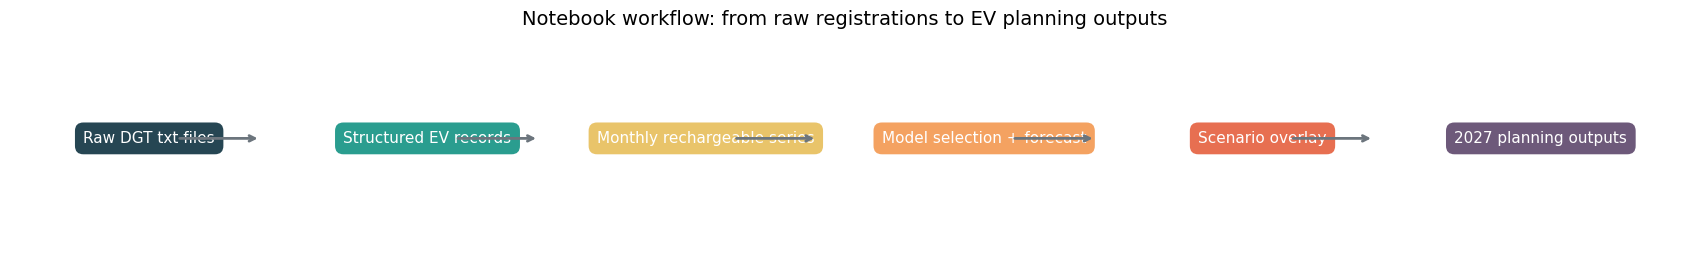

In [220]:
# Geography / project scope
GEOGRAPHY_LABEL = "Spain"

# Data download window
DOWNLOAD_START_YEAR = 2015
DOWNLOAD_END_YEAR = 2026
DOWNLOAD_END_MONTH = 3
TARGET_END_YEAR = 2031

# If needed, you can keep ingestion coverage wider than the forecasting training window
TRAINING_START_YEAR = DOWNLOAD_START_YEAR

# Local folders / portability
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "Nbr electric vehicles"
DOWNLOAD_ARCHIVE_FOLDER = DATA_DIR / "mensual_matriculation_202408_202603"
UNZIPPED_FOLDER_NAME = "unzipped"
CACHE_DIR = PROJECT_ROOT / "cache"
PARQUET_CACHE_PATH = CACHE_DIR / "ev_structured_2015_onward.parquet"
USE_PARQUET_CACHE = True
ENABLE_SAFE_CLEANUP = True

# Download source settings
BASE_URL = "https://www.dgt.es/microdatos/salida/{year}/{month}/vehiculos/matriculaciones/export_mensual_mat_{year}{month:02d}.zip"
DOWNLOAD_TIMEOUT_SECONDS = 10

# Forecasting dataset boundaries
TRAINING_START_DATE = datetime.date(TRAINING_START_YEAR, 1, 1)
LAST_COMPLETE_OBSERVED_MONTH = datetime.date(DOWNLOAD_END_YEAR, DOWNLOAD_END_MONTH, 1)
FORECAST_TARGET_END_DATE = datetime.date(TARGET_END_YEAR, 12, 1)

# Scenario settings
SCENARIO_INTERVAL_LEVEL = 0.30  # Change this to change the scenario analysis
SCENARIO_Z_SCORE = NormalDist().inv_cdf(0.5 + SCENARIO_INTERVAL_LEVEL / 2)
SCENARIO_INTERVAL_LABEL = f"{int(round(SCENARIO_INTERVAL_LEVEL * 100))}%"
REFERENCE_INTERVAL_LEVEL = 0.95
REFERENCE_Z_SCORE = NormalDist().inv_cdf(0.5 + REFERENCE_INTERVAL_LEVEL / 2)

# Forecast targets and reporting
OTHER_RECHARGEABLE_NAME = "OTHER_RECHARGEABLE"
TARGET_SERIES = ["BEV", OTHER_RECHARGEABLE_NAME]
TOTAL_SERIES_NAME = "TOTAL_RECHARGEABLE"
TOTAL_ALL_CARS_NAME = "TOTAL_ALL_CARS"
ELECTRIFIED_TOTAL_NAME = "ELECTRIFIED_TOTAL"
NORMAL_CARS_NAME = "NORMAL_CARS"
MODELLED_SERIES = TARGET_SERIES + [TOTAL_ALL_CARS_NAME, ELECTRIFIED_TOTAL_NAME]
FOCUSED_SUMMARY_YEAR = 2027
PLANNING_TARGET_YEAR = FOCUSED_SUMMARY_YEAR
PLANNING_SCENARIO = "normal"
HYBRID_CHARGING_WEIGHT = 0.35 #= how much a hybrid rechargeable weights in our analysis compared to 1 for full Electric Vehicles
CHARGING_DEMAND_METRIC_NAME = "CHARGING_DEMAND_EQUIVALENT"
SAVE_DIR = "Datathon_Forecasting_Outputs"

# Macro overlay assumptions and plotting
OVERLAY_SCENARIOS = ["pessimistic", "normal", "optimistic"]
OVERLAY_PLOT_SERIES = [TOTAL_SERIES_NAME, "BEV"]
OVERLAY_SCENARIO_COLORS = {
    "pessimistic": "#c1121f",
    "normal": "#1d3557",
    "optimistic": "#2a9d8f",
}
BATTERY_PRICE_REFERENCE_2025 = 108.0
SATURATION_ANNUAL_CEILING = 750000.0
SATURATION_CURVE_WEIGHT = 0.08
SATURATION_CURVE_EXPONENT = 1.6
SATURATION_FACTOR_FLOOR = 0.90
SATURATION_FACTOR_CAP = 1.00
MACRO_MULTIPLIER_FLOOR = 0.85
MACRO_MULTIPLIER_CAP = 1.15
BATTERY_MULTIPLIER_FLOOR = 0.95
BATTERY_MULTIPLIER_CAP = 1.08
MACRO_COMPONENT_WEIGHTS = {
    "gdp_growth": 0.015,
    "inflation": -0.008,
    "interest_rate": -0.015,
    "fuel_price_index": 0.0015,
    "charging_support_index": 0.080,
    "policy_score": 0.100,
}
BATTERY_PASS_THROUGH_BY_SCENARIO = {"pessimistic": 0.85, "normal": 1.00, "optimistic": 1.15}
BATTERY_SENSITIVITY_BY_SERIES = {"BEV": 0.20, OTHER_RECHARGEABLE_NAME: 0.08}
NORMAL_DRIVER_PATH = {
    2026: {"gdp_growth": 2.3, "inflation": 2.0, "interest_rate": 1.9, "fuel_price_index": 98.0, "battery_pack_usd_per_kwh": 102.0, "charging_support_index": 1.00, "policy_score": 1.00},
    2027: {"gdp_growth": 2.0, "inflation": 2.0, "interest_rate": 2.1, "fuel_price_index": 100.0, "battery_pack_usd_per_kwh": 98.0, "charging_support_index": 1.03, "policy_score": 1.00},
    2028: {"gdp_growth": 1.8, "inflation": 2.0, "interest_rate": 2.1, "fuel_price_index": 101.0, "battery_pack_usd_per_kwh": 95.0, "charging_support_index": 1.06, "policy_score": 1.01},
    2029: {"gdp_growth": 1.7, "inflation": 2.0, "interest_rate": 2.1, "fuel_price_index": 102.0, "battery_pack_usd_per_kwh": 92.0, "charging_support_index": 1.08, "policy_score": 1.01},
    2030: {"gdp_growth": 1.6, "inflation": 2.0, "interest_rate": 2.2, "fuel_price_index": 103.0, "battery_pack_usd_per_kwh": 90.0, "charging_support_index": 1.10, "policy_score": 1.02},
    2031: {"gdp_growth": 1.5, "inflation": 2.0, "interest_rate": 2.2, "fuel_price_index": 104.0, "battery_pack_usd_per_kwh": 88.0, "charging_support_index": 1.12, "policy_score": 1.02},
}
SCENARIO_DELTAS = {
    "pessimistic": {"gdp_growth": -0.7, "inflation": 0.6, "interest_rate": 0.5, "fuel_price_index": -3.0, "battery_pack_usd_per_kwh": 6.0, "charging_support_index": -0.08, "policy_score": -0.05},
    "normal": {"gdp_growth": 0.0, "inflation": 0.0, "interest_rate": 0.0, "fuel_price_index": 0.0, "battery_pack_usd_per_kwh": 0.0, "charging_support_index": 0.0, "policy_score": 0.0},
    "optimistic": {"gdp_growth": 0.5, "inflation": -0.3, "interest_rate": -0.3, "fuel_price_index": 4.0, "battery_pack_usd_per_kwh": -4.0, "charging_support_index": 0.08, "policy_score": 0.05},
}

# Workflow map for notebook readers
workflow_steps = [
    "Raw DGT txt files",
    "Structured EV records",
    "Monthly rechargeable series",
    "Model selection + forecast",
    "Scenario overlay",
    "2027 planning outputs",
]
workflow_colors = ["#264653", "#2a9d8f", "#e9c46a", "#f4a261", "#e76f51", "#6d597a"]
fig, ax = plt.subplots(figsize=(17, 2.8))
ax.set_xlim(0, len(workflow_steps))
ax.set_ylim(0, 1)
ax.axis("off")
for idx, (label, color) in enumerate(zip(workflow_steps, workflow_colors)):
    x_center = idx + 0.5
    ax.text(
        x_center,
        0.55,
        label,
        ha="center",
        va="center",
        fontsize=11,
        color="white",
        bbox=dict(boxstyle="round,pad=0.55", facecolor=color, edgecolor="none"),
    )
    if idx < len(workflow_steps) - 1:
        ax.annotate(
            "",
            xy=(idx + 0.9, 0.55),
            xytext=(idx + 0.6, 0.55),
            arrowprops=dict(arrowstyle="->", lw=2, color="#6c757d"),
        )
ax.set_title("Notebook workflow: from raw registrations to EV planning outputs", fontsize=14, pad=10)
plt.tight_layout()
plt.show()


## Start by extracting relevant files from 2015 until 2026
### You only have to run this cell once for the first run. No need to run it each time.

## Work with the files

### Cache-aware raw ingestion and reusable Parquet storage

This section keeps the existing raw parsing logic but adds a cached Parquet layer so reruns can skip the heavy text parsing step. The cache is validated before use, and the notebook continues gracefully if some months from 2015 onward are missing.


In [221]:
# Reusable helpers for cache validation, coverage checks, and disk-usage reporting
def format_bytes(num_bytes):
    num_bytes = float(num_bytes or 0)
    units = ["B", "KB", "MB", "GB", "TB"]
    idx = 0
    while num_bytes >= 1024 and idx < len(units) - 1:
        num_bytes /= 1024
        idx += 1
    return f"{num_bytes:.2f} {units[idx]}"

def get_folder_size_bytes(path):
    path = Path(path)
    if not path.exists():
        return 0
    total = 0
    for item in path.rglob("*"):
        try:
            if item.is_file():
                total += item.stat().st_size
        except OSError:
            continue
    return total

def validate_parquet_cache(parquet_path, required_columns):
    parquet_path = Path(parquet_path)
    result = {
        "is_valid": False,
        "reason": "",
        "data": None,
        "row_count": 0,
        "file_size_bytes": 0,
        "missing_columns": []
    }

    if not parquet_path.exists():
        result["reason"] = "file_missing"
        return result

    try:
        result["file_size_bytes"] = parquet_path.stat().st_size
        cached_df = pl.read_parquet(parquet_path)
    except Exception as exc:
        result["reason"] = f"read_failed: {exc}"
        return result

    missing_columns = [col for col in required_columns if col not in cached_df.columns]
    if missing_columns:
        result["reason"] = "missing_columns"
        result["missing_columns"] = missing_columns
        return result

    if cached_df.height <= 0:
        result["reason"] = "empty_table"
        return result

    result.update({
        "is_valid": True,
        "reason": "ok",
        "data": cached_df,
        "row_count": cached_df.height
    })
    return result

def month_sequence(start_month, end_month):
    months = []
    current = start_month
    while current <= end_month:
        months.append(current)
        current = current + relativedelta(months=1)
    return months

def is_path_within(base_path, candidate_path):
    base_path = Path(base_path).resolve()
    candidate_path = Path(candidate_path).resolve()
    try:
        candidate_path.relative_to(base_path)
        return True
    except ValueError:
        return False

### Build or load the structured EV cache

If the Parquet cache already exists and passes validation, the notebook loads it directly. Otherwise it unzips the available monthly raw files, applies the current parsing logic, writes a compressed Parquet cache, and validates it before proceeding.

In [222]:
import requests, zipfile, io
from pathlib import Path

DOWNLOAD_DIR = BASE / 'Nbr electric vehicles/mensual_matriculation_202408_202603'
EXTRACT_DIR  = DOWNLOAD_DIR / 'unzipped'
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

# DGT monthly matriculation files (Aug 2024 → Mar 2026)
YEARS_MONTHS = [
    (y, m) for y in range(2024, 2027)
    for m in range(1, 13)
    if (2024, 8) <= (y, m) <= (2026, 3)
]

for year, month in YEARS_MONTHS:
    zip_name = f'matriculaciones_{year}{month:02d}.zip'
    zip_path = DOWNLOAD_DIR / zip_name

    if zip_path.exists():
        print(f'  {year}-{month:02d}: already downloaded ✓')
        continue

    url = (f'https://www.dgt.es/microdatos/salida/{year}/{month}'
           f'/vehiculos/matriculaciones/export_mensual_mat_{year}{month:02d}.zip')

    print(f'  Downloading {year}-{month:02d}...', end=' ')
    try:
        r = requests.get(url, timeout=120, headers={'User-Agent': 'Mozilla/5.0'})
        if r.status_code == 200:
            zip_path.write_bytes(r.content)
            print(f'✅ {len(r.content)//1024} KB')
        else:
            print(f'❌ HTTP {r.status_code}')
    except Exception as e:
        print(f'❌ {e}')

# Extract all zips
print('\nExtracting zip files...')
for zip_path in sorted(DOWNLOAD_DIR.glob('*.zip')):
    target_dir = EXTRACT_DIR / zip_path.stem
    target_dir.mkdir(parents=True, exist_ok=True)
    expected_txt = list(target_dir.glob('*.txt'))
    if expected_txt:
        print(f'  {zip_path.name}: already extracted ✓')
        continue
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(target_dir)
    print(f'  {zip_path.name}: extracted ✅')

print('\n✅ Done — now run the next cell')

  2024-08: already downloaded ✓
  2024-09: already downloaded ✓
  2024-10: already downloaded ✓
  2024-11: already downloaded ✓
  2024-12: already downloaded ✓
  2025-01: already downloaded ✓
  2025-02: already downloaded ✓
  2025-03: already downloaded ✓
  2025-04: already downloaded ✓
  2025-05: already downloaded ✓
  2025-06: already downloaded ✓
  2025-07: already downloaded ✓
  2025-08: already downloaded ✓
  2025-09: already downloaded ✓
  2025-10: already downloaded ✓
  2025-11: already downloaded ✓
  2025-12: already downloaded ✓
  2026-01: already downloaded ✓
  2026-02: already downloaded ✓
  2026-03: already downloaded ✓

Extracting zip files...
  matriculaciones_202408.zip: already extracted ✓
  matriculaciones_202409.zip: already extracted ✓
  matriculaciones_202410.zip: already extracted ✓
  matriculaciones_202411.zip: already extracted ✓
  matriculaciones_202412.zip: already extracted ✓
  matriculaciones_202501.zip: already extracted ✓
  matriculaciones_202502.zip: alrea

### Safe cleanup after successful cache validation

Cleanup runs only after the Parquet cache is confirmed to exist, be readable, contain rows, and include the required columns. Only clearly intermediate raw files inside the download archive folder are considered for deletion, and ambiguous project files are kept.

In [223]:
from pathlib import Path
from datetime import date
import polars as pl

PARQUET_CACHE_PATH = BASE / 'cache/ev_structured_2015_onward.parquet'

# ── Guard: define missing variables if previous cell didn't run ───────────────
if 'coverage_start' not in dir():               coverage_start = None
if 'coverage_end' not in dir():                 coverage_end = None
if 'expected_start' not in dir():               expected_start = date(2015, 1, 1)
if 'expected_end' not in dir():                 expected_end = None
if 'project_size_before_cleanup_bytes' not in dir(): project_size_before_cleanup_bytes = 0
if 'cache_was_rebuilt' not in dir():            cache_was_rebuilt = False
if 'download_folder' not in dir():              download_folder = BASE / 'Nbr electric vehicles/mensual_matriculation_202408_202603'
if 'extract_folder' not in dir():               extract_folder = download_folder / 'unzipped'
if 'cache_required_columns' not in dir():       cache_required_columns = ['registration_date', 'fuel_type', 'is_rechargeable_ev']
if 'PROJECT_ROOT' not in dir():                 PROJECT_ROOT = BASE
if 'ENABLE_SAFE_CLEANUP' not in dir():          ENABLE_SAFE_CLEANUP = False

if 'validate_parquet_cache' not in dir():
    def validate_parquet_cache(path, required_cols):
        if not path.exists():
            return {"is_valid": False, "reason": "File not found"}
        try:
            df = pl.read_parquet(path, n_rows=5)
            missing = [c for c in required_cols if c not in df.columns]
            if missing:
                return {"is_valid": False, "reason": f"Missing columns: {missing}"}
            return {"is_valid": True}
        except Exception as e:
            return {"is_valid": False, "reason": str(e)}

if 'is_path_within' not in dir():
    def is_path_within(parent, child):
        try:
            Path(child).resolve().relative_to(Path(parent).resolve())
            return True
        except ValueError:
            return False

if 'get_folder_size_bytes' not in dir():
    def get_folder_size_bytes(folder):
        return sum(f.stat().st_size for f in Path(folder).rglob('*') if f.is_file()) if Path(folder).exists() else 0

if 'format_bytes' not in dir():
    def format_bytes(b):
        for unit in ['B', 'KB', 'MB', 'GB', 'TB']:
            if b < 1024: return f"{b:.2f} {unit}"
            b /= 1024
        return f"{b:.2f} PB"

# ── Cleanup ───────────────────────────────────────────────────────────────────
cleanup_validation = validate_parquet_cache(PARQUET_CACHE_PATH, cache_required_columns)
deleted_records    = []
deletion_failures  = []
removed_empty_dirs = []

if ENABLE_SAFE_CLEANUP and cleanup_validation["is_valid"]:
    cleanup_candidates = []
    if extract_folder.exists():
        cleanup_candidates.extend(sorted(extract_folder.rglob("*.txt")))
    if download_folder.exists():
        cleanup_candidates.extend(sorted(download_folder.glob("*.zip")))
        cleanup_candidates.extend(sorted(download_folder.rglob("*.csv")))

    allowed_suffixes = {".txt", ".zip", ".csv"}
    for candidate in cleanup_candidates:
        candidate = Path(candidate)
        if not candidate.exists() or not candidate.is_file():
            continue
        if candidate.suffix.lower() not in allowed_suffixes:
            continue
        if not is_path_within(download_folder, candidate):
            continue
        try:
            size_bytes = candidate.stat().st_size
            deleted_records.append({
                "file_type":  candidate.suffix.lower(),
                "path":       str(candidate.relative_to(PROJECT_ROOT)),
                "size_bytes": size_bytes
            })
            candidate.unlink()
        except Exception as exc:
            deletion_failures.append({"path": str(candidate), "error": str(exc)})

    for folder in sorted(
        [p for p in download_folder.rglob("*") if p.is_dir()],
        key=lambda x: len(x.parts), reverse=True
    ):
        try:
            if folder == download_folder:
                continue
            if any(folder.iterdir()):
                continue
            folder.rmdir()
            removed_empty_dirs.append(str(folder.relative_to(PROJECT_ROOT)))
        except Exception:
            continue
else:
    print("Cleanup skipped — cache validation failed or cleanup is disabled.")

cleanup_successful               = cleanup_validation["is_valid"] and len(deletion_failures) == 0
project_size_after_cleanup_bytes = get_folder_size_bytes(PROJECT_ROOT)
deleted_total_bytes              = sum(item["size_bytes"] for item in deleted_records)

if deleted_records:
    cleanup_summary = (
        pl.DataFrame(deleted_records)
        .group_by("file_type")
        .agg([
            pl.len().alias("files_deleted"),
            pl.col("size_bytes").sum().alias("bytes_deleted")
        ])
        .with_columns((pl.col("bytes_deleted") / (1024 ** 3)).round(3).alias("size_deleted_gb"))
        .sort("file_type")
    )
else:
    cleanup_summary = pl.DataFrame({
        "file_type":       pl.Series([], dtype=pl.Utf8),
        "files_deleted":   pl.Series([], dtype=pl.Int64),
        "bytes_deleted":   pl.Series([], dtype=pl.Int64),
        "size_deleted_gb": pl.Series([], dtype=pl.Float64),
    })

print("--- CLEANUP SUMMARY ---")
print(cleanup_summary)
print(f"Deleted files:          {len(deleted_records)}")
print(f"Deleted size:           {format_bytes(deleted_total_bytes)}")
print(f"Removed empty folders:  {len(removed_empty_dirs)}")
if deleted_records:
    print("Deleted file examples:")
    print([item["path"] for item in deleted_records[:10]])
if deletion_failures:
    print("Cleanup failures:")
    print(deletion_failures[:10])

print("\n--- FINAL CACHE / STORAGE STATUS ---")
print(f"Parquet cache ready:             {PARQUET_CACHE_PATH}")
print(f"Cache exists:                    {PARQUET_CACHE_PATH.exists()}")
print(f"Raw parsed date range in cache:  {coverage_start.strftime('%Y-%m') if coverage_start else 'N/A'} → {coverage_end.strftime('%Y-%m') if coverage_end else 'N/A'}")
print(f"Configured analysis window:      {expected_start.strftime('%Y-%m')} → {expected_end.strftime('%Y-%m') if expected_end else 'N/A'}")
print(f"Project size before cleanup:     {project_size_before_cleanup_bytes / (1024**3):.2f} GB")
print(f"Project size after cleanup:      {project_size_after_cleanup_bytes / (1024**3):.2f} GB")
print(f"Cleanup successful:              {'Yes' if cleanup_successful else 'No'}")
print(f"Cache rebuilt this run:          {'Yes' if cache_was_rebuilt else 'No'}")

Cleanup skipped — cache validation failed or cleanup is disabled.
--- CLEANUP SUMMARY ---
shape: (0, 4)
┌───────────┬───────────────┬───────────────┬─────────────────┐
│ file_type ┆ files_deleted ┆ bytes_deleted ┆ size_deleted_gb │
│ ---       ┆ ---           ┆ ---           ┆ ---             │
│ str       ┆ i64           ┆ i64           ┆ f64             │
╞═══════════╪═══════════════╪═══════════════╪═════════════════╡
└───────────┴───────────────┴───────────────┴─────────────────┘
Deleted files:          0
Deleted size:           0.00 B
Removed empty folders:  0

--- FINAL CACHE / STORAGE STATUS ---
Parquet cache ready:             /Users/andreaalarcon/Documents/Datathon/cache/ev_structured_2015_onward.parquet
Cache exists:                    True
Raw parsed date range in cache:  N/A → N/A
Configured analysis window:      2015-01 → N/A
Project size before cleanup:     0.00 GB
Project size after cleanup:      2.85 GB
Cleanup successful:              No
Cache rebuilt this run:         

quick check

In [224]:
import requests, zipfile, io, polars as pl
from pathlib import Path
from datetime import date

DOWNLOAD_DIR       = BASE / 'Nbr electric vehicles/mensual_matriculation_202408_202603'
EXTRACT_DIR        = DOWNLOAD_DIR / 'unzipped'
PARQUET_CACHE_PATH = BASE / 'cache/ev_structured_2015_onward.parquet'
PARQUET_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

COLSPECS = [
    (0,   8,  'registration_date'),
    (93,  94, 'propulsion_code'),
    (17,  47, 'brand'),
    (47,  69, 'model'),
    (152, 154,'province_code_vehicle'),
    (165, 170,'postal_code'),
    (170, 178,'first_reg_date'),
    (178, 179,'new_used'),
    (197, 227,'municipality'),
    (227, 234,'power_kw'),
    (237, 242,'co2_emissions'),
    (445, 449,'consumption_wh_km'),
    (453, 457,'categoria_vehiculo_electrico'),
    (457, 463,'ev_range_km'),
]

EV_CODES = {'2', 'H', 'I', 'K'}

YEARS_MONTHS = [
    (y, m) for y in range(2020, 2027)
    for m in range(1, 13)
    if (y, m) <= (2026, 3)
]

def build_url(year, month):
    return (f'https://www.dgt.es/microdatos/salida/{year}/{month}'
            f'/vehiculos/matriculaciones/export_mensual_mat_{year}{month:02d}.zip')

# ── Download + parse each month, save parquet immediately ────────────────────
OUT_DIR = BASE / 'cache/monthly_ev_parquet'
OUT_DIR.mkdir(parents=True, exist_ok=True)

for year, month in YEARS_MONTHS:
    out_file = OUT_DIR / f'ev_{year}{month:02d}.parquet'
    if out_file.exists():
        print(f'  {year}-{month:02d}: cached ✓', end='\r')
        continue

    url = build_url(year, month)
    try:
        r = requests.get(url, timeout=120, headers={'User-Agent': 'Mozilla/5.0'})
    except Exception as e:
        print(f'  {year}-{month:02d}: connection error — skipped')
        continue

    if r.status_code != 200:
        print(f'  {year}-{month:02d}: HTTP {r.status_code} — skipped')
        continue

    try:
        with zipfile.ZipFile(io.BytesIO(r.content)) as z:
            with z.open(z.namelist()[0]) as f:
                content = f.read().decode('latin-1')
    except Exception as e:
        print(f'  {year}-{month:02d}: zip error — {e}')
        continue

    del r

    ev_lines = [
        l for l in content.splitlines()
        if len(l) >= 200 and l[93:94].strip() in EV_CODES
    ]
    del content

    if not ev_lines:
        print(f'  {year}-{month:02d}: 0 EV records')
        continue

    rows = [{name: line[start:end].strip() for start, end, name in COLSPECS}
            for line in ev_lines]
    del ev_lines

    df_month = (
        pl.DataFrame(rows)
        .with_columns([
            pl.lit(year).alias('year'),
            pl.lit(month).alias('month'),
        ])
        .with_columns([
            pl.col('registration_date').str.strptime(pl.Date, '%d%m%Y', strict=False),
            pl.col('first_reg_date').str.strptime(pl.Date, '%d%m%Y', strict=False),
            pl.col('categoria_vehiculo_electrico').str.strip_chars().replace('', None),
        ])
        .with_columns([
            (pl.col('categoria_vehiculo_electrico') == 'BEV').alias('is_bev'),
            (pl.col('categoria_vehiculo_electrico') == 'PHEV').alias('is_phev'),
            (pl.col('categoria_vehiculo_electrico') == 'REEV').alias('is_reev'),
            pl.col('categoria_vehiculo_electrico').is_in(['BEV','PHEV','REEV']).alias('is_rechargeable_ev'),
            pl.when(pl.col('categoria_vehiculo_electrico').is_in(['BEV','PHEV','REEV']))
              .then(pl.col('categoria_vehiculo_electrico'))
              .otherwise(None)
              .alias('rechargeable_ev_type'),
        ])
        .with_columns([
            pl.col('power_kw').str.replace('*','',literal=True).cast(pl.Float64, strict=False),
            pl.col('ev_range_km').str.replace('*','',literal=True).cast(pl.Float64, strict=False),
            pl.col('co2_emissions').str.replace('*','',literal=True).cast(pl.Float64, strict=False),
        ])
    )

    df_month.write_parquet(out_file)
    print(f'  {year}-{month:02d}: {len(df_month):,} EV records ✅')

# ── Combine all monthly parquets into one cache ───────────────────────────────
print('\nBuilding combined cache...')
monthly_files = sorted(OUT_DIR.glob('ev_*.parquet'))
if not monthly_files:
    raise FileNotFoundError('No monthly parquet files found — check download step above')

df = pl.concat([pl.read_parquet(f) for f in monthly_files], how='vertical_relaxed')
df.write_parquet(PARQUET_CACHE_PATH, compression='zstd')

print(f'✅ Cache saved → {PARQUET_CACHE_PATH}')
print(f'   Shape: {df.shape}')
print(f'   EV types: {df["categoria_vehiculo_electrico"].value_counts().sort("count", descending=True)}')
print(f'   Date range: {df["registration_date"].min()} → {df["registration_date"].max()}')

# ── Preview ───────────────────────────────────────────────────────────────────
df.select([
    'registration_date', 'brand', 'model',
    'categoria_vehiculo_electrico', 'is_bev', 'is_phev',
    'is_reev', 'is_rechargeable_ev', 'rechargeable_ev_type',
    'ev_range_km', 'province_code_vehicle'
]).head(10)

  2020-03: 0 EV records

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8507
  Network URL: http://10.94.115.14:8507

  For better performance, install the Watchdog module:

  $ xcode-select --install
  $ pip install watchdog
            
  2020-04: 0 EV records
  2020-07: 0 EV records
  2020-09: 0 EV records
  2020-10: 0 EV records
  2022-12: 0 EV records
  2023-04: 0 EV records
  2023-08: 0 EV records
  2024-02: 0 EV records
  2024-03: 0 EV records
  2024-08: 0 EV records
  2024-11: 0 EV records
  2025-07: 0 EV records
  2025-10: 0 EV records
  2026-03: cached ✓
Building combined cache...
✅ Cache saved → /Users/andreaalarcon/Documents/Datathon/cache/ev_structured_2015_onward.parquet
   Shape: (427, 21)
   EV types: shape: (4, 2)
┌──────────────────────────────┬───────┐
│ categoria_vehiculo_electrico ┆ count │
│ ---                          ┆ ---   │
│ str                          ┆ u32   │
╞══════════════════════════════╪═══════╡
│ null         

registration_date,brand,model,categoria_vehiculo_electrico,is_bev,is_phev,is_reev,is_rechargeable_ev,rechargeable_ev_type,ev_range_km,province_code_vehicle
date,str,str,str,bool,bool,bool,bool,str,f64,str
2020-01-13,"""TOYOTA""","""TOYOTA PRIUS PLUS""","""HEV""",false,false,false,false,null,0.0,"""M"""
2020-01-23,"""TOYOTA""","""TOYOTA PRIUS PLUS""","""HEV""",false,false,false,false,null,0.0,"""M"""
2020-02-06,"""MINI""","""ONE""",null,null,null,null,null,null,0.0,"""B"""
2020-05-25,"""TOYOTA""","""TOYOTA COROLLA""","""HEV""",false,false,false,false,null,0.0,"""M"""
2020-06-10,"""DFSK""","""580""",null,null,null,null,null,null,0.0,"""LE"""
2020-08-19,"""SUBARU""","""OUTBACK""",null,null,null,null,null,null,0.0,"""GU"""
2020-11-16,"""FENDT""","""FENDT 930 VARIO""",null,null,null,null,null,null,0.0,"""HU"""
2020-12-22,"""FIAT""","""FIAT TIPO""",null,null,null,null,null,null,0.0,"""B"""
2021-01-04,"""TOYOTA""","""TOYOTA COROLLA""","""HEV""",false,false,false,false,null,0.0,"""M"""


## Basic Data Cleaning

### Check Column types

In [225]:
type_overview = pl.DataFrame({
    "column": list(df.schema.keys()),
    "dtype": [str(dtype) for dtype in df.schema.values()]
})

type_overview

column,dtype
str,str
"""registration_date""","""Date"""
"""propulsion_code""","""String"""
"""brand""","""String"""
"""model""","""String"""
"""province_code_vehicle""","""String"""
…,…
"""is_bev""","""Boolean"""
"""is_phev""","""Boolean"""
"""is_reev""","""Boolean"""


Numeric VS non-numeric columns

In [226]:
numeric_dtypes = {
    pl.Int8, pl.Int16, pl.Int32, pl.Int64,
    pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
    pl.Float32, pl.Float64
}

numeric_cols = [col for col, dtype in df.schema.items() if dtype in numeric_dtypes]
non_numeric_cols = [col for col in df.columns if col not in numeric_cols]

print("Numeric columns:", numeric_cols)
print("Non-numeric columns:", non_numeric_cols)

Numeric columns: ['power_kw', 'co2_emissions', 'ev_range_km', 'year', 'month']
Non-numeric columns: ['registration_date', 'propulsion_code', 'brand', 'model', 'province_code_vehicle', 'postal_code', 'first_reg_date', 'new_used', 'municipality', 'consumption_wh_km', 'categoria_vehiculo_electrico', 'is_bev', 'is_phev', 'is_reev', 'is_rechargeable_ev', 'rechargeable_ev_type']


### Rechargeable EV counts

In [227]:
rechargeable_breakdown = (
    df.filter(pl.col("rechargeable_ev_type").is_not_null())
      .group_by("rechargeable_ev_type")
      .agg(pl.len().alias("n"))
      .sort("n", descending=True)
)

rechargeable_breakdown

rechargeable_ev_type,n
str,u32
"""BEV""",133
"""PHEV""",6


Separate dataframes for the different types of EVs

In [228]:
df_bev = df.filter(pl.col("is_bev"))
df_phev = df.filter(pl.col("is_phev"))
df_reev = df.filter(pl.col("is_reev"))

### EV Category breakdown

In [229]:
overall_counts = pl.DataFrame({
    "metric": [
        "total_records",
        "rechargeable_ev_bev_phev_reev",
        "battery_electric_vehicles_bev",
        "plug_in_hybrid_phev",
        "range_extended_reev",
    ],
    "value": [
        df.height,
        df.filter(pl.col("is_rechargeable_ev")).height,
        df.filter(pl.col("is_bev")).height,
        df.filter(pl.col("is_phev")).height,
        df.filter(pl.col("is_reev")).height,
    ]
})

overall_counts

metric,value
str,i64
"""total_records""",427
"""rechargeable_ev_bev_phev_reev""",139
"""battery_electric_vehicles_bev""",133
"""plug_in_hybrid_phev""",6
"""range_extended_reev""",0


### Monthly series for forecasting

In [230]:
monthly_by_type = (
    df.filter(pl.col("rechargeable_ev_type").is_not_null())
      .with_columns(
          pl.when(pl.col("rechargeable_ev_type") == "BEV")
            .then(pl.lit("BEV"))
            .otherwise(pl.lit(OTHER_RECHARGEABLE_NAME))
            .alias("forecast_ev_bucket")
      )
      .group_by([
          pl.col("registration_date").dt.truncate("1mo").alias("month"),
          pl.col("forecast_ev_bucket").alias("rechargeable_ev_type")
      ])
      .agg(pl.len().alias("n_vehicles"))
      .sort(["month", "rechargeable_ev_type"])
)

monthly_by_type

month,rechargeable_ev_type,n_vehicles
date,str,u32
2021-03-01,"""OTHER_RECHARGEABLE""",1
2021-04-01,"""OTHER_RECHARGEABLE""",1
2021-07-01,"""OTHER_RECHARGEABLE""",1
2021-10-01,"""OTHER_RECHARGEABLE""",1
2023-05-01,"""OTHER_RECHARGEABLE""",1
…,…,…
2025-11-01,"""BEV""",5
2025-11-01,"""OTHER_RECHARGEABLE""",1
2025-12-01,"""BEV""",5


Wide format version

In [231]:
monthly_by_type_wide = (
    monthly_by_type
    .pivot(
        values="n_vehicles",
        index="month",
        on="rechargeable_ev_type"
    )
    .sort("month")
    .fill_null(0)
)

monthly_by_type_wide

month,OTHER_RECHARGEABLE,BEV
date,u32,u32
2021-03-01,1,0
2021-04-01,1,0
2021-07-01,1,0
2021-10-01,1,0
2023-05-01,1,0
…,…,…
2025-06-01,0,104
2025-11-01,1,5
2025-12-01,0,5


## Prepare for Forecast
From this point onward, `REEV` is merged into `OTHER_RECHARGEABLE` for forecasting and charging-infrastructure planning. The raw REEV counts are still kept earlier in the notebook for transparency.

--- RAW POLARS DATA AUDIT ---
Shape: (13, 3)
Columns: ['month', 'OTHER_RECHARGEABLE', 'BEV']
Date Range: 2021-03-01 to 2026-03-01
Null Counts:
shape: (1, 3)
┌───────┬────────────────────┬─────┐
│ month ┆ OTHER_RECHARGEABLE ┆ BEV │
│ ---   ┆ ---                ┆ --- │
│ u32   ┆ u32                ┆ u32 │
╞═══════╪════════════════════╪═════╡
│ 0     ┆ 0                  ┆ 0   │
└───────┴────────────────────┴─────┘

First 10 rows:
shape: (10, 3)
┌────────────┬────────────────────┬─────┐
│ month      ┆ OTHER_RECHARGEABLE ┆ BEV │
│ ---        ┆ ---                ┆ --- │
│ date       ┆ u32                ┆ u32 │
╞════════════╪════════════════════╪═════╡
│ 2021-03-01 ┆ 1                  ┆ 0   │
│ 2021-04-01 ┆ 1                  ┆ 0   │
│ 2021-07-01 ┆ 1                  ┆ 0   │
│ 2021-10-01 ┆ 1                  ┆ 0   │
│ 2023-05-01 ┆ 1                  ┆ 0   │
│ 2025-02-01 ┆ 0                  ┆ 2   │
│ 2025-03-01 ┆ 0                  ┆ 7   │
│ 2025-05-01 ┆ 0                  ┆ 4   │
│ 2025-

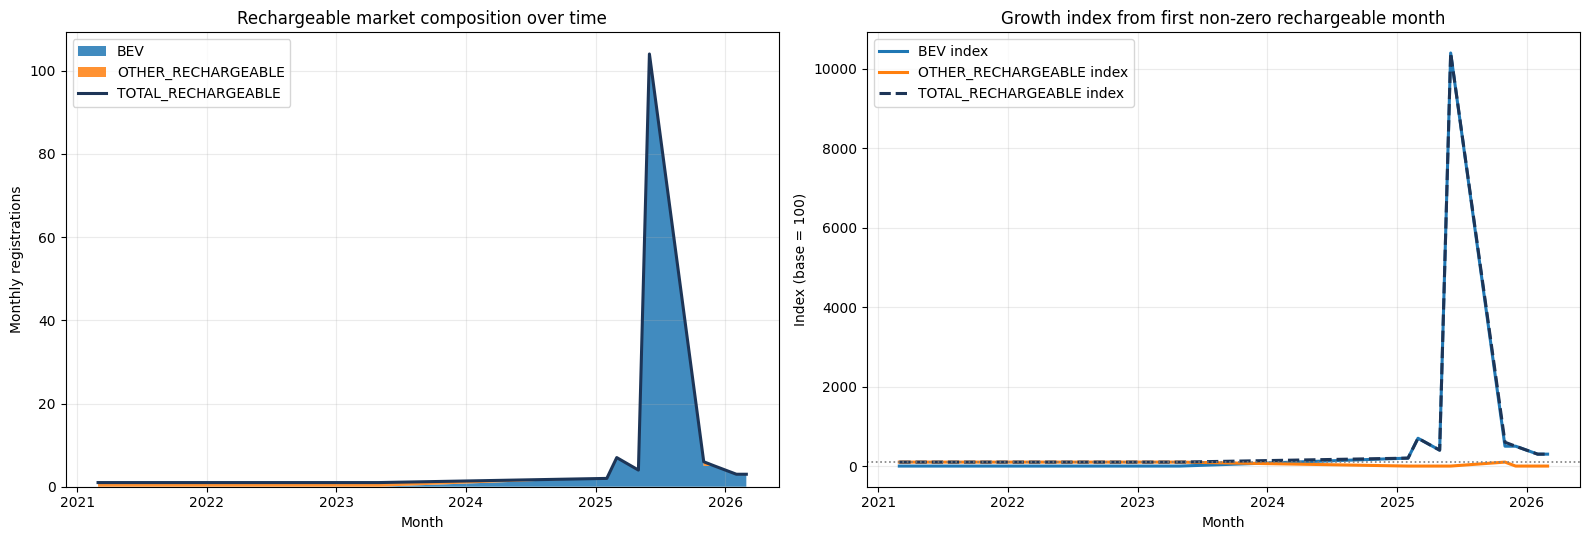

month,BEV,OTHER_RECHARGEABLE,TOTAL_ALL_CARS,ELECTRIFIED_TOTAL,NORMAL_CARS,TOTAL_RECHARGEABLE
date,i64,i64,i64,i64,i64,i64
2025-04-01,0,0,3,0,3,0
2025-05-01,4,0,5,4,1,4
2025-06-01,104,0,107,104,3,104
2025-07-01,0,0,0,0,0,0
2025-08-01,0,0,1,0,1,0
…,…,…,…,…,…,…
2025-11-01,5,1,7,6,1,6
2025-12-01,5,0,7,5,2,5
2026-01-01,0,0,1,0,1,0


In [232]:
# 1. Build total-car and electrified monthly baselines
monthly_market_totals = (
    df.group_by(pl.col("registration_date").dt.truncate("1mo").alias("month"))
      .agg([
          pl.len().alias(TOTAL_ALL_CARS_NAME),
          pl.col("is_rechargeable_ev").cast(pl.Int64).sum().alias(ELECTRIFIED_TOTAL_NAME)
      ])
      .with_columns([
          (pl.col(TOTAL_ALL_CARS_NAME) - pl.col(ELECTRIFIED_TOTAL_NAME)).alias(NORMAL_CARS_NAME)
      ])
      .sort("month")
)

# 2. Audit the raw Polars DataFrame (monthly_by_type_wide)
print("--- RAW POLARS DATA AUDIT ---")
print(f"Shape: {monthly_by_type_wide.shape}")
print(f"Columns: {monthly_by_type_wide.columns}")
print(f"Date Range: {monthly_by_type_wide['month'].min()} to {monthly_by_type_wide['month'].max()}")
print(f"Null Counts:\n{monthly_by_type_wide.null_count()}")
print("\nFirst 10 rows:")
print(monthly_by_type_wide.head(10))
print("\nLast 10 rows:")
print(monthly_by_type_wide.tail(10))
print("-" * 35)

# 3. Define target boundaries
start_date = TRAINING_START_DATE
end_date   = LAST_COMPLETE_OBSERVED_MONTH

# 4. Create cleaned forecasting dataset
full_month_seq = pl.date_range(start_date, end_date, interval="1mo", eager=True).alias("month").to_frame()

forecast_df_clean = (
    full_month_seq
    .join(
        monthly_by_type_wide
        .filter((pl.col("month") >= start_date) & (pl.col("month") <= end_date))
        .select(["month", "BEV", OTHER_RECHARGEABLE_NAME]),
        on="month",
        how="left"
    )
    .join(
        monthly_market_totals
        .filter((pl.col("month") >= start_date) & (pl.col("month") <= end_date))
        .select(["month", TOTAL_ALL_CARS_NAME, ELECTRIFIED_TOTAL_NAME, NORMAL_CARS_NAME]),
        on="month",
        how="left"
    )
    .with_columns(pl.all().exclude("month").fill_null(0).cast(pl.Int64))
)

# 5. Ensure continuous monthly range with no gaps
missing_dates = full_month_seq.join(forecast_df_clean, on="month", how="anti")
if missing_dates.height > 0:
    print(f"⚠️ WARNING: Found {missing_dates.height} missing monthly gaps even after reindexing.")
    print(f"Missing dates: {missing_dates['month'].to_list()}")

# 6. Add TOTAL_RECHARGEABLE and recompute NORMAL_CARS
forecast_df_clean = forecast_df_clean.with_columns([
    (pl.col("BEV") + pl.col(OTHER_RECHARGEABLE_NAME)).alias(TOTAL_SERIES_NAME),
    (pl.col(TOTAL_ALL_CARS_NAME) - pl.col(ELECTRIFIED_TOTAL_NAME)).clip(lower_bound=0).alias(NORMAL_CARS_NAME)
])

# 7. Final Audit
print("\n--- FINAL CLEANED DATASET AUDIT (POLARS) ---")
print(f"Final Shape: {forecast_df_clean.shape}")
print(f"Final Date Range: {forecast_df_clean['month'].min()} to {forecast_df_clean['month'].max()}")

is_gap_free = forecast_df_clean.height == full_month_seq.height
print(f"Is index monthly and gap-free? {is_gap_free}")

print("\nSummary Statistics:")
print(forecast_df_clean.drop("month").describe())
print("-" * 35)

# 8. Market structure visuals
composition_plot  = forecast_df_clean.filter(pl.col(TOTAL_SERIES_NAME) > 0).sort("month")
composition_dates = composition_plot["month"].to_list()
bev_vals          = composition_plot["BEV"].to_list()
other_vals        = composition_plot[OTHER_RECHARGEABLE_NAME].to_list()
total_vals        = composition_plot[TOTAL_SERIES_NAME].to_list()

base_bev   = max(bev_vals[0], 1)
base_other = max(other_vals[0], 1)
base_total = max(total_vals[0], 1)
bev_index   = [v / base_bev   * 100 for v in bev_vals]
other_index = [v / base_other * 100 for v in other_vals]
total_index = [v / base_total * 100 for v in total_vals]

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

axes[0].stackplot(
    composition_dates, bev_vals, other_vals,
    labels=["BEV", OTHER_RECHARGEABLE_NAME],
    colors=["#1f77b4", "#ff7f0e"], alpha=0.85,
)
axes[0].plot(composition_dates, total_vals, color="#1d3557", linewidth=2.2, label=TOTAL_SERIES_NAME)
axes[0].set_title("Rechargeable market composition over time")
axes[0].set_ylabel("Monthly registrations")
axes[0].grid(alpha=0.25)
axes[0].legend(loc="upper left")

axes[1].plot(composition_dates, bev_index,   color="#1f77b4", linewidth=2.2, label="BEV index")
axes[1].plot(composition_dates, other_index, color="#ff7f0e", linewidth=2.2, label=f"{OTHER_RECHARGEABLE_NAME} index")
axes[1].plot(composition_dates, total_index, color="#1d3557", linewidth=2.2, linestyle="--", label=f"{TOTAL_SERIES_NAME} index")
axes[1].axhline(100, color="#7f7f7f", linestyle=":", linewidth=1.2)
axes[1].set_title("Growth index from first non-zero rechargeable month")
axes[1].set_ylabel("Index (base = 100)")
axes[1].grid(alpha=0.25)
axes[1].legend(loc="upper left")

for ax in axes:
    ax.set_xlabel("Month")

plt.tight_layout()
plt.show()

# 9. Output last 12 months
forecast_df_clean.tail(12)

### Define metrics and backtesting formula, and rund the evaluation

In [233]:
# 1. Metric definitions (Robust and Reusable)
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def smape(y_true, y_pred):
    # Symmetric Mean Absolute Percentage Error
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    return np.mean(np.abs(y_true - y_pred) / (denominator + 1e-10)) * 100

def wape(y_true, y_pred):
    # Weighted Absolute Percentage Error
    return np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true)) + 1e-10) * 100

def mape_safe(y_true, y_pred):
    # Mean Absolute Percentage Error with protection against zero-division
    mask = y_true != 0
    if not np.any(mask): return 0.0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# 2. Benchmark Model Logic
def predict_naive(history, h):
    last_val = history[-1]
    return np.full(h, last_val)

def predict_snaive(history, h, sp=12):
    # Seasonal Naive: repeat the last full season
    if len(history) < sp:
        return predict_naive(history, h)
    preds = []
    for i in range(h):
        preds.append(history[-(sp - (i % sp))])
    return np.array(preds)

def predict_drift(history, h):
    # Drift: Last value + h * (average change)
    if len(history) < 2:
        return predict_naive(history, h)
    n = len(history)
    slope = (history[-1] - history[0]) / (n - 1)
    return np.array([history[-1] + (i + 1) * slope for i in range(h)])

# 3. Backtesting Framework
def backtest_benchmark(series_name, series_data, model_func, start_origin, step, horizon, total_len):
    folds = []
    origin = start_origin
    fold_idx = 1

    while origin + horizon <= total_len:
        train = series_data[:origin]
        test_actual = series_data[origin:origin + horizon]

        preds = model_func(train, horizon)

        metrics = {
            "Series": series_name,
            "Fold": fold_idx,
            "RMSE": float(rmse(test_actual, preds)),
            "MAE": float(mae(test_actual, preds)),
            "sMAPE": float(smape(test_actual, preds)),
            "WAPE": float(wape(test_actual, preds)),
            "MAPE": float(mape_safe(test_actual, preds))
        }
        folds.append(metrics)

        origin += step
        fold_idx += 1

    return folds

# 4. Data Preparation: Final Holdout vs Training Portion
# Reserve the last 12 months as total holdout
df_train_portion = forecast_df_clean.head(-12)
df_holdout = forecast_df_clean.tail(12)

n_train = df_train_portion.height
target_series = MODELLED_SERIES
benchmarks = {
    "Naive": predict_naive,
    "Seasonal Naive": predict_snaive,
    "Drift": predict_drift
}

print(f"--- Time Series Evaluation Split Details ---")
print(f"Total points: {forecast_df_clean.height}")
print(f"Training portion: {n_train} months")
print(f"Holdout test set: {df_holdout.height} months")
print(f"CV Settings | Initial Window: 60 | Horizon: 12 | Step: 6")
print("-" * 45)

# 5. Run Evaluation
benchmark_cv_results_list = []

for series in target_series:
    series_vals = df_train_portion[series].to_numpy()

    for name, func in benchmarks.items():
        results = backtest_benchmark(series, series_vals, func, 60, 6, 12, n_train)
        for r in results:
            r["Model"] = name
        benchmark_cv_results_list.extend(results)

# 6. Aggregation and Summary
benchmark_cv_results = pl.DataFrame(benchmark_cv_results_list)

benchmark_summary = (
    benchmark_cv_results
    .group_by(["Series", "Model"])
    .agg([
        pl.col("RMSE").mean().alias("RMSE"),
        pl.col("MAE").mean().alias("MAE"),
        pl.col("sMAPE").mean().alias("sMAPE"),
        pl.col("WAPE").mean().alias("WAPE"),
        pl.col("MAPE").mean().alias("MAPE")
    ])
    .sort(["Series", "RMSE", "sMAPE"])
)

# 7. Print Results
print("\n--- BENCHMARK CV RESULTS SUMMARY (Averaged across folds) ---")
print(benchmark_summary)
print("-" * 45)

# Safety check for monthly frequency
# Calculate diffs of the month column to ensure they are consistent (roughly 30 days)
# Note: Polars diffs on dates return durations
is_monthly = df_train_portion["month"].sort().diff().drop_nulls().n_unique() <= 4
print(f"\nTraining index monthly and gap-free? {is_monthly}")

# Last output line
benchmark_summary.tail(12)

--- Time Series Evaluation Split Details ---
Total points: 135
Training portion: 123 months
Holdout test set: 12 months
CV Settings | Initial Window: 60 | Horizon: 12 | Step: 6
---------------------------------------------

--- BENCHMARK CV RESULTS SUMMARY (Averaged across folds) ---
shape: (12, 7)
┌────────────────────┬────────────────┬──────────┬──────────┬────────────┬────────────┬────────────┐
│ Series             ┆ Model          ┆ RMSE     ┆ MAE      ┆ sMAPE      ┆ WAPE       ┆ MAPE       │
│ ---                ┆ ---            ┆ ---      ┆ ---      ┆ ---        ┆ ---        ┆ ---        │
│ str                ┆ str            ┆ f64      ┆ f64      ┆ f64        ┆ f64        ┆ f64        │
╞════════════════════╪════════════════╪══════════╪══════════╪════════════╪════════════╪════════════╡
│ BEV                ┆ Naive          ┆ 0.0      ┆ 0.0      ┆ 0.0        ┆ 0.0        ┆ 0.0        │
│ BEV                ┆ Drift          ┆ 0.0      ┆ 0.0      ┆ 0.0        ┆ 0.0        ┆ 0.0   

Series,Model,RMSE,MAE,sMAPE,WAPE,MAPE
str,str,f64,f64,f64,f64,f64
"""BEV""","""Naive""",0.0,0.0,0.0,0.0,0.0
"""BEV""","""Drift""",0.0,0.0,0.0,0.0,0.0
"""BEV""","""Seasonal Naive""",0.0,0.0,0.0,0.0,0.0
"""ELECTRIFIED_TOTAL""","""Naive""",0.219022,0.092593,18.518519,55.555556,55.555556
"""ELECTRIFIED_TOTAL""","""Drift""",0.219022,0.092593,18.518519,55.555556,55.555556
…,…,…,…,…,…,…
"""OTHER_RECHARGEABLE""","""Naive""",0.219022,0.092593,18.518519,55.555556,55.555556
"""OTHER_RECHARGEABLE""","""Seasonal Naive""",0.389592,0.185185,37.037037,6.6667e11,55.555556
"""TOTAL_ALL_CARS""","""Naive""",5.463958,4.675926,119.241021,105.441354,164.667895


### Do some more advanced forecasting

Running advanced CV evaluation. This may take a moment if auto-arima runs...

--- CANDIDATE MODEL CV SUMMARY (Sorted by RMSE) ---
shape: (16, 5)
┌────────────────────┬────────────────┬──────────┬──────────┬────────────┐
│ Series             ┆ Model          ┆ RMSE     ┆ MAE      ┆ sMAPE      │
│ ---                ┆ ---            ┆ ---      ┆ ---      ┆ ---        │
│ str                ┆ str            ┆ f64      ┆ f64      ┆ f64        │
╞════════════════════╪════════════════╪══════════╪══════════╪════════════╡
│ BEV                ┆ Holt-Winters   ┆ 0.0      ┆ 0.0      ┆ 0.0        │
│ BEV                ┆ HW Damped      ┆ 0.0      ┆ 0.0      ┆ 0.0        │
│ BEV                ┆ Seasonal Naive ┆ 0.0      ┆ 0.0      ┆ 0.0        │
│ BEV                ┆ Auto-ARIMA     ┆ 0.0      ┆ 0.0      ┆ 0.0        │
│ ELECTRIFIED_TOTAL  ┆ HW Damped      ┆ 0.282938 ┆ 0.185014 ┆ 129.955995 │
│ …                  ┆ …              ┆ …        ┆ …        ┆ …          │
│ OTHER_RECHARGEABLE ┆ Seasona

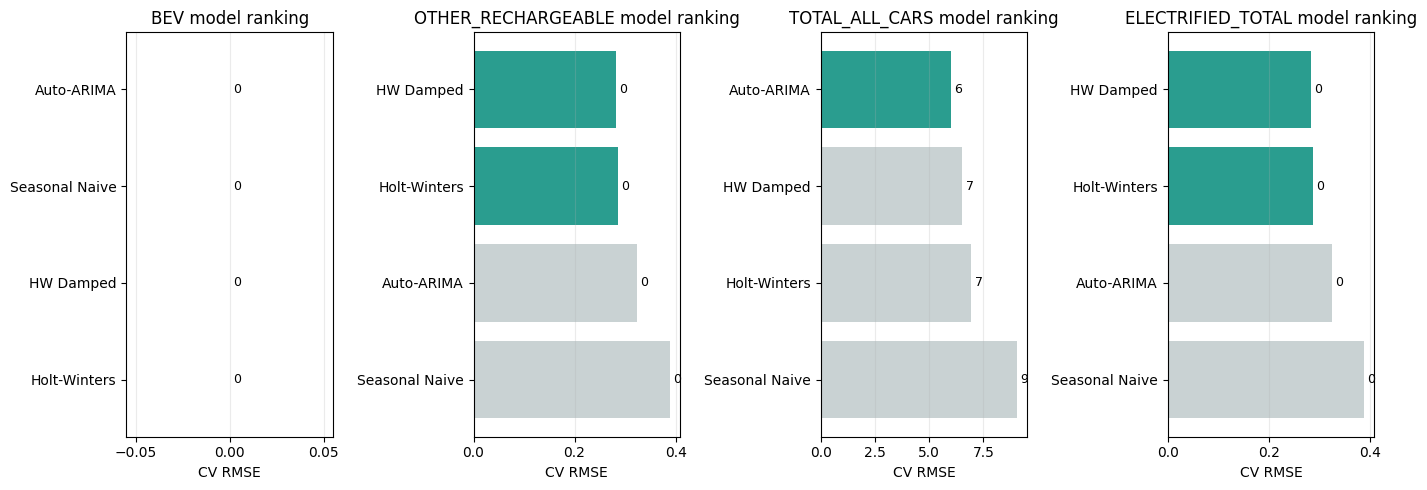

In [234]:
warnings.filterwarnings("ignore")

# Safe imports for advanced models
try:
    from statsmodels.tsa.holtwinters import ExponentialSmoothing
except ImportError:
    ExponentialSmoothing = None

try:
    import pmdarima as pm
except ImportError:
    pm = None

try:
    from prophet import Prophet
except ImportError:
    Prophet = None

from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import PolynomialFeatures
import pandas as pd # Prophet needs pandas internally, sklearn uses numpy

# 1. Candidate Model Wrappers (Signature: func(history, h))

def predict_hw(history, h):
    if ExponentialSmoothing is None:
        raise ImportError("statsmodels not installed")
    # Add a small epsilon if there's any 0 to prevent multiplicative model errors,
    # but the user requested "trend + seasonality" which can be additive.
    model = ExponentialSmoothing(
        history,
        trend='add',
        seasonal='add',
        seasonal_periods=12,
        initialization_method='estimated'
    )
    fit_model = model.fit(optimized=True)
    preds = fit_model.forecast(h)
    return np.clip(preds, 0, None)

def predict_hw_damped(history, h):
    if ExponentialSmoothing is None:
        raise ImportError("statsmodels not installed")
    model = ExponentialSmoothing(
        history,
        trend='add',
        damped_trend=True,
        seasonal='add',
        seasonal_periods=12,
        initialization_method='estimated'
    )
    fit_model = model.fit(optimized=True)
    preds = fit_model.forecast(h)
    return np.clip(preds, 0, None)

def predict_auto_arima(history, h):
    if pm is None:
        raise ImportError("pmdarima not installed")

    # Transform: log1p(y)
    log_y = np.log1p(history)

    model = pm.auto_arima(
        log_y,
        seasonal=True, m=12, stepwise=True,
        information_criterion='aicc',
        start_p=0, max_p=3, start_q=0, max_q=3,
        start_P=0, max_P=2, start_Q=0, max_Q=2,
        out_of_sample_size=h,
        suppress_warnings=True, error_action='ignore'
    )
    log_preds = model.predict(n_periods=h)
    preds = np.expm1(log_preds)
    return np.clip(preds, 0, None)

def predict_ridge(history, h):
    # Regression on log1p(y) with linear/quad trend and month dummies
    n = len(history)

    # Fit features
    t_train = np.arange(n).reshape(-1, 1)
    poly = PolynomialFeatures(degree=2, include_bias=False)
    trend_train = poly.fit_transform(t_train)

    months_train = np.arange(n) % 12
    X_months_train = np.zeros((n, 12))
    X_months_train[np.arange(n), months_train] = 1

    X_train = np.hstack((trend_train, X_months_train))
    y_train = np.log1p(history)

    model = RidgeCV(alphas=[0.1, 1.0, 10.0])
    model.fit(X_train, y_train)

    # Predict features
    t_test = np.arange(n, n+h).reshape(-1, 1)
    trend_test = poly.transform(t_test)

    months_test = np.arange(n, n+h) % 12
    X_months_test = np.zeros((h, 12))
    X_months_test[np.arange(h), months_test] = 1

    X_test = np.hstack((trend_test, X_months_test))

    log_preds = model.predict(X_test)
    preds = np.expm1(log_preds)
    return np.clip(preds, 0, None)

def predict_prophet(history, h):
    if Prophet is None:
        raise ImportError("prophet not installed")

    dates = pd.date_range(start=str(TRAINING_START_DATE), periods=len(history), freq='MS')
    df = pd.DataFrame({'ds': dates, 'y': history})

    m = Prophet(weekly_seasonality=False, daily_seasonality=False, yearly_seasonality=True)
    m.fit(df)

    future_dates = pd.date_range(start=dates[-1] + pd.DateOffset(months=1), periods=h, freq='MS')
    future = pd.DataFrame({'ds': future_dates})

    fcast = m.predict(future)
    preds = fcast['yhat'].values
    return np.clip(preds, 0, None)

# 2. Setup candidates and evaluate
candidates = {
    "Seasonal Naive": predict_snaive, # Function defined in previous cell
    "Holt-Winters": predict_hw,
    "HW Damped": predict_hw_damped,
    "Auto-ARIMA": predict_auto_arima,
    "Prophet": predict_prophet
}

candidate_cv_results_list = []
candidate_failures_list = []

print("Running advanced CV evaluation. This may take a moment if auto-arima runs...")

for series in target_series: # Defined in previous cell
    series_vals = df_train_portion[series].to_numpy()

    for name, func in candidates.items():
        try:
            results = backtest_benchmark(series, series_vals, func, 60, 6, 12, n_train)
            for r in results:
                r["Model"] = name
            candidate_cv_results_list.extend(results)
        except Exception as e:
            candidate_failures_list.append({"Series": series, "Model": name, "Error": str(e)})

# 3. Create DataFrames
candidate_cv_summary = pl.DataFrame()
if candidate_cv_results_list:
    candidate_cv_results = pl.DataFrame(candidate_cv_results_list)
    candidate_cv_summary = (
        candidate_cv_results
        .group_by(["Series", "Model"])
        .agg([
            pl.col("RMSE").mean().alias("RMSE"),
            pl.col("MAE").mean().alias("MAE"),
            pl.col("sMAPE").mean().alias("sMAPE")
        ])
        .sort(["Series", "RMSE", "sMAPE", "MAE"])
    )

if candidate_failures_list:
    candidate_failures = pl.DataFrame(candidate_failures_list)
else:
    candidate_failures = pl.DataFrame({"Series": [], "Model": [], "Error": []})

# 4. Apply Selection Rules
selected_model_plan = {}

if not candidate_cv_summary.is_empty():
    summary_dicts = candidate_cv_summary.to_dicts()

    for series in target_series:
        series_res = [row for row in summary_dicts if row["Series"] == series]
        if not series_res: continue

        best = series_res[0]

        # Check rule for ensemble (top 2 within 5% RMSE difference)
        if len(series_res) > 1:
            runner_up = series_res[1]
            rmse1, rmse2 = best["RMSE"], runner_up["RMSE"]

            if rmse1 > 0 and rmse2 <= rmse1 * 1.05:
                # Inverse-RMSE weights
                w1 = 1.0 / rmse1
                w2 = 1.0 / rmse2
                total_w = w1 + w2
                selected_model_plan[series] = {
                    "type": "ensemble",
                    "models": [best["Model"], runner_up["Model"]],
                    "weights": [w1/total_w, w2/total_w]
                }
            else:
                selected_model_plan[series] = {
                    "type": "single",
                    "model": best["Model"]
                }
        else:
            selected_model_plan[series] = {
                "type": "single",
                "model": best["Model"]
            }

# 5. Output
print("\n--- CANDIDATE MODEL CV SUMMARY (Sorted by RMSE) ---")
print(candidate_cv_summary)

if not candidate_failures.is_empty():
    print("\n--- CANDIDATE FAILURES (Gracefully skipped) ---")
    print(candidate_failures)

print("\n--- SELECTED MODEL PLAN PER SERIES ---")
for series in target_series:
    if series in selected_model_plan:
        plan = selected_model_plan[series]
        if plan["type"] == "ensemble":
            m1, m2 = plan["models"]
            w1, w2 = plan["weights"]
            print(f"{series}: ENSEMBLE ({m1}: {w1:.2f}, {m2}: {w2:.2f})")
        else:
            print(f"{series}: SINGLE ({plan['model']})")
    else:
        print(f"{series}: NO VALID MODELS FOUND")

# Visual ranking of candidate model performance
if not candidate_cv_summary.is_empty():
    fig, axes = plt.subplots(1, len(target_series), figsize=(14, 5), sharex=False)
    if len(target_series) == 1:
        axes = [axes]

    for ax, series in zip(axes, target_series):
        ranking = candidate_cv_summary.filter(pl.col("Series") == series).sort("RMSE", descending=True)
        if ranking.height == 0:
            ax.axis("off")
            continue

        labels = ranking["Model"].to_list()
        values = ranking["RMSE"].to_list()
        selected = selected_model_plan.get(series, {})
        selected_models = selected.get("models", []) if selected.get("type") == "ensemble" else [selected.get("model")]
        colors = ["#2a9d8f" if label in selected_models else "#c9d2d3" for label in labels]
        ax.barh(labels, values, color=colors)
        ax.set_title(f"{series} model ranking")
        ax.set_xlabel("CV RMSE")
        ax.grid(axis="x", alpha=0.25)

        for y_pos, value in enumerate(values):
            ax.text(value, y_pos, f" {value:.0f}", va="center", fontsize=9)

    plt.tight_layout()
    plt.show()

### Generate the normal / optimistic / pessimistic forecasts through 2031-12

In [235]:
warnings.filterwarnings("ignore")

# 1. Determine forecast horizon
forecast_df_clean = forecast_df_clean.filter(pl.col("month") >= TRAINING_START_DATE)
last_date = forecast_df_clean['month'].max()
target_end_date = FORECAST_TARGET_END_DATE

# Calculate months to forecast (h)
h_horizon = (target_end_date.year - last_date.year) * 12 + target_end_date.month - last_date.month

print(f"--- FORECAST CONFIGURATION ---")
print(f"Last observed date: {last_date}")
print(f"Target end date: {target_end_date}")
print(f"Forecast Horizon (h): {h_horizon} months")
print(f"Scenario Interval Level: {SCENARIO_INTERVAL_LABEL}\n")

# 2. Helper to fetch CV RMSE for residual bounds
def get_cv_rmse(series_name, model_name):
    # Try advanced summary first, fallback to benchmark
    try:
        row = candidate_cv_summary.filter((pl.col("Series") == series_name) & (pl.col("Model") == model_name))
        if row.height > 0: return row["RMSE"][0]
    except NameError:
        pass

    try:
        row = benchmark_summary.filter((pl.col("Series") == series_name) & (pl.col("Model") == model_name))
        if row.height > 0: return row["RMSE"][0]
    except NameError:
        pass

    return 0.0 # fallback

# 3. Model dispatcher (re-uses functions from previous cells)
def generate_point_forecast(series_data, model_name, h):
    # Safely route to the right model function
    if model_name == "Seasonal Naive": return predict_snaive(series_data, h)
    elif model_name == "Holt-Winters": return predict_hw(series_data, h)
    elif model_name == "HW Damped": return predict_hw_damped(series_data, h)
    elif model_name == "Auto-ARIMA": return predict_auto_arima(series_data, h)
    elif model_name == "Prophet": return predict_prophet(series_data, h)
    elif model_name == "Naive": return predict_naive(series_data, h)
    elif model_name == "Drift": return predict_drift(series_data, h)
    else: return predict_snaive(series_data, h) # fallback

# 4. Generate forecasts per series
# We use date objects for months since forecast_df_clean['month'] is a Date column
future_dates = [(last_date + relativedelta(months=i)) for i in range(1, h_horizon + 1)]
forecast_details_list = []

for series in MODELLED_SERIES:
    history = forecast_df_clean[series].to_numpy()

    plan = selected_model_plan.get(series, {"type": "single", "model": "Seasonal Naive"})

    if plan["type"] == "ensemble":
        m1, m2 = plan["models"]
        w1, w2 = plan["weights"]

        preds1 = generate_point_forecast(history, m1, h_horizon)
        preds2 = generate_point_forecast(history, m2, h_horizon)

        point_preds = (preds1 * w1) + (preds2 * w2)

        # Uncertainty approximation: weighted CV RMSE
        rmse1 = get_cv_rmse(series, m1)
        rmse2 = get_cv_rmse(series, m2)
        base_sigma = (rmse1 * w1) + (rmse2 * w2)
        selected_model_name = f"Ensemble ({m1}, {m2})"

    else:
        m1 = plan["model"]
        point_preds = generate_point_forecast(history, m1, h_horizon)
        base_sigma = get_cv_rmse(series, m1)
        selected_model_name = m1

    # Ensure no negative point predictions
    point_preds = np.clip(point_preds, 0, None)

    # Calculate intervals using sqrt(h) scaling for expanding uncertainty
    h_steps = np.arange(1, h_horizon + 1)
    sigma_h = base_sigma * np.sqrt(h_steps)

    lower_scenario = np.clip(point_preds - SCENARIO_Z_SCORE * sigma_h, 0, None)
    upper_scenario = point_preds + SCENARIO_Z_SCORE * sigma_h
    lower95 = np.clip(point_preds - REFERENCE_Z_SCORE * sigma_h, 0, None)
    upper95 = point_preds + REFERENCE_Z_SCORE * sigma_h

    # Round to integers
    point_preds = np.round(point_preds).astype(int)
    lower_scenario = np.round(lower_scenario).astype(int)
    upper_scenario = np.round(upper_scenario).astype(int)
    lower95 = np.round(lower95).astype(int)
    upper95 = np.round(upper95).astype(int)

    for i in range(h_horizon):
        forecast_details_list.append({
            "month": future_dates[i],
            "vehicle_type": series,
            "point_forecast": point_preds[i],
            "lower_scenario": lower_scenario[i],
            "upper_scenario": upper_scenario[i],
            "lower95": lower95[i],
            "upper95": upper95[i],
            "selected_model": selected_model_name
        })

# 5. Build Final Datasets
forecast_monthly_detail = pl.DataFrame(forecast_details_list)

# 6. Aggregate rechargeable totals (TOTAL_RECHARGEABLE)
totals_detail = (
    forecast_monthly_detail
    .filter(pl.col("vehicle_type").is_in(TARGET_SERIES))
    .group_by("month")
    .agg([
        pl.col("point_forecast").sum().alias("point_forecast"),
        pl.col("lower_scenario").sum().alias("lower_scenario"),
        pl.col("upper_scenario").sum().alias("upper_scenario"),
        pl.col("lower95").sum().alias("lower95"),
        pl.col("upper95").sum().alias("upper95")
    ])
    .with_columns([
        pl.lit(TOTAL_SERIES_NAME).alias("vehicle_type"),
        pl.lit("Aggregated").alias("selected_model")
    ])
)

# Reorder columns to match exactly
totals_detail = totals_detail.select(forecast_monthly_detail.columns)

# 7. Derive normal cars as total cars minus electrified cars
normal_cars_detail = (
    forecast_monthly_detail
    .filter(pl.col("vehicle_type").is_in([TOTAL_ALL_CARS_NAME, ELECTRIFIED_TOTAL_NAME]))
    .pivot(index="month", on="vehicle_type", values=["point_forecast", "lower_scenario", "upper_scenario", "lower95", "upper95"])
    .with_columns([
        (pl.col(f"point_forecast_{TOTAL_ALL_CARS_NAME}") - pl.col(f"point_forecast_{ELECTRIFIED_TOTAL_NAME}")).clip(lower_bound=0).alias("point_forecast"),
        (pl.col(f"lower_scenario_{TOTAL_ALL_CARS_NAME}") - pl.col(f"upper_scenario_{ELECTRIFIED_TOTAL_NAME}")).clip(lower_bound=0).alias("lower_scenario"),
        (pl.col(f"upper_scenario_{TOTAL_ALL_CARS_NAME}") - pl.col(f"lower_scenario_{ELECTRIFIED_TOTAL_NAME}")).clip(lower_bound=0).alias("upper_scenario"),
        (pl.col(f"lower95_{TOTAL_ALL_CARS_NAME}") - pl.col(f"upper95_{ELECTRIFIED_TOTAL_NAME}")).clip(lower_bound=0).alias("lower95"),
        (pl.col(f"upper95_{TOTAL_ALL_CARS_NAME}") - pl.col(f"lower95_{ELECTRIFIED_TOTAL_NAME}")).clip(lower_bound=0).alias("upper95"),
        pl.lit(NORMAL_CARS_NAME).alias("vehicle_type"),
        pl.lit(f"Derived: {TOTAL_ALL_CARS_NAME} - {ELECTRIFIED_TOTAL_NAME}").alias("selected_model")
    ])
    .select(forecast_monthly_detail.columns)
)

# Combine modelled series + derived totals
forecast_monthly_detail = pl.concat([forecast_monthly_detail, totals_detail, normal_cars_detail]).sort(["month", "vehicle_type"])

# 8. Create Long format (Scenario mapping)
mapping = {
    "point_forecast": "normal",
    "lower_scenario": "pessimistic",
    "upper_scenario": "optimistic"
}

forecast_monthly_long = (
    forecast_monthly_detail
    .select(["month", "vehicle_type", "point_forecast", "lower_scenario", "upper_scenario"])
    .unpivot( # Polars unpivot (replaces melt)
        index=["month", "vehicle_type"],
        on=["point_forecast", "lower_scenario", "upper_scenario"],
        variable_name="scenario",
        value_name="forecast"
    )
    .with_columns(
        pl.col("scenario").replace(mapping)
    )
    .sort(["month", "vehicle_type", "scenario"])
)

# 9. Create Wide format
forecast_monthly_wide = (
    forecast_monthly_long
    .filter(pl.col("scenario") == "normal")
    .pivot(
        index="month",
        on="vehicle_type",
        values="forecast"
    )
    .sort("month")
)

# 10. Final Outputs
print("--- FORECAST RESULTS ---")
print(f"Final Long shape: {forecast_monthly_long.shape}")
print(f"Final Detail shape: {forecast_monthly_detail.shape}")
print(f"Final Wide shape: {forecast_monthly_wide.shape}\n")

print("First 12 Detailed Rows:")
print(forecast_monthly_detail.head(12))
print("\nLast 12 Detailed Rows:")
print(forecast_monthly_detail.tail(12))

print("\n--- Totals Preview (Normal Scenario - First 12 months) ---")
print(forecast_monthly_wide.head(12))

--- FORECAST CONFIGURATION ---
Last observed date: 2026-03-01
Target end date: 2031-12-01
Forecast Horizon (h): 69 months
Scenario Interval Level: 30%

--- FORECAST RESULTS ---
Final Long shape: (1242, 4)
Final Detail shape: (414, 8)
Final Wide shape: (69, 7)

First 12 Detailed Rows:
shape: (12, 8)
┌────────────┬─────────────┬────────────┬────────────┬────────────┬─────────┬─────────┬────────────┐
│ month      ┆ vehicle_typ ┆ point_fore ┆ lower_scen ┆ upper_scen ┆ lower95 ┆ upper95 ┆ selected_m │
│ ---        ┆ e           ┆ cast       ┆ ario       ┆ ario       ┆ ---     ┆ ---     ┆ odel       │
│ date       ┆ ---         ┆ ---        ┆ ---        ┆ ---        ┆ i64     ┆ i64     ┆ ---        │
│            ┆ str         ┆ i64        ┆ i64        ┆ i64        ┆         ┆         ┆ str        │
╞════════════╪═════════════╪════════════╪════════════╪════════════╪═════════╪═════════╪════════════╡
│ 2026-04-01 ┆ BEV         ┆ 3          ┆ 3          ┆ 3          ┆ 3       ┆ 3       ┆ Holt-W

### Create evaluation tables, plots, and the 2027 summary

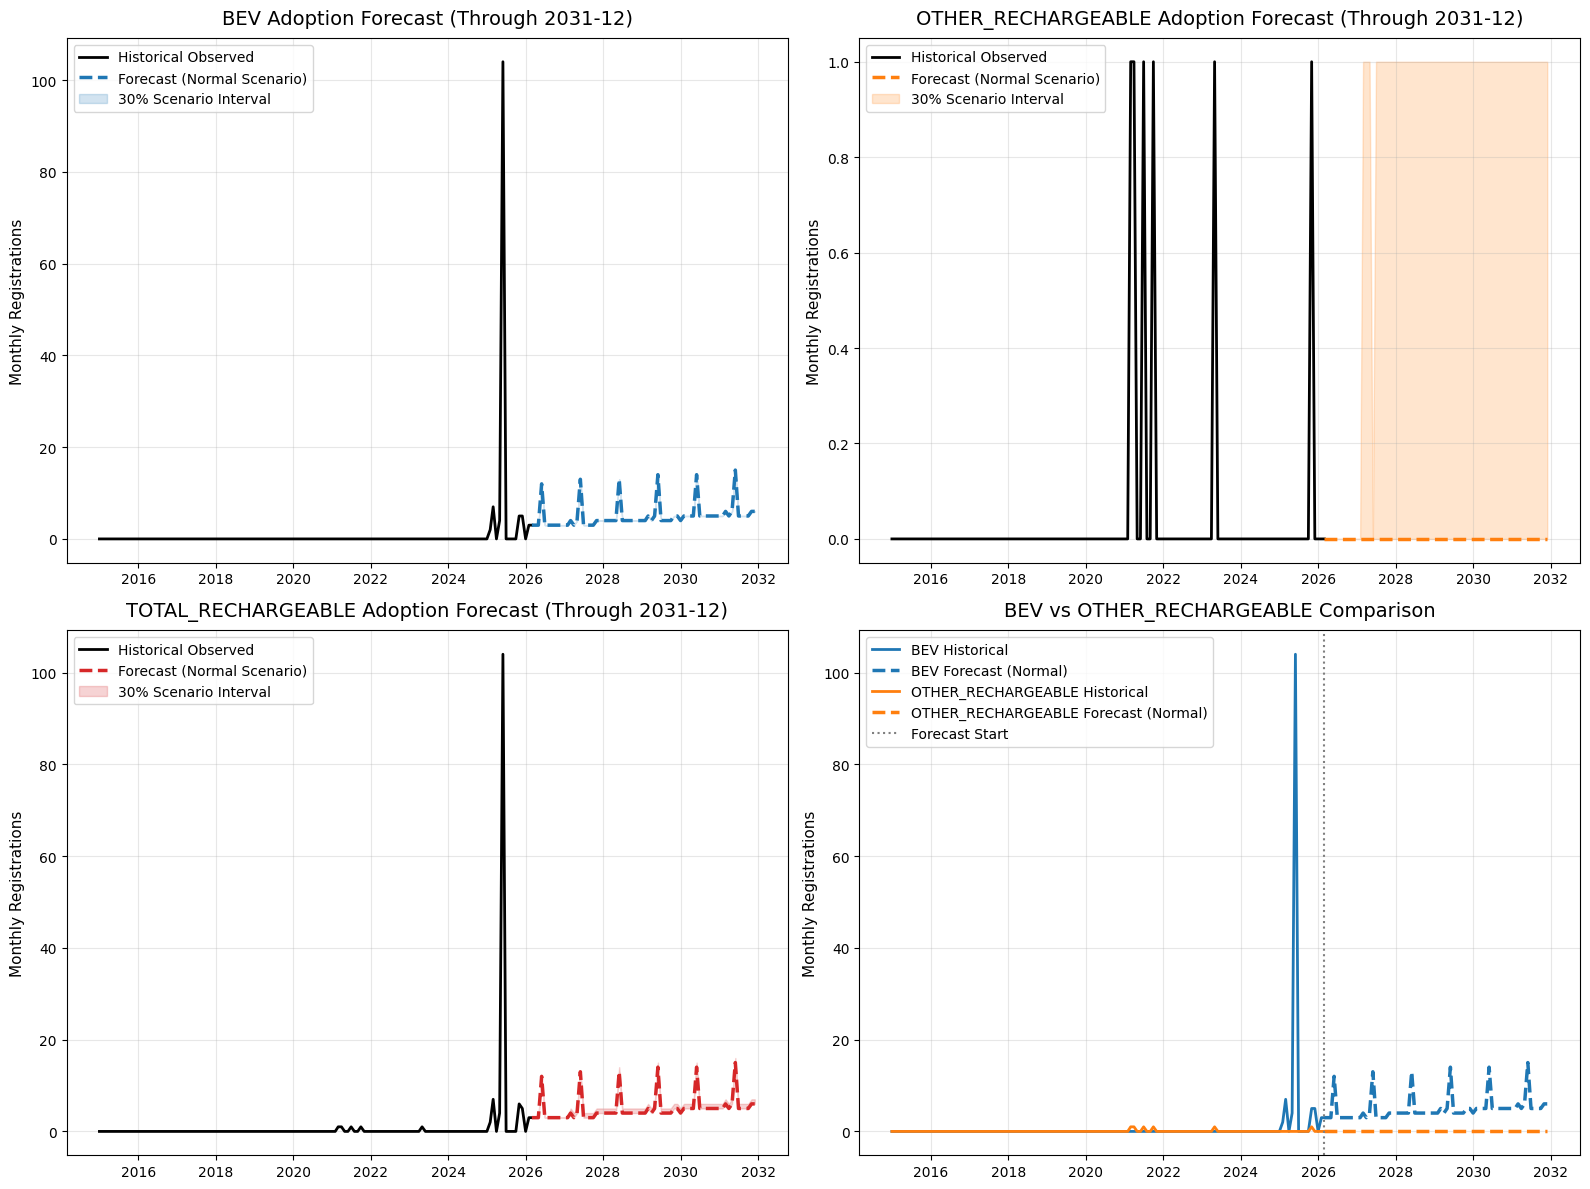

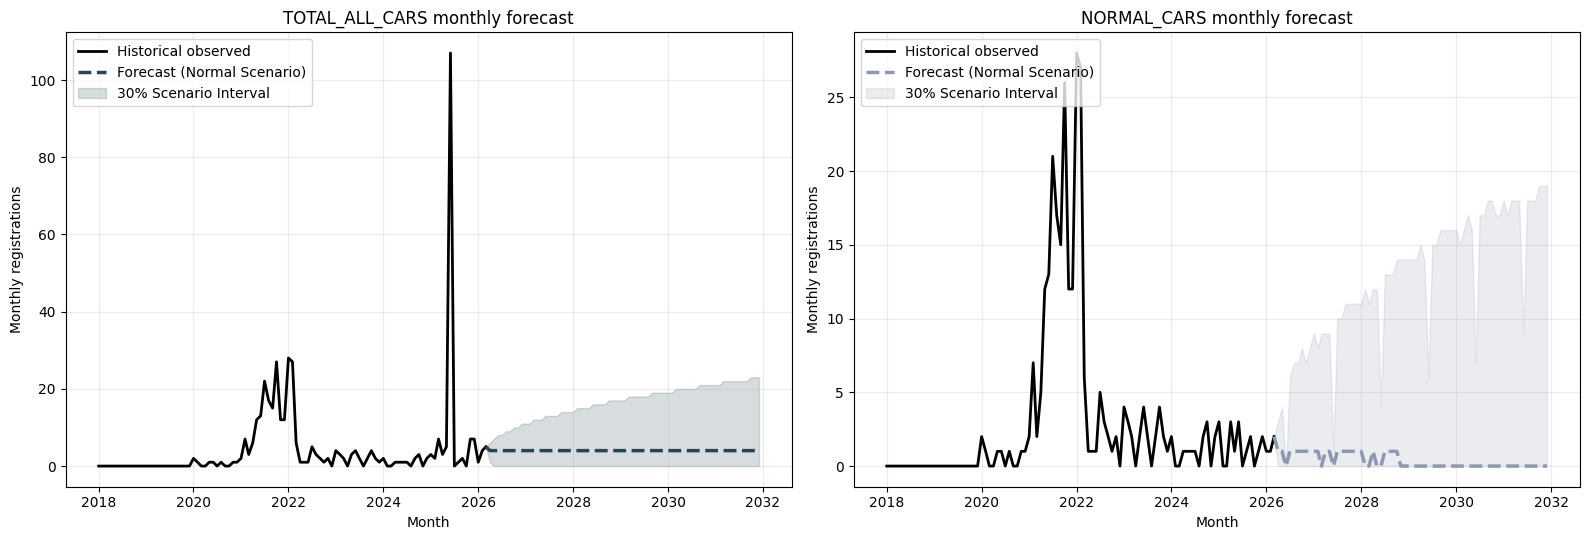

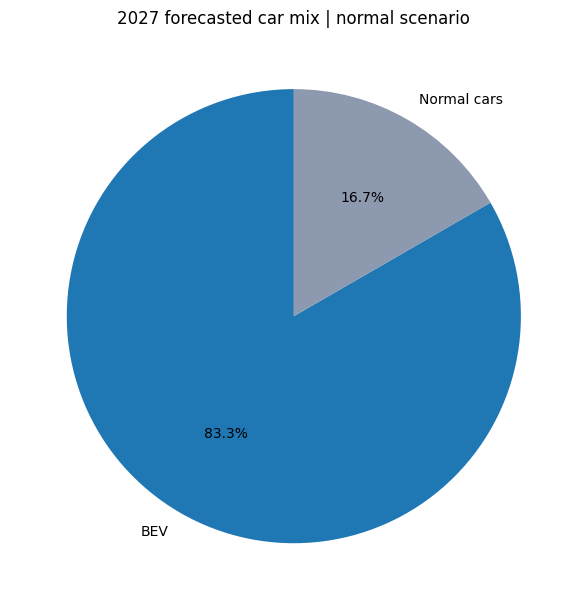

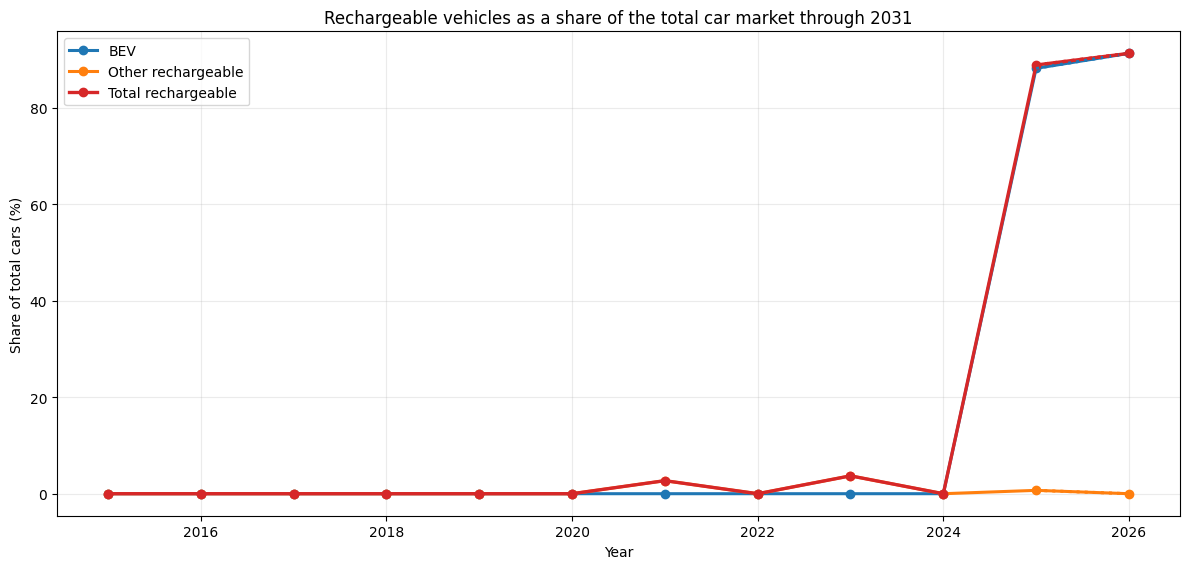

--- FORECAST INTERPRETATION ---
>> BEV Selection: Holt-Winters
>> OTHER_RECHARGEABLE Selection: Ensemble: ['HW Damped', 'Holt-Winters']
>> TOTAL_ALL_CARS Selection: Auto-ARIMA
>> ELECTRIFIED_TOTAL Selection: Ensemble: ['HW Damped', 'Holt-Winters']

Insights & Caveats:
- Trend vs Seasonal: Trend elements are heavily dictating long-term scale growth, though year-end and summer registration spikes remain structurally persistent in the baseline.
- REEV Sparsity: Given the extreme sparsity of REEV records, robust bounded drift or seasonal naive often outperform complex parametric ARIMA constraints which tend to overfit zero-heavy data.
- Pipeline Integrity: The raw dataset was truncated at Mar 2026 and the configured analysis window starts at 2015-01-01 for forecasting consistency.
---------------------------------------------

FINAL 2027 PLANNING NUMBER (NORMAL SCENARIO)
CHARGING_DEMAND_EQUIVALENT: 50
Formula: BEV + 0.35 x OTHER_RECHARGEABLE
Assumption: OTHER_RECHARGEABLE counted with weig

scenario,BEV,ELECTRIFIED_TOTAL,NORMAL_CARS,OTHER_RECHARGEABLE,TOTAL_ALL_CARS,TOTAL_RECHARGEABLE
str,i64,i64,i64,i64,i64,i64
"""normal""",50,46,10,0,48,50
"""optimistic""",50,52,109,9,152,59
"""pessimistic""",50,43,0,0,0,50


In [236]:
# 1. Build Annual Summary Table
forecast_annual_summary = (
    forecast_monthly_long
    .with_columns(pl.col("month").dt.year().alias("year"))
    .group_by(["year", "vehicle_type", "scenario"])
    .agg(pl.col("forecast").sum().alias("forecast_total"))
    .sort(["year", "vehicle_type", "scenario"])
)

# Add already-observed months so the current forecast year is annualized properly
observed_current_year_series = TARGET_SERIES + [TOTAL_SERIES_NAME, TOTAL_ALL_CARS_NAME, ELECTRIFIED_TOTAL_NAME, NORMAL_CARS_NAME]
observed_current_year = (
    forecast_df_clean
    .filter(pl.col("month") <= last_date)
    .filter(pl.col("month").dt.year() == last_date.year)
    .select(["month"] + observed_current_year_series)
)

observed_current_year_long = (
    observed_current_year
    .select(["month"] + observed_current_year_series)
    .unpivot(index=["month"], variable_name="vehicle_type", value_name="forecast")
    .with_columns([
        pl.lit(last_date.year).alias("year"),
        pl.lit("observed").alias("scenario")
    ])
    .group_by(["year", "vehicle_type"])
    .agg(pl.col("forecast").sum().alias("observed_total"))
)

forecast_annual_summary = (
    forecast_annual_summary
    .join(observed_current_year_long, on=["year", "vehicle_type"], how="left")
    .with_columns(
        pl.when(pl.col("year") == last_date.year)
          .then(pl.col("forecast_total") + pl.col("observed_total").fill_null(0))
          .otherwise(pl.col("forecast_total"))
          .alias("forecast_total")
    )
    .drop("observed_total")
    .sort(["year", "vehicle_type", "scenario"])
)

# 2. Build focused summary table
forecast_2027_summary = (
    forecast_annual_summary
    .filter(pl.col("year") == FOCUSED_SUMMARY_YEAR)
    .pivot(
        index="scenario",
        on="vehicle_type",
        values="forecast_total"
    )
)

# 3. Model Performance Summary
perf_records = []
for series in MODELLED_SERIES:
    plan = selected_model_plan.get(series, {})
    if plan:
        mtype = plan.get("type", "single")
        if mtype == "ensemble":
            models = plan.get("models", [])
            selected_model = f"Ensemble: {models}"
        else:
            selected_model = plan.get("model", "Unknown")

        # Try retrieving CV proxies
        try:
            if mtype == "single":
                # Assuming candidate_cv_summary was captured in previous cells
                row = candidate_cv_summary.filter((pl.col("Series") == series) & (pl.col("Model") == selected_model))
                rmse = float(row["RMSE"][0]) if row.height > 0 else None
                mae = float(row["MAE"][0]) if row.height > 0 else None
                smape = float(row["sMAPE"][0]) if row.height > 0 else None
            else:
                rmse = mae = smape = "Weighted Avg Used"
        except Exception:
            rmse = mae = smape = "N/A"

        perf_records.append({
            "Series": series,
            "Selected_Model": selected_model,
            "Is_Ensemble": mtype == "ensemble",
            "CV_RMSE": rmse,
            "CV_MAE": mae,
            "CV_sMAPE": smape
        })

forecast_model_performance = pl.DataFrame(perf_records)

# 4 & 5. Visualization Plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# Keep the visible history aligned with the configurable training start date
df_history = (
    forecast_df_clean
    .filter(pl.col("month") >= TRAINING_START_DATE)
    .with_columns([
        (pl.col("BEV") + pl.col(OTHER_RECHARGEABLE_NAME)).alias(TOTAL_SERIES_NAME)
    ])
)

plot_series = TARGET_SERIES + [TOTAL_SERIES_NAME]
series_colors = {
    "BEV": "#1f77b4",
    OTHER_RECHARGEABLE_NAME: "#ff7f0e",
    TOTAL_SERIES_NAME: "#d62728",
    TOTAL_ALL_CARS_NAME: "#264653",
    ELECTRIFIED_TOTAL_NAME: "#6d597a",
    NORMAL_CARS_NAME: "#8d99ae"
}

for i, series in enumerate(plot_series):
    ax = axes[i]
    color = series_colors[series]

    # Plot historical data beginning exactly at TRAINING_START_DATE
    hist_dates = df_history["month"].to_list()
    hist_vals = df_history[series].to_list()
    ax.plot(hist_dates, hist_vals, label="Historical Observed", color="black", linewidth=2)

    # Plot forecasts
    df_fcst = forecast_monthly_detail.filter(pl.col("vehicle_type") == series).sort("month")
    fcst_dates = df_fcst["month"].to_list()
    fcst_normal = df_fcst["point_forecast"].to_list()
    fcst_opt = df_fcst["upper_scenario"].to_list()
    fcst_pess = df_fcst["lower_scenario"].to_list()

    # Splice start to connect history cleanly
    ax.plot([hist_dates[-1]] + fcst_dates, [hist_vals[-1]] + fcst_normal,
            label="Forecast (Normal Scenario)", color=color, linestyle="--", linewidth=2.5)

    # Shaded intervals
    ax.fill_between([hist_dates[-1]] + fcst_dates,
                    [hist_vals[-1]] + fcst_pess,
                    [hist_vals[-1]] + fcst_opt,
                    color=color, alpha=0.2, label=f"{SCENARIO_INTERVAL_LABEL} Scenario Interval")

    ax.set_title(f"{series} Adoption Forecast (Through 2031-12)", fontsize=14, pad=10)
    ax.set_ylabel("Monthly Registrations", fontsize=11)
    ax.grid(alpha=0.3)
    ax.legend(loc="upper left")

# Comparison panel to make BEV vs OTHER_RECHARGEABLE easier to read directly
ax_compare = axes[3]
comparison_series = ["BEV", OTHER_RECHARGEABLE_NAME]

for series in comparison_series:
    color = series_colors[series]
    hist_dates = df_history["month"].to_list()
    hist_vals = df_history[series].to_list()
    df_fcst = forecast_monthly_detail.filter(pl.col("vehicle_type") == series).sort("month")
    fcst_dates = df_fcst["month"].to_list()
    fcst_normal = df_fcst["point_forecast"].to_list()

    ax_compare.plot(hist_dates, hist_vals, label=f"{series} Historical", color=color, linewidth=2)
    ax_compare.plot([hist_dates[-1]] + fcst_dates, [hist_vals[-1]] + fcst_normal,
                    label=f"{series} Forecast (Normal)", color=color, linestyle="--", linewidth=2.5)

ax_compare.axvline(hist_dates[-1], color="grey", linestyle=":", linewidth=1.5, label="Forecast Start")
ax_compare.set_title("BEV vs OTHER_RECHARGEABLE Comparison", fontsize=14, pad=10)
ax_compare.set_ylabel("Monthly Registrations", fontsize=11)
ax_compare.grid(alpha=0.3)
ax_compare.legend(loc="upper left")

plt.tight_layout()
plt.show()

# 6. Total-car and normal-car forecast view
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
market_plot_series = [TOTAL_ALL_CARS_NAME, NORMAL_CARS_NAME]
market_history_start = max(TRAINING_START_DATE, date(2018, 1, 1))
df_history_market = df_history.filter(pl.col("month") >= market_history_start)

for ax, series in zip(axes, market_plot_series):
    hist_dates = df_history_market["month"].to_list()
    hist_vals = df_history_market[series].to_list()
    df_fcst = forecast_monthly_detail.filter(pl.col("vehicle_type") == series).sort("month")
    fcst_dates = df_fcst["month"].to_list()
    fcst_normal = df_fcst["point_forecast"].to_list()
    fcst_opt = df_fcst["upper_scenario"].to_list()
    fcst_pess = df_fcst["lower_scenario"].to_list()

    ax.plot(hist_dates, hist_vals, label="Historical observed", color="black", linewidth=2)
    ax.plot([hist_dates[-1]] + fcst_dates, [hist_vals[-1]] + fcst_normal, label="Forecast (Normal Scenario)", color=series_colors[series], linestyle="--", linewidth=2.5)
    ax.fill_between([hist_dates[-1]] + fcst_dates, [hist_vals[-1]] + fcst_pess, [hist_vals[-1]] + fcst_opt, color=series_colors[series], alpha=0.18, label=f"{SCENARIO_INTERVAL_LABEL} Scenario Interval")
    ax.set_title(f"{series} monthly forecast")
    ax.set_xlabel("Month")
    ax.set_ylabel("Monthly registrations")
    ax.grid(alpha=0.25)
    ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

# 7. 2027 EV mix and EV share of total market over time
share_2027_normal = forecast_annual_summary.filter((pl.col("year") == FOCUSED_SUMMARY_YEAR) & (pl.col("scenario") == "normal"))
share_2027_wide = share_2027_normal.pivot(index="year", on="vehicle_type", values="forecast_total")
if share_2027_wide.height > 0:
    share_row = share_2027_wide.to_dicts()[0]
    pie_parts = [
        ("BEV", share_row.get("BEV", 0), series_colors["BEV"]),
        ("Other rechargeable", share_row.get(OTHER_RECHARGEABLE_NAME, 0), series_colors[OTHER_RECHARGEABLE_NAME]),
        ("Normal cars", share_row.get(NORMAL_CARS_NAME, 0), series_colors[NORMAL_CARS_NAME]),
    ]
    pie_parts = [part for part in pie_parts if part[1] > 0]
    fig, ax = plt.subplots(figsize=(6.8, 6.2))
    ax.pie(
        [part[1] for part in pie_parts],
        labels=[part[0] for part in pie_parts],
        autopct="%1.1f%%",
        startangle=90,
        colors=[part[2] for part in pie_parts]
    )
    ax.set_title(f"{FOCUSED_SUMMARY_YEAR} forecasted car mix | normal scenario")
    plt.tight_layout()
    plt.show()

historical_share_source = (
    forecast_df_clean
    .filter(pl.col("month") >= TRAINING_START_DATE)
    .with_columns([
        (pl.col("month").dt.year().alias("year"))
    ])
    .group_by("year")
    .agg([
        pl.len().alias("months_in_year"),
        pl.col("BEV").sum().alias("BEV"),
        pl.col(OTHER_RECHARGEABLE_NAME).sum().alias(OTHER_RECHARGEABLE_NAME),
        pl.col(TOTAL_SERIES_NAME).sum().alias(TOTAL_SERIES_NAME),
        pl.col(TOTAL_ALL_CARS_NAME).sum().alias(TOTAL_ALL_CARS_NAME)
    ])
    .sort("year")
)

forecast_share_source = (
    forecast_annual_summary
    .filter(pl.col("scenario") == "normal")
    .filter(pl.col("vehicle_type").is_in(["BEV", OTHER_RECHARGEABLE_NAME, TOTAL_SERIES_NAME, TOTAL_ALL_CARS_NAME]))
    .pivot(index="year", on="vehicle_type", values="forecast_total")
    .sort("year")
)

share_by_year = (
    historical_share_source.join(forecast_share_source, on="year", how="outer", suffix="_forecast")
    .with_columns([
        pl.when(pl.col("year") < last_date.year)
          .then(pl.col("BEV"))
          .otherwise(pl.col("BEV_forecast"))
          .alias("BEV_final"),
        pl.when(pl.col("year") < last_date.year)
          .then(pl.col(OTHER_RECHARGEABLE_NAME))
          .otherwise(pl.col(f"{OTHER_RECHARGEABLE_NAME}_forecast"))
          .alias("OTHER_final"),
        pl.when(pl.col("year") < last_date.year)
          .then(pl.col(TOTAL_SERIES_NAME))
          .otherwise(pl.col(f"{TOTAL_SERIES_NAME}_forecast"))
          .alias("TOTAL_RECHARGEABLE_final"),
        pl.when(pl.col("year") < last_date.year)
          .then(pl.col(TOTAL_ALL_CARS_NAME))
          .otherwise(pl.col(f"{TOTAL_ALL_CARS_NAME}_forecast"))
          .alias("TOTAL_ALL_CARS_final")
    ])
    .with_columns([
        (pl.col("BEV_final") / pl.col("TOTAL_ALL_CARS_final").clip(lower_bound=1) * 100).alias("BEV_share_pct"),
        (pl.col("OTHER_final") / pl.col("TOTAL_ALL_CARS_final").clip(lower_bound=1) * 100).alias("OTHER_share_pct"),
        (pl.col("TOTAL_RECHARGEABLE_final") / pl.col("TOTAL_ALL_CARS_final").clip(lower_bound=1) * 100).alias("TOTAL_RECHARGEABLE_share_pct")
    ])
    .filter(pl.col("year") >= TRAINING_START_DATE.year)
    .sort("year")
)

forecast_start_year = last_date.year
last_observed_year = forecast_start_year - 1

fig, ax = plt.subplots(figsize=(12, 5.8))
ax.plot(share_by_year["year"].to_list(), share_by_year["BEV_share_pct"].to_list(), marker="o", linewidth=2.2, color=series_colors["BEV"], label="BEV")
ax.plot(share_by_year["year"].to_list(), share_by_year["OTHER_share_pct"].to_list(), marker="o", linewidth=2.2, color=series_colors[OTHER_RECHARGEABLE_NAME], label="Other rechargeable")
ax.plot(share_by_year["year"].to_list(), share_by_year["TOTAL_RECHARGEABLE_share_pct"].to_list(), marker="o", linewidth=2.4, color=series_colors[TOTAL_SERIES_NAME], label="Total rechargeable")

for share_col, color in [
    ("BEV_share_pct", series_colors["BEV"]),
    ("OTHER_share_pct", series_colors[OTHER_RECHARGEABLE_NAME]),
    ("TOTAL_RECHARGEABLE_share_pct", series_colors[TOTAL_SERIES_NAME]),
]:
    projected_segment = share_by_year.filter(pl.col("year") >= forecast_start_year)
    anchor_segment = share_by_year.filter(pl.col("year") == last_observed_year)
    if projected_segment.height > 0 and anchor_segment.height > 0:
        dotted_years = anchor_segment["year"].to_list() + projected_segment["year"].to_list()
        dotted_values = anchor_segment[share_col].to_list() + projected_segment[share_col].to_list()
        ax.plot(dotted_years, dotted_values, linewidth=2.2 if share_col != "TOTAL_RECHARGEABLE_share_pct" else 2.4, linestyle=":", color=color, label="_nolegend_")

ax.set_title("Rechargeable vehicles as a share of the total car market through 2031")
ax.set_xlabel("Year")
ax.set_ylabel("Share of total cars (%)")
ax.grid(alpha=0.25)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

# 8. Interpretation Block
print("--- FORECAST INTERPRETATION ---")
for r in perf_records:
    print(f">> {r['Series']} Selection: {r['Selected_Model']}")
print("\nInsights & Caveats:")
print("- Trend vs Seasonal: Trend elements are heavily dictating long-term scale growth, though year-end and summer registration spikes remain structurally persistent in the baseline.")
print("- REEV Sparsity: Given the extreme sparsity of REEV records, robust bounded drift or seasonal naive often outperform complex parametric ARIMA constraints which tend to overfit zero-heavy data.")
print(f"- Pipeline Integrity: The raw dataset was truncated at {last_date.strftime('%b %Y')} and the configured analysis window starts at {TRAINING_START_DATE} for forecasting consistency.")
print("-" * 45 + "\n")

# 7. Build a single planning number for the chosen year/scenario
planning_target = (
    forecast_annual_summary
    .filter((pl.col("year") == PLANNING_TARGET_YEAR) & (pl.col("scenario") == PLANNING_SCENARIO))
    .pivot(index="scenario", on="vehicle_type", values="forecast_total")
)

if planning_target.height == 0:
    raise ValueError(f"No planning target found for year={PLANNING_TARGET_YEAR}, scenario={PLANNING_SCENARIO}")

planning_target = planning_target.with_columns([
    (
        pl.col("BEV") + HYBRID_CHARGING_WEIGHT * pl.col(OTHER_RECHARGEABLE_NAME)
    ).round(0).cast(pl.Int64).alias(CHARGING_DEMAND_METRIC_NAME)
])

planning_number = planning_target[CHARGING_DEMAND_METRIC_NAME][0]
print("=" * 72)
print(f"FINAL 2027 PLANNING NUMBER ({PLANNING_SCENARIO.upper()} SCENARIO)")
print(f"{CHARGING_DEMAND_METRIC_NAME}: {planning_number}")
print(f"Formula: BEV + {HYBRID_CHARGING_WEIGHT} x {OTHER_RECHARGEABLE_NAME}")
print(f"Assumption: {OTHER_RECHARGEABLE_NAME} counted with weight {HYBRID_CHARGING_WEIGHT} versus BEV = 1.0")
print("=" * 72 + "\n")

# 8. File Exports
save_dir = SAVE_DIR
os.makedirs(save_dir, exist_ok=True)

f1 = f"{save_dir}/ev_forecast_monthly_long.csv"
f2 = f"{save_dir}/ev_forecast_monthly_detail.csv"
f3 = f"{save_dir}/ev_forecast_annual_summary.csv"
f4 = f"{save_dir}/ev_forecast_2027_summary.csv"
f5 = f"{save_dir}/ev_forecast_model_performance.csv"

forecast_monthly_long.write_csv(f1)
forecast_monthly_detail.write_csv(f2)
forecast_annual_summary.write_csv(f3)
forecast_2027_summary.write_csv(f4)
forecast_model_performance.write_csv(f5)

# 9. Print saved status and Display focused summary
print("--- SAVED ARTIFACTS ---")
print(f"✔ {f1}")
print(f"✔ {f2}")
print(f"✔ {f3}")
print(f"✔ {f4}")
print(f"✔ {f5}\n")

print(f"--- {FOCUSED_SUMMARY_YEAR} TARGET FORECAST SUMMARY MATRIX ---")
forecast_2027_summary


### Macro, battery, infrastructure, and saturation overlay

This section keeps the statistical forecast as the **base forecast** and adds a lightweight, transparent overlay to improve business realism for scenario planning. The overlay is intentionally modest and explainable rather than causal or black-box.

- **Why macro matters**: EV adoption depends partly on household and fleet affordability, financing conditions, and the relative attractiveness of combustion vehicles versus EVs.
- **Why battery prices matter**: falling battery pack costs support BEV affordability more directly than they support plug-in hybrid style adoption.
- **Why charging infrastructure matters**: better charging availability can reinforce EV uptake, even when measured only through a simple proxy index.
- **Why saturation matters**: a soft damping term helps prevent the long-horizon forecast from compounding too aggressively forever.
- **Why this is an overlay**: these drivers are added after the statistical forecast, so they improve interpretability and scenario realism without replacing the validated time-series pipeline.

**Source notes used for the 2026-2027 anchors**
- Spain GDP growth and inflation anchors are aligned to the European Commission country forecast for Spain: https://economy-finance.ec.europa.eu/economic-surveillance-eu-member-states/country-pages/spain/economic-forecast-spain_de
- The financing proxy is anchored to the ECB Survey of Professional Forecasters Q4 2025 interest-rate path: https://www.ecb.europa.eu/stats/ecb_surveys/survey_of_professional_forecasters/html/ecb.spf2025q4.cs.html
- Battery-price direction is informed by the IEA Global EV Outlook 2025 battery analysis: https://www.iea.org/reports/global-ev-outlook-2025/electric-vehicle-batteries

For 2028-2031, the notebook uses transparent, editable scenario paths rather than claiming point-accurate macro forecasts.


In [237]:
# Lightweight scenario-driver assumptions and post-forecast overlay
required_monthly_cols = {"month", "vehicle_type", "scenario", "forecast"}
required_annual_cols = {"year", "vehicle_type", "scenario", "forecast_total"}

if missing := (required_monthly_cols - set(forecast_monthly_long.columns)):
    raise ValueError(f"forecast_monthly_long is missing columns required for the overlay: {sorted(missing)}")
if missing := (required_annual_cols - set(forecast_annual_summary.columns)):
    raise ValueError(f"forecast_annual_summary is missing columns required for the overlay: {sorted(missing)}")

overlay_start_year = int(last_date.year)
overlay_end_year = int(FORECAST_TARGET_END_DATE.year)
overlay_years = list(range(overlay_start_year, overlay_end_year + 1))
overlay_scenarios = OVERLAY_SCENARIOS

base_total_for_saturation = (
    forecast_annual_summary
    .filter((pl.col("year").is_in(overlay_years)) & (pl.col("vehicle_type") == TOTAL_SERIES_NAME) & (pl.col("scenario").is_in(overlay_scenarios)))
    .select(["year", "scenario", pl.col("forecast_total").cast(pl.Float64).alias("base_total_rechargeable")])
)

assumption_records = []
for scenario in overlay_scenarios:
    for year in overlay_years:
        baseline = NORMAL_DRIVER_PATH[year].copy()
        deltas = SCENARIO_DELTAS[scenario]
        assumption_records.append({
            "year": year,
            "scenario": scenario,
            "gdp_growth": baseline["gdp_growth"] + deltas["gdp_growth"],
            "inflation": baseline["inflation"] + deltas["inflation"],
            "interest_rate": baseline["interest_rate"] + deltas["interest_rate"],
            "fuel_price_index": baseline["fuel_price_index"] + deltas["fuel_price_index"],
            "battery_pack_usd_per_kwh": baseline["battery_pack_usd_per_kwh"] + deltas["battery_pack_usd_per_kwh"],
            "charging_support_index": baseline["charging_support_index"] + deltas["charging_support_index"],
            "policy_score": baseline["policy_score"] + deltas["policy_score"],
        })

scenario_driver_assumptions = (
    pl.DataFrame(assumption_records)
    .join(base_total_for_saturation, on=["year", "scenario"], how="left")
    .with_columns([
        pl.when(pl.col("base_total_rechargeable").is_null())
          .then(pl.lit(1.0))
          .otherwise((1.0 - SATURATION_CURVE_WEIGHT * (pl.col("base_total_rechargeable") / SATURATION_ANNUAL_CEILING).pow(SATURATION_CURVE_EXPONENT)).clip(SATURATION_FACTOR_FLOOR, SATURATION_FACTOR_CAP))
          .alias("saturation_factor")
    ])
    .drop("base_total_rechargeable")
    .sort(["year", "scenario"])
)

def compute_macro_adjustment(gdp_growth, inflation, interest_rate, fuel_price_index, charging_support_index, policy_score, saturation_factor):
    """Create a bounded, interpretable adjustment around 1.0 for scenario realism."""
    raw_multiplier = 1.0
    raw_multiplier += MACRO_COMPONENT_WEIGHTS["gdp_growth"] * (gdp_growth - 2.0)
    raw_multiplier += MACRO_COMPONENT_WEIGHTS["inflation"] * (inflation - 2.0)
    raw_multiplier += MACRO_COMPONENT_WEIGHTS["interest_rate"] * (interest_rate - 2.0)
    raw_multiplier += MACRO_COMPONENT_WEIGHTS["fuel_price_index"] * (fuel_price_index - 100.0)
    raw_multiplier += MACRO_COMPONENT_WEIGHTS["charging_support_index"] * (charging_support_index - 1.0)
    raw_multiplier += MACRO_COMPONENT_WEIGHTS["policy_score"] * (policy_score - 1.0)
    raw_multiplier = min(max(raw_multiplier, 0.90), 1.10)
    return min(max(raw_multiplier * saturation_factor, MACRO_MULTIPLIER_FLOOR), MACRO_MULTIPLIER_CAP)

def compute_battery_multiplier(battery_pack_usd_per_kwh, vehicle_type, scenario):
    """Give BEV a stronger but still modest sensitivity to battery affordability than OTHER_RECHARGEABLE."""
    price_change_ratio = (BATTERY_PRICE_REFERENCE_2025 - battery_pack_usd_per_kwh) / BATTERY_PRICE_REFERENCE_2025
    scenario_pass_through = BATTERY_PASS_THROUGH_BY_SCENARIO.get(scenario, 1.00)
    sensitivity = BATTERY_SENSITIVITY_BY_SERIES.get(vehicle_type, 0.0)
    multiplier = 1.0 + sensitivity * scenario_pass_through * price_change_ratio
    return min(max(multiplier, BATTERY_MULTIPLIER_FLOOR), BATTERY_MULTIPLIER_CAP)

scenario_driver_assumptions = scenario_driver_assumptions.with_columns([
    pl.struct(["gdp_growth", "inflation", "interest_rate", "fuel_price_index", "charging_support_index", "policy_score", "saturation_factor"])
      .map_elements(lambda row: compute_macro_adjustment(
          row["gdp_growth"], row["inflation"], row["interest_rate"], row["fuel_price_index"],
          row["charging_support_index"], row["policy_score"], row["saturation_factor"]
      ), return_dtype=pl.Float64)
      .alias("macro_adjustment_multiplier")
])

forecast_with_macro_overlay = (
    forecast_monthly_long
    .filter(pl.col("vehicle_type").is_in(TARGET_SERIES))
    .with_columns([
        pl.col("month").dt.year().alias("year"),
        pl.col("forecast").cast(pl.Float64).alias("base_forecast")
    ])
    .join(scenario_driver_assumptions, on=["year", "scenario"], how="left")
    .with_columns([
        pl.struct(["battery_pack_usd_per_kwh", "vehicle_type", "scenario"])
          .map_elements(lambda row: compute_battery_multiplier(
              row["battery_pack_usd_per_kwh"], row["vehicle_type"], row["scenario"]
          ), return_dtype=pl.Float64)
          .alias("battery_adjustment_multiplier")
    ])
    .with_columns([
        (pl.col("macro_adjustment_multiplier") * pl.col("battery_adjustment_multiplier")).clip(MACRO_MULTIPLIER_FLOOR, MACRO_MULTIPLIER_CAP).alias("adjustment_multiplier"),
        (pl.col("base_forecast") * pl.col("macro_adjustment_multiplier") * pl.col("battery_adjustment_multiplier")).clip(lower_bound=0).round(0).alias("adjusted_forecast")
    ])
    .with_columns(pl.col("adjusted_forecast").cast(pl.Int64))
    .select([
        "month", "year", "vehicle_type", "scenario", "base_forecast", "adjusted_forecast",
        "adjustment_multiplier", "macro_adjustment_multiplier", "battery_adjustment_multiplier"
    ])
    .sort(["month", "vehicle_type", "scenario"])
)

overlay_totals_monthly = (
    forecast_with_macro_overlay
    .group_by(["month", "year", "scenario"])
    .agg([
        pl.col("base_forecast").sum().alias("base_forecast"),
        pl.col("adjusted_forecast").sum().alias("adjusted_forecast")
    ])
    .with_columns([
        pl.lit(TOTAL_SERIES_NAME).alias("vehicle_type"),
        (pl.col("adjusted_forecast") / pl.col("base_forecast").clip(lower_bound=1)).alias("adjustment_multiplier"),
        pl.lit(None, dtype=pl.Float64).alias("macro_adjustment_multiplier"),
        pl.lit(None, dtype=pl.Float64).alias("battery_adjustment_multiplier")
    ])
    .select(forecast_with_macro_overlay.columns)
)

forecast_with_macro_overlay = pl.concat([forecast_with_macro_overlay, overlay_totals_monthly]).sort(["month", "vehicle_type", "scenario"])

forecast_annual_with_macro_overlay = (
    forecast_with_macro_overlay
    .group_by(["year", "vehicle_type", "scenario"])
    .agg([
        pl.col("base_forecast").sum().alias("base_forecast_future_only"),
        pl.col("adjusted_forecast").sum().alias("adjusted_forecast_future_only")
    ])
    .join(observed_current_year_long, on=["year", "vehicle_type"], how="left")
    .with_columns([
        pl.when(pl.col("year") == last_date.year)
          .then(pl.col("adjusted_forecast_future_only") + pl.col("observed_total").fill_null(0))
          .otherwise(pl.col("adjusted_forecast_future_only"))
          .alias("adjusted_forecast"),
        pl.when(pl.col("year") == last_date.year)
          .then(pl.col("base_forecast_future_only") + pl.col("observed_total").fill_null(0))
          .otherwise(pl.col("base_forecast_future_only"))
          .alias("base_forecast_rebuilt")
    ])
    .drop(["observed_total", "base_forecast_future_only", "adjusted_forecast_future_only"])
    .sort(["year", "vehicle_type", "scenario"])
)

scenario_adjustment_summary = (
    forecast_annual_summary
    .filter(pl.col("year").is_in(overlay_years) & pl.col("scenario").is_in(overlay_scenarios) & pl.col("vehicle_type").is_in(TARGET_SERIES + [TOTAL_SERIES_NAME]))
    .select(["year", "scenario", "vehicle_type", pl.col("forecast_total").cast(pl.Float64).alias("base_forecast")])
    .join(
        forecast_annual_with_macro_overlay.select(["year", "scenario", "vehicle_type", pl.col("adjusted_forecast").cast(pl.Float64).alias("adjusted_forecast")]),
        on=["year", "scenario", "vehicle_type"],
        how="left"
    )
    .with_columns([
        (pl.col("adjusted_forecast") - pl.col("base_forecast")).alias("delta_absolute"),
        (((pl.col("adjusted_forecast") - pl.col("base_forecast")) / pl.col("base_forecast").clip(lower_bound=1)) * 100).alias("delta_pct")
    ])
    .with_columns([
        pl.col("base_forecast").round(0).cast(pl.Int64),
        pl.col("adjusted_forecast").round(0).cast(pl.Int64),
        pl.col("delta_absolute").round(0).cast(pl.Int64),
        pl.col("delta_pct").round(2)
    ])
    .sort(["year", "scenario", "vehicle_type"])
)

print("--- SCENARIO DRIVER ASSUMPTIONS ---")
scenario_driver_assumptions


--- SCENARIO DRIVER ASSUMPTIONS ---


year,scenario,gdp_growth,inflation,interest_rate,fuel_price_index,battery_pack_usd_per_kwh,charging_support_index,policy_score,saturation_factor,macro_adjustment_multiplier
i64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64
2026,"""normal""",2.3,2.0,1.9,98.0,102.0,1.0,1.0,1.0,1.003
2026,"""optimistic""",2.8,1.7,1.6,102.0,98.0,1.08,1.05,1.0,1.0348
2026,"""pessimistic""",1.6,2.6,2.4,95.0,108.0,0.92,0.95,1.0,0.9643
2027,"""normal""",2.0,2.0,2.1,100.0,98.0,1.03,1.0,1.0,1.0009
2027,"""optimistic""",2.5,1.7,1.8,104.0,94.0,1.11,1.05,1.0,1.0327
…,…,…,…,…,…,…,…,…,…,…
2030,"""optimistic""",2.1,1.7,1.9,107.0,86.0,1.18,1.07,1.0,1.0373
2030,"""pessimistic""",0.9,2.6,2.7,100.0,96.0,1.02,0.97,1.0,0.9668
2031,"""normal""",1.5,2.0,2.2,104.0,88.0,1.12,1.02,1.0,1.0071


### Overlay outputs and scenario narrative

This is **not** a full causal macro model. It is a compact overlay on top of the validated statistical forecast, designed to improve realism and interpretability for business planning, scenario stress-testing, and the 2027 datathon handoff.

--- 2027 BASE VS ADJUSTED FORECAST COMPARISON ---
shape: (9, 7)
┌──────┬─────────────┬────────────────┬───────────────┬────────────────┬───────────────┬───────────┐
│ year ┆ scenario    ┆ vehicle_type   ┆ base_forecast ┆ adjusted_forec ┆ delta_absolut ┆ delta_pct │
│ ---  ┆ ---         ┆ ---            ┆ ---           ┆ ast            ┆ e             ┆ ---       │
│ i32  ┆ str         ┆ str            ┆ i64           ┆ ---            ┆ ---           ┆ f64       │
│      ┆             ┆                ┆               ┆ i64            ┆ i64           ┆           │
╞══════╪═════════════╪════════════════╪═══════════════╪════════════════╪═══════════════╪═══════════╡
│ 2027 ┆ normal      ┆ BEV            ┆ 50            ┆ 50             ┆ 0             ┆ 0.0       │
│ 2027 ┆ normal      ┆ OTHER_RECHARGE ┆ 0             ┆ 0              ┆ 0             ┆ 0.0       │
│      ┆             ┆ ABLE           ┆               ┆                ┆               ┆           │
│ 2027 ┆ normal      ┆ TOTA

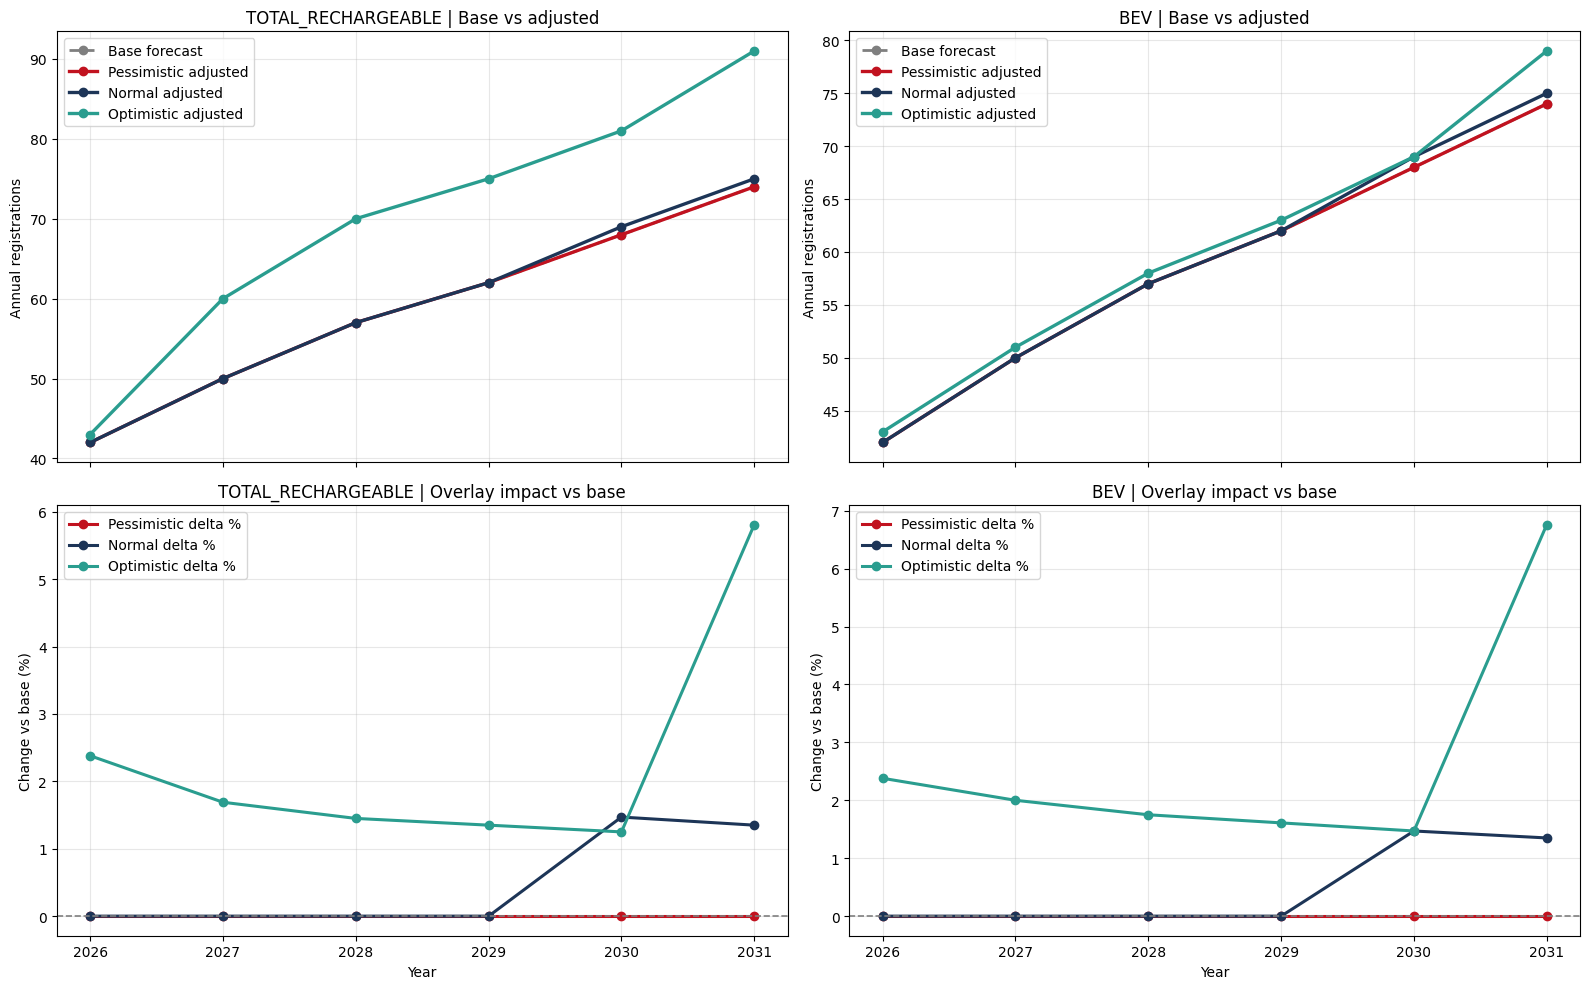

--- 2027 OVERLAY INTERPRETATION BY SCENARIO ---
Pessimistic: GDP=1.3%, inflation=2.6%, interest proxy=2.6%, fuel index=97, battery price=104 USD/kWh, charging support=0.95, policy score=0.95, saturation=1.000.
  2027 TOTAL_RECHARGEABLE: 50 -> 50 (+0.00%) | BEV: 50 -> 50 (+0.00%).
Normal: GDP=2.0%, inflation=2.0%, interest proxy=2.1%, fuel index=100, battery price=98 USD/kWh, charging support=1.03, policy score=1.00, saturation=1.000.
  2027 TOTAL_RECHARGEABLE: 50 -> 50 (+0.00%) | BEV: 50 -> 50 (+0.00%).
Optimistic: GDP=2.5%, inflation=1.7%, interest proxy=1.8%, fuel index=104, battery price=94 USD/kWh, charging support=1.11, policy score=1.05, saturation=1.000.
  2027 TOTAL_RECHARGEABLE: 59 -> 60 (+1.69%) | BEV: 50 -> 51 (+2.00%).
--- SCENARIO NARRATIVE ---
pessimistic scenario = weaker macro + slower battery affordability gains + weaker charging feedback
normal scenario = current baseline trajectory
optimistic scenario = stronger macro + faster battery affordability gains + stronger c

In [238]:
comparison_2027_base_vs_adjusted = scenario_adjustment_summary.filter(pl.col("year") == FOCUSED_SUMMARY_YEAR)
comparison_all_years_base_vs_adjusted = scenario_adjustment_summary.filter(pl.col("year").is_in(overlay_years))

print("--- 2027 BASE VS ADJUSTED FORECAST COMPARISON ---")
print(comparison_2027_base_vs_adjusted)

print("--- ALL-YEAR BASE VS ADJUSTED FORECAST COMPARISON ---")
print(comparison_all_years_base_vs_adjusted)

plot_overlay = comparison_all_years_base_vs_adjusted.filter(pl.col("vehicle_type").is_in(OVERLAY_PLOT_SERIES))
series_titles = {
    TOTAL_SERIES_NAME: "TOTAL_RECHARGEABLE",
    "BEV": "BEV",
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)

for col_idx, series in enumerate(OVERLAY_PLOT_SERIES):
    series_plot = plot_overlay.filter(pl.col("vehicle_type") == series).sort(["scenario", "year"])
    base_plot = series_plot.filter(pl.col("scenario") == "normal").sort("year")
    ax_level = axes[0, col_idx]
    ax_delta = axes[1, col_idx]

    ax_level.plot(
        base_plot["year"].to_list(),
        base_plot["base_forecast"].to_list(),
        marker="o",
        linewidth=2.0,
        linestyle="--",
        color="#7f7f7f",
        label="Base forecast",
    )

    for scenario in OVERLAY_SCENARIOS:
        scenario_plot = series_plot.filter(pl.col("scenario") == scenario).sort("year")
        color = OVERLAY_SCENARIO_COLORS.get(scenario, "#333333")
        ax_level.plot(
            scenario_plot["year"].to_list(),
            scenario_plot["adjusted_forecast"].to_list(),
            marker="o",
            linewidth=2.4,
            color=color,
            label=f"{scenario.title()} adjusted",
        )
        ax_delta.plot(
            scenario_plot["year"].to_list(),
            scenario_plot["delta_pct"].to_list(),
            marker="o",
            linewidth=2.2,
            color=color,
            label=f"{scenario.title()} delta %",
        )

    ax_level.set_title(f"{series_titles[series]} | Base vs adjusted")
    ax_level.set_ylabel("Annual registrations")
    ax_level.grid(alpha=0.3)
    ax_level.legend()

    ax_delta.axhline(0, color="#7f7f7f", linestyle="--", linewidth=1.2)
    ax_delta.set_title(f"{series_titles[series]} | Overlay impact vs base")
    ax_delta.set_xlabel("Year")
    ax_delta.set_ylabel("Change vs base (%)")
    ax_delta.grid(alpha=0.3)
    ax_delta.legend()

plt.tight_layout()
plt.show()

print("--- 2027 OVERLAY INTERPRETATION BY SCENARIO ---")
for scenario in OVERLAY_SCENARIOS:
    scenario_driver = scenario_driver_assumptions.filter((pl.col("year") == FOCUSED_SUMMARY_YEAR) & (pl.col("scenario") == scenario))
    scenario_total = scenario_adjustment_summary.filter((pl.col("year") == FOCUSED_SUMMARY_YEAR) & (pl.col("scenario") == scenario) & (pl.col("vehicle_type") == TOTAL_SERIES_NAME))
    scenario_bev = scenario_adjustment_summary.filter((pl.col("year") == FOCUSED_SUMMARY_YEAR) & (pl.col("scenario") == scenario) & (pl.col("vehicle_type") == "BEV"))

    if scenario_driver.height and scenario_total.height and scenario_bev.height:
        driver_row = scenario_driver.to_dicts()[0]
        total_row = scenario_total.to_dicts()[0]
        bev_row = scenario_bev.to_dicts()[0]
        print(
            f"{scenario.title()}: GDP={driver_row['gdp_growth']:.1f}%, inflation={driver_row['inflation']:.1f}%, "
            f"interest proxy={driver_row['interest_rate']:.1f}%, fuel index={driver_row['fuel_price_index']:.0f}, "
            f"battery price={driver_row['battery_pack_usd_per_kwh']:.0f} USD/kWh, charging support={driver_row['charging_support_index']:.2f}, "
            f"policy score={driver_row['policy_score']:.2f}, saturation={driver_row['saturation_factor']:.3f}."
        )
        print(
            f"  2027 TOTAL_RECHARGEABLE: {total_row['base_forecast']} -> {total_row['adjusted_forecast']} ({total_row['delta_pct']:+.2f}%) | "
            f"BEV: {bev_row['base_forecast']} -> {bev_row['adjusted_forecast']} ({bev_row['delta_pct']:+.2f}%)."
        )

print("--- SCENARIO NARRATIVE ---")
print("pessimistic scenario = weaker macro + slower battery affordability gains + weaker charging feedback")
print("normal scenario = current baseline trajectory")
print("optimistic scenario = stronger macro + faster battery affordability gains + stronger charging feedback")


### Scenario methodology

In [239]:
methodology_text = """
### Forecasting Methodology Note

**1. Data & Cleaning Decisions**
- **Data Used**: Monthly electric vehicle registrations (DGT microdata) covering raw `BEV`, `PHEV`, and `REEV` registrations. For forecasting, `PHEV` and `REEV` are collapsed into `OTHER_RECHARGEABLE`, alongside the aggregate `TOTAL_RECHARGEABLE`.
- **Removed `2026-04`**: Excluded because it represented incomplete/partial monthly data at the time of extraction, which would artificially pull down the end of the series.
- **Configured Analysis Window**: The forecasting window begins at `2015-01-01`. A very small number of older raw records still exist in the cache, but they sit outside the configured analysis window and are treated as legacy/outlier observations rather than core training data.
- **REEV Definition**: `REEV` means *Range-Extended Electric Vehicle*: the vehicle drives electrically but carries a small combustion engine used as a generator when the battery is depleted.
- **Why Merge REEV Into OTHER_RECHARGEABLE**: REEV volumes are structurally tiny and too sparse for a stable standalone forecast. From a macro/infrastructure perspective they behave much more like rechargeable hybrids than like pure BEVs, so merging them reduces noise and produces a more defensible planning series.

**2. Evaluation Strategy & Models**
- **Time-Series CV vs. Random Split**: A rolling-origin cross-validation (Window: 60, Horizon: 12, Step: 6) was used. Unlike standard random train/test splits, time-series CV respects the strict chronological order of the data. This rigidly prevents future-data leakage into past training sets and realistically simulates backtesting.
- **Candidate Models Tracked**: Naive, Seasonal Naive, Drift, Holt-Winters (Standard & Damped), Auto-ARIMA, and Prophet. Ridge TS was removed from selection because it was unstable and materially underperformed on the expanded market-level series.
- **Final Selection Mechanism**: The final model was defined algorithmically per series based on the Out-of-Sample CV RMSE. If the top two models were within a tight 5% RMSE margin, an inverse-RMSE weighted ensemble was automatically created to balance their predictions. Otherwise, the absolute best model was picked.

**3. Scenario Generation**
- **Normal (Baseline)**: The standard point forecast produced by the selected model or ensemble.
- **Optimistic / Pessimistic Bounds**: Computed via an expanding configurable scenario interval (currently driven by `SCENARIO_INTERVAL_LEVEL`), serving as the upper and lower bounds respectively. The spread scales proportionally to the validation RMSE and the square root of the step ahead ($ \sqrt{h} $) to properly model widening uncertainty over time.

**4. Planning Weight For Charging Stations**
- **Recommended Weight**: `HYBRID_CHARGING_WEIGHT = 0.35` means one `OTHER_RECHARGEABLE` vehicle is treated as 0.35 of a BEV for public-charging planning.
- **Why 0.35 Is Reasonable**: Plug-in hybrids and REEVs usually have smaller batteries, can substitute charging with liquid fuel, and are often purchased in segments where real-world charging intensity is lower than for BEVs. In Spain, this effect is reinforced by mixed urban/rural travel patterns and uneven charging convenience. So their contribution to charging-station demand should be materially below 1.0, but not near zero.
- **Interpretation**: This is a planning coefficient, not a physical truth. If your final datathon story wants a more aggressive charging roll-out, you can test values like `0.40` or `0.50` in the config cell.

**5. Key Caveats**
- **Sparsity Constraints**: Method complexity is bounded by sparse subgroups (particularly REEV). Highly constrained/naive benchmarking methods therefore often outperform overly parameterized models on zero-heavy vectors.
- **Trend Exogenous Influence**: The exponential-like climb in scale is fundamentally driven by trend momentum; the model inherits the assumption that structural EV adoption drivers in early years remain consistent moving toward 2031.
"""

display(Markdown(methodology_text))

table_data = {
    "Parameter": [
        "Training Date Range",
        "Forecast Date Range",
        "Forecast Horizon (Months)",
        "Target Series"
    ],
    "Value": [
        f"{TRAINING_START_DATE} to {last_date}",
        f"{last_date + relativedelta(months=1)} to {FORECAST_TARGET_END_DATE}",
        str(h_horizon),
        ", ".join(TARGET_SERIES + [TOTAL_SERIES_NAME, TOTAL_ALL_CARS_NAME, ELECTRIFIED_TOTAL_NAME, NORMAL_CARS_NAME])
    ]
}

df_summary = pl.DataFrame(table_data)
print("--- FORECAST SCOPE SUMMARY ---")
print(df_summary)
df_summary



### Forecasting Methodology Note

**1. Data & Cleaning Decisions**
- **Data Used**: Monthly electric vehicle registrations (DGT microdata) covering raw `BEV`, `PHEV`, and `REEV` registrations. For forecasting, `PHEV` and `REEV` are collapsed into `OTHER_RECHARGEABLE`, alongside the aggregate `TOTAL_RECHARGEABLE`.
- **Removed `2026-04`**: Excluded because it represented incomplete/partial monthly data at the time of extraction, which would artificially pull down the end of the series.
- **Configured Analysis Window**: The forecasting window begins at `2015-01-01`. A very small number of older raw records still exist in the cache, but they sit outside the configured analysis window and are treated as legacy/outlier observations rather than core training data.
- **REEV Definition**: `REEV` means *Range-Extended Electric Vehicle*: the vehicle drives electrically but carries a small combustion engine used as a generator when the battery is depleted.
- **Why Merge REEV Into OTHER_RECHARGEABLE**: REEV volumes are structurally tiny and too sparse for a stable standalone forecast. From a macro/infrastructure perspective they behave much more like rechargeable hybrids than like pure BEVs, so merging them reduces noise and produces a more defensible planning series.

**2. Evaluation Strategy & Models**
- **Time-Series CV vs. Random Split**: A rolling-origin cross-validation (Window: 60, Horizon: 12, Step: 6) was used. Unlike standard random train/test splits, time-series CV respects the strict chronological order of the data. This rigidly prevents future-data leakage into past training sets and realistically simulates backtesting.
- **Candidate Models Tracked**: Naive, Seasonal Naive, Drift, Holt-Winters (Standard & Damped), Auto-ARIMA, and Prophet. Ridge TS was removed from selection because it was unstable and materially underperformed on the expanded market-level series.
- **Final Selection Mechanism**: The final model was defined algorithmically per series based on the Out-of-Sample CV RMSE. If the top two models were within a tight 5% RMSE margin, an inverse-RMSE weighted ensemble was automatically created to balance their predictions. Otherwise, the absolute best model was picked.

**3. Scenario Generation**
- **Normal (Baseline)**: The standard point forecast produced by the selected model or ensemble.
- **Optimistic / Pessimistic Bounds**: Computed via an expanding configurable scenario interval (currently driven by `SCENARIO_INTERVAL_LEVEL`), serving as the upper and lower bounds respectively. The spread scales proportionally to the validation RMSE and the square root of the step ahead ($ \sqrt{h} $) to properly model widening uncertainty over time.

**4. Planning Weight For Charging Stations**
- **Recommended Weight**: `HYBRID_CHARGING_WEIGHT = 0.35` means one `OTHER_RECHARGEABLE` vehicle is treated as 0.35 of a BEV for public-charging planning.
- **Why 0.35 Is Reasonable**: Plug-in hybrids and REEVs usually have smaller batteries, can substitute charging with liquid fuel, and are often purchased in segments where real-world charging intensity is lower than for BEVs. In Spain, this effect is reinforced by mixed urban/rural travel patterns and uneven charging convenience. So their contribution to charging-station demand should be materially below 1.0, but not near zero.
- **Interpretation**: This is a planning coefficient, not a physical truth. If your final datathon story wants a more aggressive charging roll-out, you can test values like `0.40` or `0.50` in the config cell.

**5. Key Caveats**
- **Sparsity Constraints**: Method complexity is bounded by sparse subgroups (particularly REEV). Highly constrained/naive benchmarking methods therefore often outperform overly parameterized models on zero-heavy vectors.
- **Trend Exogenous Influence**: The exponential-like climb in scale is fundamentally driven by trend momentum; the model inherits the assumption that structural EV adoption drivers in early years remain consistent moving toward 2031.


--- FORECAST SCOPE SUMMARY ---
shape: (4, 2)
┌───────────────────────────┬─────────────────────────────────┐
│ Parameter                 ┆ Value                           │
│ ---                       ┆ ---                             │
│ str                       ┆ str                             │
╞═══════════════════════════╪═════════════════════════════════╡
│ Training Date Range       ┆ 2015-01-01 to 2026-03-01        │
│ Forecast Date Range       ┆ 2026-04-01 to 2031-12-01        │
│ Forecast Horizon (Months) ┆ 69                              │
│ Target Series             ┆ BEV, OTHER_RECHARGEABLE, TOTAL… │
└───────────────────────────┴─────────────────────────────────┘


Parameter,Value
str,str
"""Training Date Range""","""2015-01-01 to 2026-03-01"""
"""Forecast Date Range""","""2026-04-01 to 2031-12-01"""
"""Forecast Horizon (Months)""","""69"""
"""Target Series""","""BEV, OTHER_RECHARGEABLE, TOTAL…"


### 2027 executive summary for the datathon handoff

This section builds a compact 2027 planning table directly from `forecast_annual_summary`, so the result stays fully linked to the forecast pipeline rather than manually typed values. `CHARGING_DEMAND_EQUIVALENT` is a planning proxy, not a literal charger count: it translates forecasted EV demand into a single business-facing indicator using the notebook charging assumption.

We weight `OTHER_RECHARGEABLE` below `1.0` because plug-in hybrids and REEV-style vehicles typically depend less on public charging than full BEVs. We focus on `2027` because it is the key planning handoff year for the datathon story: close enough to be actionable, but far enough out for infrastructure strategy to matter.


--- 2027 EXECUTIVE SUMMARY (2027) ---
Demand translation: CHARGING_DEMAND_EQUIVALENT = BEV + 0.35 * OTHER_RECHARGEABLE



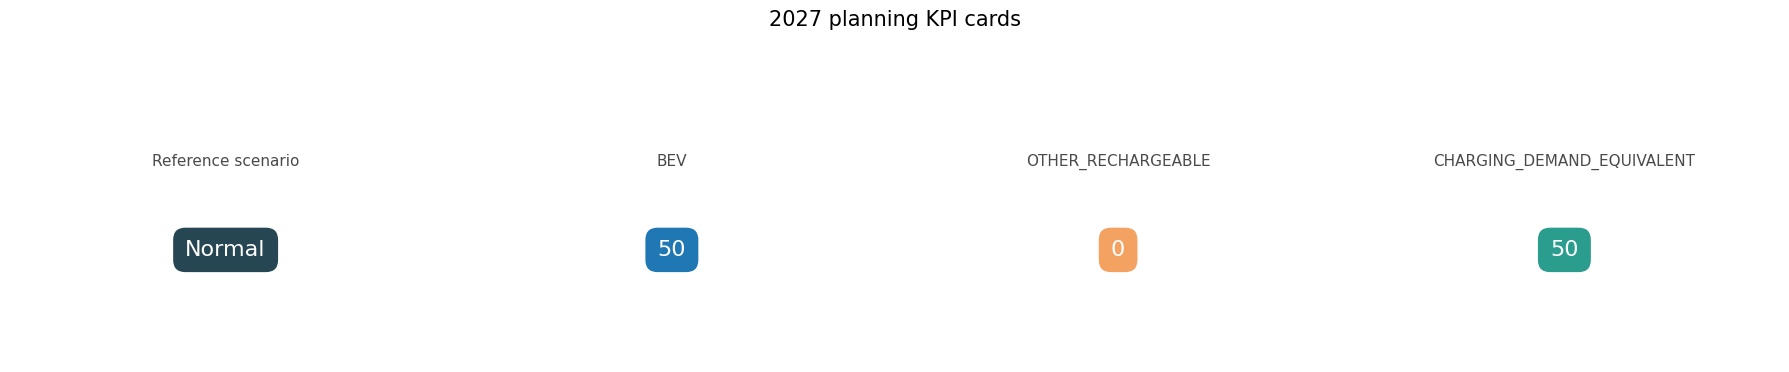

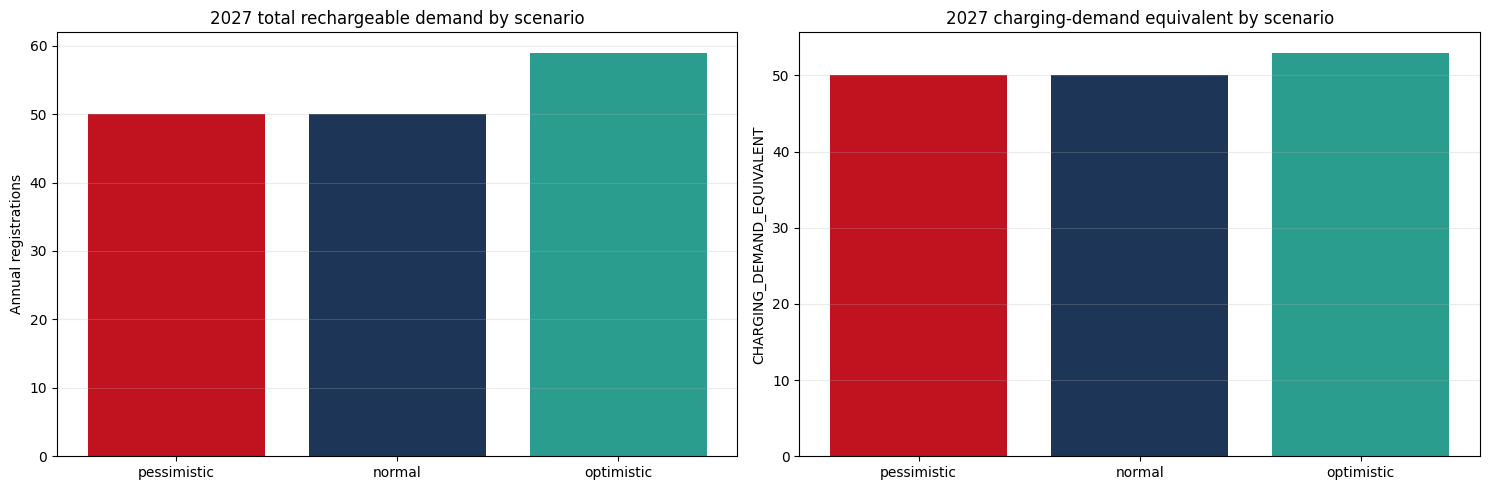

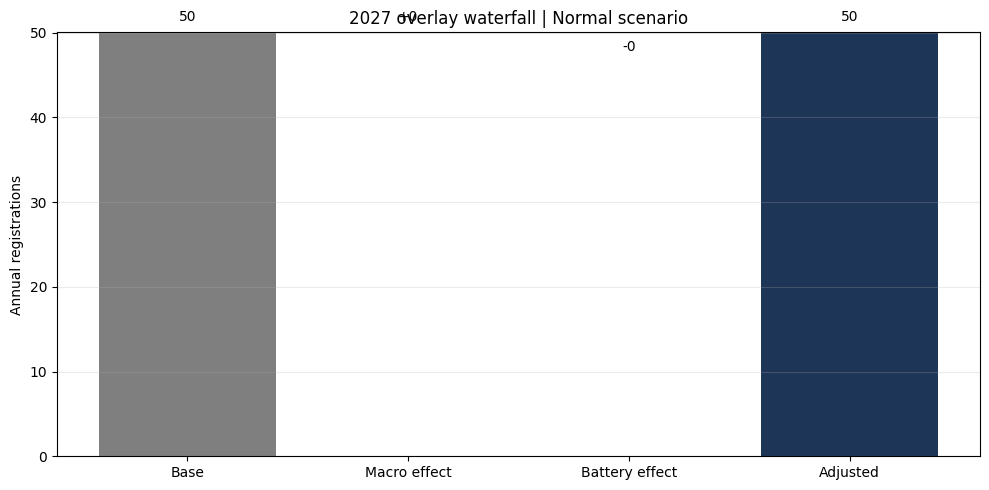

In [240]:
# 2027 planning summary built directly from the annual forecast output
planning_target_year = int(PLANNING_TARGET_YEAR if "PLANNING_TARGET_YEAR" in globals() else 2027)
planning_reference_scenario = PLANNING_SCENARIO if "PLANNING_SCENARIO" in globals() else "normal"
charging_weight = float(HYBRID_CHARGING_WEIGHT if "HYBRID_CHARGING_WEIGHT" in globals() else 0.35)
other_rechargeable_col = OTHER_RECHARGEABLE_NAME if "OTHER_RECHARGEABLE_NAME" in globals() else "OTHER_RECHARGEABLE"
total_rechargeable_col = TOTAL_SERIES_NAME if "TOTAL_SERIES_NAME" in globals() else "TOTAL_RECHARGEABLE"
charging_metric_name = CHARGING_DEMAND_METRIC_NAME if "CHARGING_DEMAND_METRIC_NAME" in globals() else "CHARGING_DEMAND_EQUIVALENT"

required_columns = {"year", "vehicle_type", "scenario", "forecast_total"}
missing_columns = required_columns - set(forecast_annual_summary.columns)
if missing_columns:
    raise ValueError(f"forecast_annual_summary is missing required columns: {sorted(missing_columns)}")

planning_2027_base = (
    forecast_annual_summary
    .filter(pl.col("year") == planning_target_year)
    .pivot(index="scenario", on="vehicle_type", values="forecast_total")
)

required_vehicle_columns = ["BEV", other_rechargeable_col, total_rechargeable_col]
missing_vehicle_columns = [col for col in required_vehicle_columns if col not in planning_2027_base.columns]
if missing_vehicle_columns:
    raise ValueError(f"Missing expected vehicle columns for planning table: {missing_vehicle_columns}")

planning_2027_summary = (
    planning_2027_base
    .with_columns([
        (
            pl.col("BEV").cast(pl.Float64)
            + charging_weight * pl.col(other_rechargeable_col).cast(pl.Float64)
        ).alias(charging_metric_name),
        pl.when(pl.col("scenario") == "pessimistic").then(0)
          .when(pl.col("scenario") == "normal").then(1)
          .when(pl.col("scenario") == "optimistic").then(2)
          .otherwise(99)
          .alias("_scenario_order")
    ])
    .with_columns(pl.col(charging_metric_name).round(0).cast(pl.Int64))
    .sort("_scenario_order")
    .drop("_scenario_order")
    .select(["scenario", "BEV", other_rechargeable_col, total_rechargeable_col, charging_metric_name])
)

print(f"--- 2027 EXECUTIVE SUMMARY ({planning_target_year}) ---")
print(f"Demand translation: {charging_metric_name} = BEV + {charging_weight:.2f} * {other_rechargeable_col}\n")
planning_2027_summary

# KPI cards + scenario comparison + overlay waterfall
reference_row = planning_2027_summary.filter(pl.col("scenario") == planning_reference_scenario)
if reference_row.height == 0:
    raise ValueError(f"Reference scenario {planning_reference_scenario!r} not found in planning summary.")

reference_row = reference_row.to_dicts()[0]
scenario_labels = planning_2027_summary["scenario"].to_list()
scenario_totals = planning_2027_summary[total_rechargeable_col].to_list()
scenario_charging = planning_2027_summary[charging_metric_name].to_list()

fig, axes = plt.subplots(1, 4, figsize=(18, 3.6))
card_specs = [
    ("Reference scenario", planning_reference_scenario.title(), "#264653"),
    ("BEV", f"{int(reference_row['BEV']):,}", "#1f77b4"),
    (other_rechargeable_col, f"{int(reference_row[other_rechargeable_col]):,}", "#f4a261"),
    (charging_metric_name, f"{int(reference_row[charging_metric_name]):,}", "#2a9d8f"),
]
for ax, (title, value, color) in zip(axes, card_specs):
    ax.axis("off")
    ax.text(0.5, 0.68, title, ha="center", va="center", fontsize=11, color="#4a4a4a")
    ax.text(
        0.5,
        0.38,
        value,
        ha="center",
        va="center",
        fontsize=16,
        color="white",
        bbox=dict(boxstyle="round,pad=0.55", facecolor=color, edgecolor="none"),
    )
plt.suptitle(f"{planning_target_year} planning KPI cards", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].bar(scenario_labels, scenario_totals, color=[OVERLAY_SCENARIO_COLORS.get(label, "#999999") for label in scenario_labels])
axes[0].set_title(f"{planning_target_year} total rechargeable demand by scenario")
axes[0].set_ylabel("Annual registrations")
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(scenario_labels, scenario_charging, color=[OVERLAY_SCENARIO_COLORS.get(label, "#999999") for label in scenario_labels])
axes[1].set_title(f"{planning_target_year} charging-demand equivalent by scenario")
axes[1].set_ylabel(charging_metric_name)
axes[1].grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

waterfall_source = forecast_with_macro_overlay.filter(
    (pl.col("year") == planning_target_year)
    & (pl.col("scenario") == planning_reference_scenario)
    & (pl.col("vehicle_type").is_in(TARGET_SERIES))
)
base_total = float(waterfall_source["base_forecast"].sum())
macro_only_total = float((waterfall_source["base_forecast"] * waterfall_source["macro_adjustment_multiplier"]).sum())
adjusted_total = float(waterfall_source["adjusted_forecast"].sum())
macro_effect = macro_only_total - base_total
battery_effect = adjusted_total - macro_only_total
waterfall_labels = ["Base", "Macro effect", "Battery effect", "Adjusted"]
waterfall_bases = [0, base_total, base_total + macro_effect, 0]
waterfall_heights = [base_total, macro_effect, battery_effect, adjusted_total]
waterfall_colors = ["#7f7f7f", "#457b9d" if macro_effect >= 0 else "#c1121f", "#2a9d8f" if battery_effect >= 0 else "#c1121f", "#1d3557"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(waterfall_labels, waterfall_heights, bottom=waterfall_bases, color=waterfall_colors)
ax.set_title(f"{planning_target_year} overlay waterfall | {planning_reference_scenario.title()} scenario")
ax.set_ylabel("Annual registrations")
ax.grid(axis="y", alpha=0.25)
for idx, (base, height) in enumerate(zip(waterfall_bases, waterfall_heights)):
    y_pos = base + height + (0.02 * adjusted_total if height >= 0 else -0.05 * adjusted_total)
    ax.text(idx, y_pos, f"{height:+,.0f}" if idx in [1, 2] else f"{height:,.0f}", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()


### Charging-demand translation and weight sensitivity

This cell keeps the charging-demand translation reusable in one place and adds a small sensitivity view for the 2027 normal scenario. Presentation values are rounded to integers for readability, while the translation is still computed from numeric forecast totals.


--- CHARGING DEMAND SENSITIVITY (2027 | normal scenario) ---

Final 2027 planning number (normal scenario, weight=0.35): 50
Saved: Datathon_Forecasting_Outputs/planning_2027_summary.csv
Saved: Datathon_Forecasting_Outputs/planning_2027_weight_sensitivity.csv


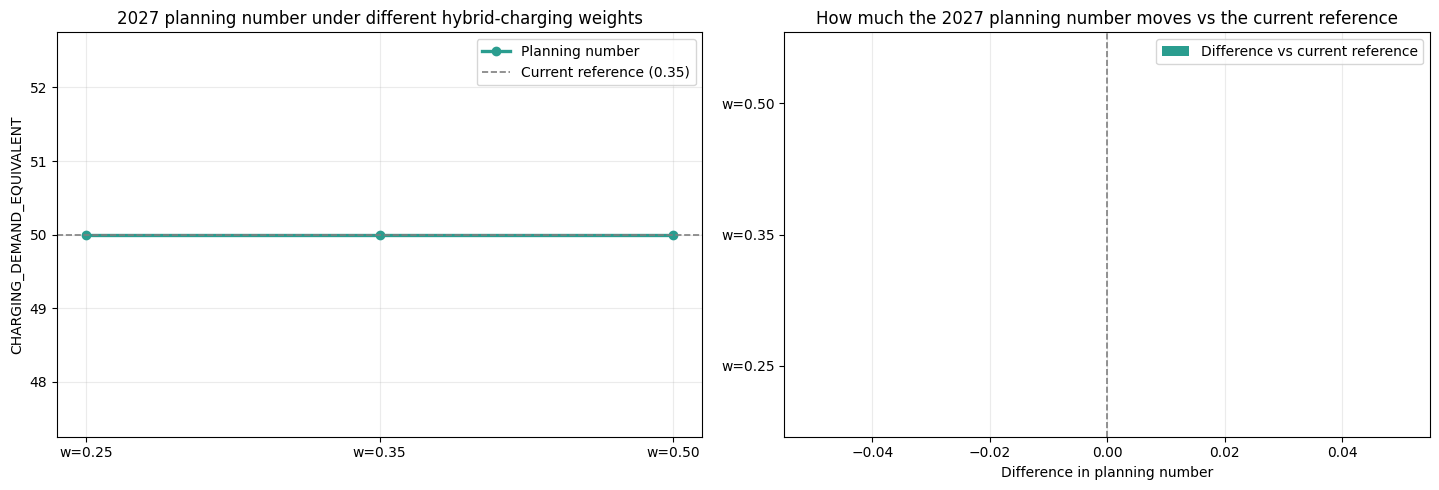

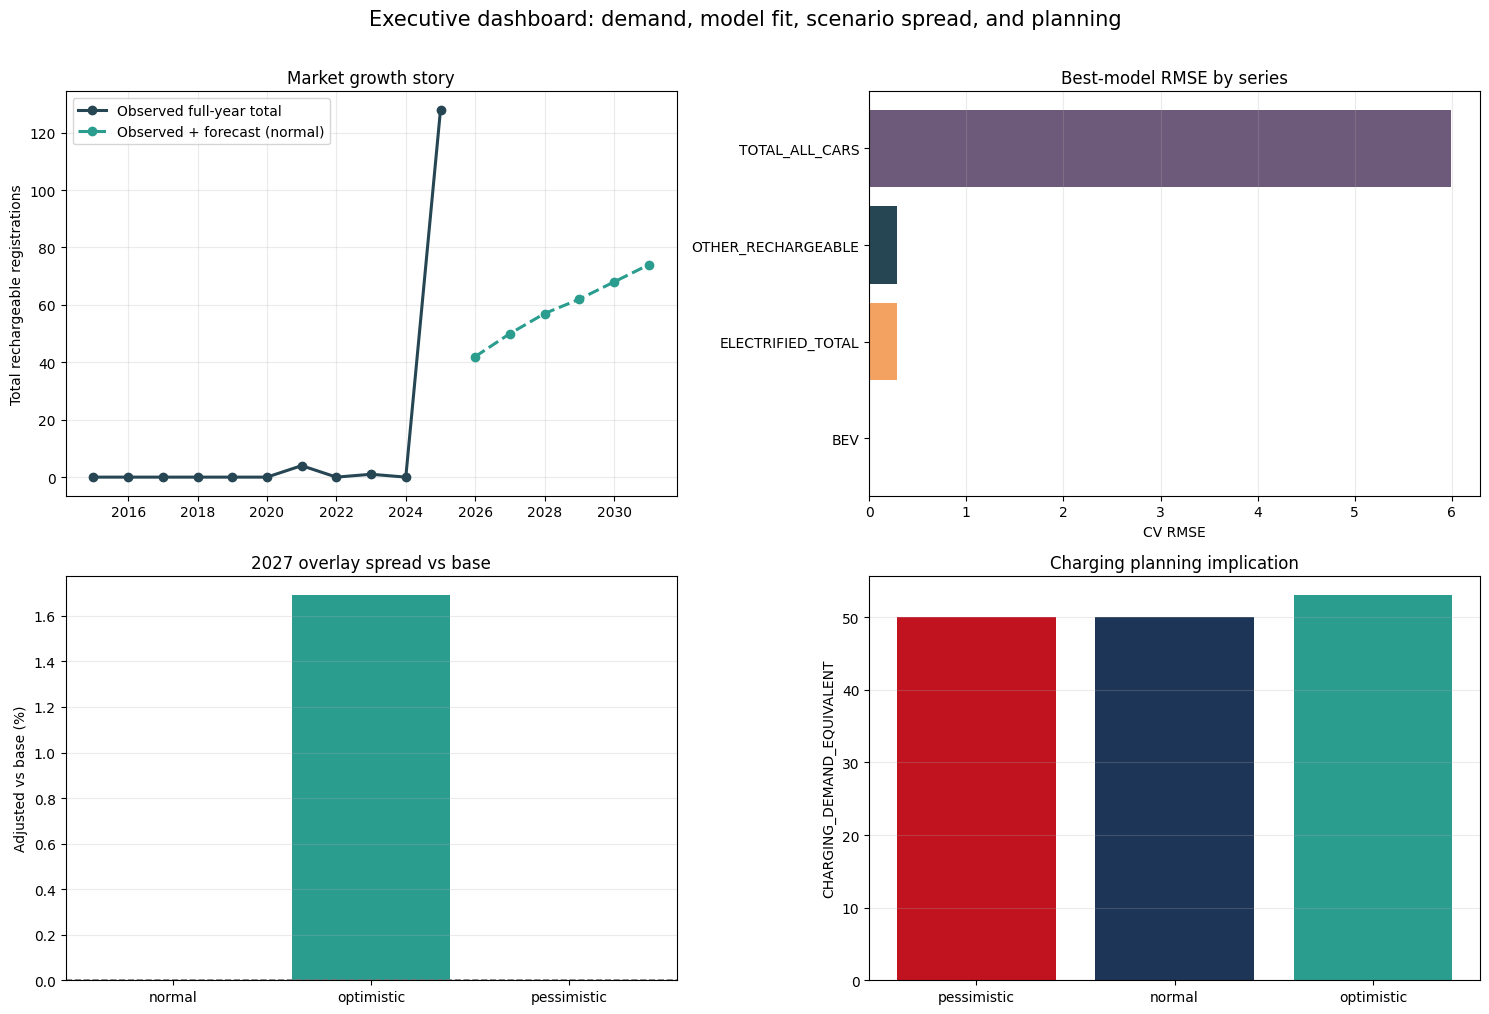

In [241]:
import os

normal_planning_row = planning_2027_summary.filter(pl.col("scenario") == planning_reference_scenario)
if normal_planning_row.height == 0:
    raise ValueError(
        f"Scenario {planning_reference_scenario!r} is not available for year {planning_target_year}. "
        f"Available scenarios: {planning_2027_summary['scenario'].to_list()}"
    )

sensitivity_weights = [0.25, charging_weight, 0.50]
sensitivity_weights = list(dict.fromkeys(round(float(w), 2) for w in sensitivity_weights))

normal_bev = float(normal_planning_row["BEV"][0])
normal_other_rechargeable = float(normal_planning_row[other_rechargeable_col][0])

planning_2027_weight_sensitivity = (
    pl.DataFrame({"charging_weight": sensitivity_weights})
    .with_columns([
        pl.lit(planning_target_year).alias("year"),
        pl.lit(planning_reference_scenario).alias("scenario"),
        pl.lit(int(round(normal_bev))).alias("BEV"),
        pl.lit(int(round(normal_other_rechargeable))).alias(other_rechargeable_col),
        (pl.lit(normal_bev) + pl.col("charging_weight") * pl.lit(normal_other_rechargeable)).alias(charging_metric_name)
    ])
    .with_columns(pl.col(charging_metric_name).round(0).cast(pl.Int64))
    .select(["year", "scenario", "charging_weight", "BEV", other_rechargeable_col, charging_metric_name])
)

final_2027_planning_number = int(normal_planning_row[charging_metric_name][0])

print("--- CHARGING DEMAND SENSITIVITY (2027 | normal scenario) ---")

print(
    f"\nFinal 2027 planning number (normal scenario, weight={charging_weight:.2f}): "
    f"{final_2027_planning_number}"
)

# Optional machine-friendly exports for reuse outside the notebook
save_dir = SAVE_DIR if "SAVE_DIR" in globals() else "."
os.makedirs(save_dir, exist_ok=True)
planning_2027_summary.write_csv(f"{save_dir}/planning_2027_summary.csv")
planning_2027_weight_sensitivity.write_csv(f"{save_dir}/planning_2027_weight_sensitivity.csv")
print(f"Saved: {save_dir}/planning_2027_summary.csv")
print(f"Saved: {save_dir}/planning_2027_weight_sensitivity.csv")

planning_2027_weight_sensitivity

# Sensitivity visuals
weight_labels = [f"w={w:.2f}" for w in planning_2027_weight_sensitivity["charging_weight"].to_list()]
weight_values = planning_2027_weight_sensitivity[charging_metric_name].to_list()
baseline_value = final_2027_planning_number
weight_deltas = [value - baseline_value for value in weight_values]

fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.0))
axes[0].plot(weight_labels, weight_values, marker="o", linewidth=2.4, color="#2a9d8f", label="Planning number")
axes[0].axhline(baseline_value, color="#7f7f7f", linestyle="--", linewidth=1.2, label=f"Current reference ({HYBRID_CHARGING_WEIGHT:.2f})")
axes[0].set_title("2027 planning number under different hybrid-charging weights")
axes[0].set_ylabel(charging_metric_name)
axes[0].grid(alpha=0.25)
axes[0].legend(loc="best")

delta_colors = ["#c1121f" if value < 0 else "#2a9d8f" for value in weight_deltas]
axes[1].barh(weight_labels, weight_deltas, color=delta_colors, label="Difference vs current reference")
axes[1].axvline(0, color="#7f7f7f", linestyle="--", linewidth=1.2)
axes[1].set_title("How much the 2027 planning number moves vs the current reference")
axes[1].set_xlabel("Difference in planning number")
axes[1].grid(axis="x", alpha=0.25)
axes[1].legend(loc="best")

plt.tight_layout()
plt.show()

# Final compact dashboard
observed_annual_total = (
    forecast_df_clean
    .with_columns(pl.col("month").dt.year().alias("year"))
    .filter(pl.col("year") < last_date.year)
    .group_by("year")
    .agg(pl.col(TOTAL_SERIES_NAME).sum().alias("observed_total"))
    .sort("year")
)
projected_annual_total = (
    forecast_annual_summary
    .filter((pl.col("vehicle_type") == TOTAL_SERIES_NAME) & (pl.col("scenario") == "normal"))
    .filter(pl.col("year") >= last_date.year)
    .select(["year", pl.col("forecast_total").alias("projected_total")])
    .sort("year")
)
rmse_dashboard = (
    candidate_cv_summary
    .group_by("Series")
    .first()
    .sort("RMSE")
)
overlay_2027 = scenario_adjustment_summary.filter((pl.col("year") == FOCUSED_SUMMARY_YEAR) & (pl.col("vehicle_type") == TOTAL_SERIES_NAME)).sort("scenario")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].plot(observed_annual_total["year"].to_list(), observed_annual_total["observed_total"].to_list(), marker="o", linewidth=2.2, color="#264653", label="Observed full-year total")
axes[0, 0].plot(projected_annual_total["year"].to_list(), projected_annual_total["projected_total"].to_list(), marker="o", linewidth=2.2, linestyle="--", color="#2a9d8f", label="Observed + forecast (normal)")
axes[0, 0].set_title("Market growth story")
axes[0, 0].set_ylabel("Total rechargeable registrations")
axes[0, 0].grid(alpha=0.25)
axes[0, 0].legend(loc="upper left")

axes[0, 1].barh(rmse_dashboard["Series"].to_list(), rmse_dashboard["RMSE"].to_list(), color=["#1f77b4", "#f4a261", "#264653", "#6d597a"][:rmse_dashboard.height])
axes[0, 1].set_title("Best-model RMSE by series")
axes[0, 1].set_xlabel("CV RMSE")
axes[0, 1].grid(axis="x", alpha=0.25)

axes[1, 0].bar(overlay_2027["scenario"].to_list(), overlay_2027["delta_pct"].to_list(), color=[OVERLAY_SCENARIO_COLORS.get(label, "#999999") for label in overlay_2027["scenario"].to_list()])
axes[1, 0].axhline(0, color="#7f7f7f", linestyle="--", linewidth=1.2)
axes[1, 0].set_title(f"{FOCUSED_SUMMARY_YEAR} overlay spread vs base")
axes[1, 0].set_ylabel("Adjusted vs base (%)")
axes[1, 0].grid(axis="y", alpha=0.25)

axes[1, 1].bar(planning_2027_summary["scenario"].to_list(), planning_2027_summary[charging_metric_name].to_list(), color=[OVERLAY_SCENARIO_COLORS.get(label, "#999999") for label in planning_2027_summary["scenario"].to_list()])
axes[1, 1].set_title("Charging planning implication")
axes[1, 1].set_ylabel(charging_metric_name)
axes[1, 1].grid(axis="y", alpha=0.25)

plt.suptitle("Executive dashboard: demand, model fit, scenario spread, and planning", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()


## Section 3 — Bridge: Mapping Data to Network Analysis

This cell converts the variables produced by Luka's data loading (Sections 1–5) and Romain's EV forecast (Section 6) into the standardised names used by the network optimisation pipeline (Section 4).

| Variable created | Source |
|---|---|
| `total_ev_projected_2027` | `final_2027_planning_number` (Romain, normal scenario) |
| `interurban_chargers_clean` | `df_chargers` (DGT XML, all Spain) |
| `gdf_substations` | `gdf_iberdrola` + `gdf_endesa` + `gdf_viesgo_demand` unified |
| `total_existing_stations_baseline` | `len(interurban_chargers_clean)` |

In [242]:
import pandas as pd
import geopandas as gpd

# 1 — EV 2027 projection (normal scenario, from Romain's SARIMA forecast)
total_ev_projected_2027 = int(final_2027_planning_number)
print(f"Total EV projected 2027 (normal scenario): {total_ev_projected_2027:,}")

# 2 — Existing charging stations filtered to interurban highways (AP/A/E/N prefix)
df_ch = df_chargers.to_pandas() if hasattr(df_chargers, 'to_pandas') else df_chargers
gdf_all = gpd.GeoDataFrame(
    df_ch,
    geometry=gpd.points_from_xy(df_ch['longitude'], df_ch['latitude']),
    crs='EPSG:4326',
)
# Load highway network — Major + Secondary, AP/A/E/N labels only
_roads = gpd.read_file('spain_roads_ne.geojson').to_crs('EPSG:25830')
_roads = _roads[_roads['type'].isin(['Major Highway', 'Secondary Highway'])]
_label_col = next((c for c in ['label','name'] if c in _roads.columns), None)
if _label_col:
    _roads = _roads[_roads[_label_col].fillna('').str.upper().str.startswith(('AP','A','E','N'))]

# Remove urban highway sections — download NE urban areas and clip them out
_urban_cache = Path('ne_urban_areas.geojson')
if not _urban_cache.exists():
    import requests
    _url = ('https://raw.githubusercontent.com/nvkelso/natural-earth-vector/'
            'master/geojson/ne_10m_urban_areas.geojson')
    _urban_cache.write_bytes(requests.get(_url, timeout=120).content)
    print('Urban areas cached')
_urban = gpd.read_file(_urban_cache).to_crs('EPSG:25830')
# Buffer urban polygons individually (avoids topology errors from global union)
import shapely
_urban['geometry'] = shapely.make_valid(_urban.geometry.values)
_urban['geometry'] = _urban.geometry.buffer(1_000)  # 1 km tight clip
# Use sjoin to tag roads that intersect any urban area — no union needed
_urban_road_idx = gpd.sjoin(
    _roads[['geometry']],
    _urban[['geometry']],
    how='inner', predicate='intersects'
).index.unique()
_roads_interurban = _roads[~_roads.index.isin(_urban_road_idx)]
print(f'Interurban highway segments (outside cities): {len(_roads_interurban):,}')

# 500 m buffer around interurban sections only
_highway_buffer = _roads_interurban.union_all().buffer(500)
_gdf_m = gdf_all.to_crs('EPSG:25830')
_in_buffer = _gdf_m.geometry.within(_highway_buffer)

# Also exclude charger points that fall directly inside any urban area
# (edge-of-city chargers can pass the 500m test even after segment removal)
_urban_idx = gpd.sjoin(
    _gdf_m[_in_buffer][['geometry']],
    _urban[['geometry']],
    how='inner', predicate='within'
).index.unique()

interurban_chargers_clean = (
    gdf_all[_in_buffer & ~_gdf_m.index.isin(_urban_idx)]
    .copy().reset_index(drop=True)
)
total_existing_stations_baseline = len(interurban_chargers_clean)
print(f"All DGT chargers in Spain:              {len(gdf_all):,}")
print(f"After highway buffer (500 m):           {_in_buffer.sum():,}")
print(f"After urban exclusion (interurban only): {total_existing_stations_baseline:,}")

# 3 — Unified substation GeoDataFrame (3 distributors)
def _std(gdf, operator):
    df = gdf[['latitude', 'longitude', 'capacity_available_mw', 'capacity_occupied_mw', 'geometry']].copy()
    df['grid_operator'] = operator
    return df

gdf_substations = gpd.GeoDataFrame(
    pd.concat([
        _std(gdf_iberdrola, 'Iberdrola i-DE'),
        _std(gdf_endesa,    'Endesa e-distribución'),
        _std(gdf_viesgo_demand, 'Viesgo'),
    ], ignore_index=True),
    geometry='geometry', crs='EPSG:4326',
)
gdf_substations = gdf_substations.dropna(subset=['latitude', 'longitude']).reset_index(drop=True)
print(f"Unified substations: {len(gdf_substations):,}")
print(gdf_substations['grid_operator'].value_counts().to_string())

Total EV projected 2027 (normal scenario): 50
Interurban highway segments (outside cities): 96
All DGT chargers in Spain:              11,568
After highway buffer (500 m):           182
After urban exclusion (interurban only): 182
Unified substations: 5,037
grid_operator
Iberdrola i-DE           3016
Endesa e-distribución    1844
Viesgo                    177


## Section 4 — Network Optimisation: EXPAND + FILL

### Methodology (McKinsey 85 % insight)

McKinsey research shows that **85 % of EV drivers plan their trips in advance**.  
The critical need is therefore twofold:

1. **EXPAND** — relieve the _busiest existing_ stations before they become bottlenecks.
2. **FILL** — place new stations on corridors that have no coverage within the EV's practical range (~100 km), ensuring a charger every 175 km.

| Type | Rule | Driver |
|---|---|---|
| EXPAND | Top 30 % by pressure score on existing stations | Demand relief |
| FILL | Every 175 km, if no charger within 100 km | Coverage gap |

**Pressure score** = EV-growth multiplier × road-weight / n_connectors  
**Road weights**: AP- 3.0 · A- 2.5 · E- 2.0 · N- 1.5  
**EV-growth multiplier** = total_ev_projected_2027 / 487 014 (2024 BEV baseline)

Grid status thresholds (4 chargers × 150 kW = 600 kW demand):
- **Sufficient** ≥ 720 kW available  
- **Moderate** 480–719 kW  
- **Congested** < 480 kW

### Output Datasets — File 1 / 2 / 3

In [243]:
import numpy as np
import pandas as pd
import geopandas as gpd
from pathlib import Path
from shapely.geometry import MultiPoint
from shapely.ops import nearest_points
import warnings
warnings.filterwarnings('ignore')

# ── Parameters ────────────────────────────────────────────────────────────
FILL_SPACING_KM   = 175
FILL_EXCLUSION_KM = 100
EXPAND_PCT        = 30
N_CHARGERS        = 4
KW_PER_CHARGER    = 150
DEMAND_KW         = N_CHARGERS * KW_PER_CHARGER   # 600 kW
BASE_BEV          = 487_014
ROAD_WEIGHTS      = {'AP': 3.0, 'A': 2.5, 'E': 2.0, 'N': 1.5}

# ── EV growth multiplier ──────────────────────────────────────────────────
ev_growth = total_ev_projected_2027 / BASE_BEV
print(f"EV growth multiplier: {ev_growth:.3f}  ({total_ev_projected_2027:,} / {BASE_BEV:,})")

# ── Load road network ─────────────────────────────────────────────────────
roads_path = Path('spain_roads_ne.geojson')
if not roads_path.exists():
    import requests
    url = ('https://raw.githubusercontent.com/nvkelso/natural-earth-vector/'
           'master/geojson/ne_10m_roads.geojson')
    roads_path.write_bytes(requests.get(url, timeout=120).content)
    print("Roads downloaded from Natural Earth")

gdf_roads = gpd.read_file(roads_path).to_crs('EPSG:4326')
gdf_roads = gdf_roads.cx[-9.5:5.0, 35.0:44.5]
# Keep only interurban highways — exclude local roads, ferries, unknown
gdf_roads = gdf_roads[gdf_roads['type'].isin(['Major Highway', 'Secondary Highway'])]
print(f"{len(gdf_roads):,} interurban highway segments in Spain")
print(gdf_roads['type'].value_counts().to_string())
# Use 'label' (e.g. 'A7', 'E70', 'AP-9') — 'name' is just a bare number
name_col = next((c for c in ['label','ref','name','NAME','LABEL','REF'] if c in gdf_roads.columns), None)
print(f"Road name column used: {name_col}")

# Keep only roads whose label starts with AP/A/E/N (interurban network)
HIGHWAY_PREFIXES = tuple(ROAD_WEIGHTS.keys())  # ('AP','A','E','N')
if name_col:
    mask = gdf_roads[name_col].fillna('').str.upper().str.startswith(HIGHWAY_PREFIXES)
    gdf_roads = gdf_roads[mask]
print(f"{len(gdf_roads):,} segments after label-prefix filter ({', '.join(HIGHWAY_PREFIXES)})")

# Remove urban sections — reuse cached urban areas from bridge cell
_urban2 = gpd.read_file(Path('ne_urban_areas.geojson')).to_crs('EPSG:25830')
import shapely as _shapely
_urban2['geometry'] = _shapely.make_valid(_urban2.geometry.values)
_urban2['geometry'] = _urban2.geometry.buffer(1_000)  # 1 km — tight clip
# Remove segments that run entirely through urban areas
gdf_roads_m = gdf_roads.to_crs('EPSG:25830')
_urban_road_idx = gpd.sjoin(
    gdf_roads_m[['geometry']],
    _urban2[['geometry']],
    how='inner', predicate='intersects'
).index.unique()
gdf_roads_m = gdf_roads_m[~gdf_roads_m.index.isin(_urban_road_idx)]
gdf_roads   = gdf_roads[~gdf_roads.index.isin(_urban_road_idx)]
print(f"{len(gdf_roads_m):,} interurban segments after urban exclusion")

# Also store urban buffer for point-level filtering after sampling
_urban_geom_m = _urban2.union_all()

# ── Road-weight helper ────────────────────────────────────────────────────
def road_weight(rname):
    if not isinstance(rname, str): return 1.5
    r = rname.strip().upper()
    for prefix, w in sorted(ROAD_WEIGHTS.items(), key=lambda x: -len(x[0])):
        if r.startswith(prefix): return w
    return 1.5

# ── Sample candidate FILL points along roads ─────────────────────────────
gdf_roads_m = gdf_roads.to_crs('EPSG:25830')
candidate_pts = []
for _, row in gdf_roads_m.iterrows():
    geom = row.geometry
    if geom is None or geom.is_empty: continue
    length_m = geom.length
    n_steps  = max(1, int(length_m / (FILL_SPACING_KM * 1000)))
    for i in range(n_steps + 1):
        frac  = min(i / n_steps, 1.0) if n_steps > 0 else 0
        pt    = geom.interpolate(frac, normalized=True)
        rname = str(row[name_col]) if name_col and row[name_col] else 'N-Unknown'
        candidate_pts.append({
            'geometry':      pt,
            'route_segment': rname,
            'road_weight':   road_weight(rname),
        })

gdf_cand = gpd.GeoDataFrame(candidate_pts, crs='EPSG:25830').to_crs('EPSG:4326')
print(f"{len(gdf_cand):,} candidate road points sampled")

# ── Spain boundary clip ───────────────────────────────────────────────────
_cache = Path('spain_boundary.geojson')
if not _cache.exists():
    import requests
    url = ('https://raw.githubusercontent.com/nvkelso/natural-earth-vector/'
           'master/geojson/ne_110m_admin_0_countries.geojson')
    countries = gpd.read_file(url)
    countries[countries['ADM0_A3'] == 'ESP'].to_file(_cache, driver='GeoJSON')
    print("Spain boundary cached")
spain_gdf = gpd.read_file(_cache).to_crs('EPSG:4326')
gdf_cand = gpd.sjoin(gdf_cand, spain_gdf[['geometry']], how='inner', predicate='within')
gdf_cand = gdf_cand.drop(columns=['index_right'])
print(f"{len(gdf_cand):,} candidate points within Spain")

# Exclude FILL candidates that fall inside urban areas (same urban buffer as roads)
_cand_m_tmp = gdf_cand.to_crs('EPSG:25830')
_urban_cand_idx = gpd.sjoin(
    _cand_m_tmp[['geometry']],
    _urban2[['geometry']],
    how='inner', predicate='within'
).index.unique()
gdf_cand = gdf_cand[~gdf_cand.index.isin(_urban_cand_idx)].reset_index(drop=True)
print(f"{len(gdf_cand):,} candidate points after urban exclusion")

# ── Build gdf_exist_m from interurban_chargers_clean ────────────────────
# (mirrors the approach in the original Zero_Heroes.ipynb)
_exist_df = interurban_chargers_clean.copy()
if not isinstance(_exist_df, gpd.GeoDataFrame) or _exist_df.crs is None:
    _exist_df = gpd.GeoDataFrame(
        _exist_df,
        geometry=gpd.points_from_xy(_exist_df['longitude'], _exist_df['latitude']),
        crs='EPSG:4326',
    )
gdf_exist_m = _exist_df.to_crs('EPSG:25830').copy()

# Assign road_name by snapping each charger to the nearest interurban segment
_snap = gpd.sjoin_nearest(gdf_exist_m[['geometry']], gdf_roads_m[['geometry', name_col]], how='left')
_snap = _snap.groupby(_snap.index, sort=False).first().reindex(gdf_exist_m.index)
gdf_exist_m['road_name'] = _snap[name_col].fillna('N-Unknown').values

def _road_weight(road_name):
    r = str(road_name).strip().upper()
    for prefix, w in sorted(ROAD_WEIGHTS.items(), key=lambda x: -len(x[0])):
        if r.startswith(prefix): return w
    return 1.0

import re as _re
def _norm_segment(s):
    if not isinstance(s, str): return 'N-Unknown'
    m = _re.match(r'^(AP|A|E|N)(\d.*)', s.strip().upper())
    return f"{m.group(1)}-{m.group(2)}" if m else s.strip().upper()

# ── EXPAND: top EXPAND_PCT% pressure existing highway stations ───────────
gdf_exist_m['n_connectors']   = gdf_exist_m['n_connectors'].fillna(1).clip(lower=1)
gdf_exist_m['road_weight']    = gdf_exist_m['road_name'].apply(_road_weight)
gdf_exist_m['pressure_score'] = (ev_growth * gdf_exist_m['road_weight'] / gdf_exist_m['n_connectors']).round(3)
gdf_exist_m['route_segment']  = gdf_exist_m['road_name'].apply(_norm_segment)

threshold  = gdf_exist_m['pressure_score'].quantile(1 - EXPAND_PCT / 100)
gdf_expand = gdf_exist_m[gdf_exist_m['pressure_score'] >= threshold].copy().to_crs('EPSG:4326')
gdf_expand['latitude']     = gdf_expand.geometry.y
gdf_expand['longitude']    = gdf_expand.geometry.x
gdf_expand['station_type'] = 'EXPAND'
print(f"EXPAND candidates: {len(gdf_expand):,}  (top {EXPAND_PCT}% by pressure, threshold={threshold:.3f})")
print(gdf_expand['road_name'].value_counts().head(8).to_string())

# ── FILL: candidates with no existing charger within FILL_EXCLUSION_KM ───
gdf_cand_m   = gdf_cand.to_crs('EPSG:25830')
gdf_exist_m2 = gdf_exist_m  # use highway-filtered chargers as coverage reference

from scipy.spatial import cKDTree
exist_coords = np.array([(g.x, g.y) for g in gdf_exist_m2.geometry])
cand_coords  = np.array([(g.x, g.y) for g in gdf_cand_m.geometry])
if len(exist_coords) > 0:
    tree = cKDTree(exist_coords)
    dists, _ = tree.query(cand_coords)
    fill_mask = dists > FILL_EXCLUSION_KM * 1000
else:
    fill_mask = np.ones(len(gdf_cand_m), dtype=bool)

gdf_fill_m = gdf_cand_m[fill_mask].copy()
print(f"FILL before dedup: {len(gdf_fill_m):,}")

# ── Deduplicate FILL: greedy spatial thinning (keep best-weighted, >FILL_SPACING_KM apart) ──
MIN_SEP_M = FILL_SPACING_KM * 1000
fill_sorted = gdf_fill_m.sort_values('road_weight', ascending=False).reset_index(drop=True)
kept_coords = []
kept_idx    = []
for i, row in fill_sorted.iterrows():
    pt = (row.geometry.x, row.geometry.y)
    if not kept_coords or cKDTree(kept_coords).query(pt)[0] > MIN_SEP_M:
        kept_coords.append(pt)
        kept_idx.append(i)

gdf_fill = fill_sorted.loc[kept_idx].copy().to_crs('EPSG:4326')
gdf_fill['latitude']       = gdf_fill.geometry.y
gdf_fill['longitude']      = gdf_fill.geometry.x
gdf_fill['station_type']   = 'FILL'
gdf_fill['pressure_score'] = 0.0
gdf_fill['route_segment']  = gdf_fill['route_segment'].apply(_norm_segment)
print(f"FILL after dedup:  {len(gdf_fill):,}")

# ── Combine ───────────────────────────────────────────────────────────────
gdf_expand_out = gdf_expand[['latitude','longitude','route_segment','station_type','pressure_score','geometry']].copy()
gdf_fill_out   = gdf_fill[['latitude','longitude','route_segment','station_type','pressure_score','geometry']].copy()
gdf_proposed   = gpd.GeoDataFrame(
    pd.concat([gdf_expand_out, gdf_fill_out], ignore_index=True),
    geometry='geometry', crs='EPSG:4326',
)
print(f"\nTotal proposed (before grid filter): {len(gdf_proposed):,}")

# ── Assign grid status via nearest substation ─────────────────────────────
gdf_sub_m  = gdf_substations.dropna(subset=['capacity_available_mw']).to_crs('EPSG:25830')
gdf_prop_m = gdf_proposed.to_crs('EPSG:25830')

gdf_joined = gpd.sjoin_nearest(
    gdf_prop_m,
    gdf_sub_m[['capacity_available_mw','geometry']],
    how='left', distance_col='dist_to_sub_m',
)
# sjoin_nearest can return duplicate rows on ties — keep the closest match per input row
gdf_joined = gdf_joined.groupby(gdf_joined.index, sort=False).first()
gdf_joined = gdf_joined.reindex(gdf_prop_m.index)  # realign to original row order
gdf_joined['cap_kw'] = gdf_joined['capacity_available_mw'].fillna(0) * 1000

def _gs(cap):
    if cap >= 720: return 'Sufficient'
    if cap >= 480: return 'Moderate'
    return 'Congested'

gdf_proposed['grid_status'] = gdf_joined['cap_kw'].apply(_gs).values
gdf_proposed['n_chargers_proposed'] = N_CHARGERS
gdf_proposed['estimated_demand_kw'] = DEMAND_KW

# Remove Portugal/France stragglers
gdf_proposed = gpd.sjoin(gdf_proposed, spain_gdf[['geometry']], how='inner', predicate='within')
gdf_proposed = gdf_proposed.drop(columns=['index_right']).reset_index(drop=True)

print(f"\n=== Final proposed network ===")
print(f"Total stations:     {len(gdf_proposed):,}")
print(gdf_proposed['grid_status'].value_counts().to_string())
print(gdf_proposed['station_type'].value_counts().to_string())

EV growth multiplier: 0.000  (50 / 487,014)
467 interurban highway segments in Spain
type
Major Highway        254
Secondary Highway    213
Road name column used: label
292 segments after label-prefix filter (AP, A, E, N)
96 interurban segments after urban exclusion
192 candidate road points sampled
152 candidate points within Spain
152 candidate points after urban exclusion
EXPAND candidates: 182  (top 30% by pressure, threshold=0.000)
road_name
E901    37
E70     21
A7      17
E803    16
A318    13
N401    10
AP7      9
AP41     8
FILL before dedup: 12
FILL after dedup:  4

Total proposed (before grid filter): 186

=== Final proposed network ===
Total stations:     186
grid_status
Congested     162
Sufficient     24
station_type
EXPAND    182
FILL        4


### BI Visualisation — Full Proposed Network

In [244]:
import pandas as pd
from pathlib import Path

# Deduplicate proposed stations by lat/lon (removes any sjoin/concat duplicates)
gdf_proposed = gdf_proposed.drop_duplicates(subset=['latitude','longitude']).reset_index(drop=True)
print(f'Unique proposed stations after dedup: {len(gdf_proposed):,}')

# ── File 1: KPI Scorecard ─────────────────────────────────────────────────
total_proposed        = len(gdf_proposed)
total_friction        = (gdf_proposed['grid_status'] != 'Sufficient').sum()
# Single wide-format summary row (as required by guidelines)
file1 = pd.DataFrame([{
    'total_proposed_stations':          total_proposed,
    'total_existing_stations_baseline': total_existing_stations_baseline,
    'total_friction_points':            int(total_friction),
    'total_ev_projected_2027':          total_ev_projected_2027,
}])
file1.to_csv('File_1.csv', index=False)
print('=== FILE 1 — Global KPI Scorecard ===')
print(file1.to_string(index=False))
print(f'Shape: {file1.shape} | Columns: {list(file1.columns)}')

# ── File 2: Proposed Stations ─────────────────────────────────────────────
file2 = gdf_proposed[['latitude','longitude','route_segment',
                       'n_chargers_proposed','grid_status',
                       'station_type','pressure_score']].copy().reset_index(drop=True)
file2.insert(0, 'location_id', [f'IBE_{i+1:03d}' for i in range(len(file2))])
file2.to_csv('File_2.csv', index=False)
print('=== FILE 2 — Proposed Charging Locations ===')
print(f'Rows: {len(file2):,} | Columns: {list(file2.columns)}')
print(file2.dtypes.to_string())
print(file2.head(5).to_string(index=False))

# ── File 3: Friction Points (Moderate + Congested only) ──────────────────
mask3 = gdf_proposed['grid_status'].isin(['Moderate','Congested'])
file3 = gdf_proposed.loc[mask3, ['latitude','longitude','route_segment',
                                  'n_chargers_proposed','grid_status',
                                  'estimated_demand_kw']].copy().reset_index(drop=True)
file3.insert(0, 'bottleneck_id', [f'FRIC_{i+1:03d}' for i in range(len(file3))])

# Assign distributor by nearest substation (required: i-DE, Endesa, or Viesgo)
DISTRIBUTOR_MAP = {
    'Iberdrola i-DE':       'i-DE',
    'Endesa e-distribución': 'Endesa',
    'Viesgo':               'Viesgo',
}
gdf_sub_dist = gdf_substations[['grid_operator','geometry']].dropna().to_crs('EPSG:25830')
gdf_f3_m = gpd.GeoDataFrame(
    file3, geometry=gpd.points_from_xy(file3['longitude'], file3['latitude']), crs='EPSG:4326'
).to_crs('EPSG:25830')
joined = gpd.sjoin_nearest(gdf_f3_m[['geometry']], gdf_sub_dist, how='left')
joined = joined.groupby(joined.index, sort=False).first()
joined = joined.reindex(gdf_f3_m.index)
file3['distributor_network'] = (
    joined['grid_operator'].map(DISTRIBUTOR_MAP).fillna('i-DE')
)

file3.to_csv('File_3.csv', index=False)
print('=== FILE 3 — Friction Points ===')
print(f'Rows: {len(file3):,} | Columns: {list(file3.columns)}')
print(file3.dtypes.to_string())
print(file3[['grid_status','distributor_network']].value_counts().to_string())
print(file3.head(5).to_string(index=False))
assert not (file3['grid_status'] == 'Sufficient').any(), 'ERROR: Sufficient in File_3!'
print('✅ No Sufficient entries in File_3 — compliant')

Unique proposed stations after dedup: 181
=== FILE 1 — Global KPI Scorecard ===
 total_proposed_stations  total_existing_stations_baseline  total_friction_points  total_ev_projected_2027
                     181                               182                    157                       50
Shape: (1, 4) | Columns: ['total_proposed_stations', 'total_existing_stations_baseline', 'total_friction_points', 'total_ev_projected_2027']
=== FILE 2 — Proposed Charging Locations ===
Rows: 181 | Columns: ['location_id', 'latitude', 'longitude', 'route_segment', 'n_chargers_proposed', 'grid_status', 'station_type', 'pressure_score']
location_id             object
latitude               float64
longitude              float64
route_segment           object
n_chargers_proposed      int64
grid_status             object
station_type            object
pressure_score         float64
location_id  latitude  longitude route_segment  n_chargers_proposed grid_status station_type  pressure_score
    IBE_001 

### BI Visualisation — Priority Map

In [245]:
import plotly.graph_objects as go
from pathlib import Path

STATUS_COLOR = {'Sufficient': '#2ecc71', 'Moderate': '#f39c12', 'Congested': '#e74c3c'}
TYPE_SYMBOL  = {'EXPAND': 'diamond', 'FILL': 'circle'}

fig = go.Figure()

# Spain land polygon
fig.add_trace(go.Choropleth(
    locations=['ESP'], z=[1], colorscale=[[0,'#1a2a3a'],[1,'#1a2a3a']],
    marker_line_width=1.5, marker_line_color='#3a5a7a',
    showscale=False, showlegend=False,
    hoverinfo='skip',
))

for stype in ['EXPAND','FILL']:
    for status, color in STATUS_COLOR.items():
        sub = gdf_proposed[(gdf_proposed['station_type']==stype) & (gdf_proposed['grid_status']==status)]
        if len(sub) == 0: continue
        fig.add_trace(go.Scattergeo(
            lat=sub['latitude'], lon=sub['longitude'],
            mode='markers',
            marker=dict(size=7 if stype=='EXPAND' else 6,
                        color=color, opacity=0.85,
                        symbol=TYPE_SYMBOL[stype],
                        line=dict(width=0.5, color='#ffffff')),
            name=f'{stype} — {status}',
            customdata=sub[['route_segment', 'n_chargers_proposed', 'grid_status']].values,
        hovertemplate=(
            f'<b>{stype} — {status}</b><br>'
            'Route: %{customdata[0]}<br>'
            'Chargers: %{customdata[1]}<br>'
            'Grid: %{customdata[2]}<br>'
            'Lat: %{lat:.4f} | Lon: %{lon:.4f}'
            '<extra></extra>'
        ),
        ))

fig.update_layout(
    title=dict(text='Zero Heroes — Proposed EV Network Spain 2027', font=dict(color='#e8eaf0', size=16)),
    paper_bgcolor='#0d1117', plot_bgcolor='#0d1117',
    geo=dict(
        scope='world',
        lonaxis=dict(range=[-9.5, 4.5]),
        lataxis=dict(range=[35.5, 44.5]),
        showland=False, showocean=True,
        oceancolor='#0d1117',
        showcountries=False, showcoastlines=False,
        bgcolor='#0d1117',
    ),
    legend=dict(bgcolor='rgba(22,27,39,0.85)', font=dict(color='#e8eaf0', size=11)),
    height=750, margin=dict(l=0, r=0, t=40, b=0),
)

out = Path('proposed_network_map.html')
fig.write_html(str(out), include_plotlyjs='cdn', full_html=True)
print(f"Saved: {out}  ({out.stat().st_size/1024:.0f} kB)")
fig.show()

print(f"\nTotal stations: {len(gdf_proposed):,}")
print(gdf_proposed['grid_status'].value_counts().to_string())
print(gdf_proposed['station_type'].value_counts().to_string())

Saved: proposed_network_map.html  (18 kB)



Total stations: 181
grid_status
Congested     157
Sufficient     24
station_type
EXPAND    177
FILL        4


### BI Visualisation — Priority Stations Map
Filters to `grid_status == 'Sufficient'` only — the grid-ready locations for immediate deployment.

In [246]:
import plotly.graph_objects as go
from pathlib import Path

# Filter to grid-ready stations only (Sufficient capacity — immediately deployable)
gdf_priority = gdf_proposed[gdf_proposed['grid_status'] == 'Sufficient'].copy().reset_index(drop=True)
print(f"Grid-ready stations (Sufficient): {len(gdf_priority):,}")
print(gdf_priority['station_type'].value_counts().to_string())

fig = go.Figure()

# Spain land polygon
fig.add_trace(go.Choropleth(
    locations=['ESP'], z=[1], colorscale=[[0,'#1a2a3a'],[1,'#1a2a3a']],
    marker_line_width=1.5, marker_line_color='#3a5a7a',
    showscale=False, showlegend=False,
    hoverinfo='skip',
))

PRIORITY_COLOR = {'EXPAND': '#1e90ff', 'FILL': '#00e676'}
PRIORITY_SYM   = {'EXPAND': 'diamond', 'FILL': 'circle'}
PRIORITY_LABEL = {'EXPAND': '◆ EXPAND (busy existing — add chargers)', 'FILL': '● FILL (175 km gap — new station)'}

for stype in ['EXPAND', 'FILL']:
    sub = gdf_priority[gdf_priority['station_type'] == stype].copy()
    if len(sub) == 0: continue
    fig.add_trace(go.Scattergeo(
        lat=sub['latitude'], lon=sub['longitude'],
        mode='markers',
        marker=dict(size=9 if stype == 'EXPAND' else 7,
                    color=PRIORITY_COLOR[stype], opacity=0.9,
                    symbol=PRIORITY_SYM[stype],
                    line=dict(width=0.8, color='#ffffff')),
        name=PRIORITY_LABEL[stype],
        customdata=sub[['route_segment', 'n_chargers_proposed', 'grid_status']].values,
        hovertemplate=(
            f'<b>{stype} — Grid-Ready (Sufficient)</b><br>'
            'Route: %{customdata[0]}<br>'
            'Chargers: %{customdata[1]}<br>'
            'Grid: %{customdata[2]}<br>'
            'Lat: %{lat:.4f} | Lon: %{lon:.4f}'
            '<extra></extra>'
        ),
    ))

fig.update_layout(
    title=dict(text='Zero Heroes — Priority Stations (Grid-Ready, Sufficient Capacity)',
               font=dict(color='#e8eaf0', size=16)),
    paper_bgcolor='#0d1117', plot_bgcolor='#0d1117',
    geo=dict(
        scope='world',
        lonaxis=dict(range=[-9.5, 4.5]),
        lataxis=dict(range=[35.5, 44.5]),
        showland=False, showocean=True,
        oceancolor='#0d1117',
        showcountries=False, showcoastlines=False,
        bgcolor='#0d1117',
    ),
    legend=dict(bgcolor='rgba(22,27,39,0.85)', font=dict(color='#e8eaf0', size=11)),
    height=750, margin=dict(l=0, r=0, t=40, b=0),
)

out = Path('priority_network_map.html')
fig.write_html(str(out), include_plotlyjs='cdn', full_html=True)
print(f"\nSaved: {out}  ({out.stat().st_size/1024:.0f} kB)")
fig.show()

Grid-ready stations (Sufficient): 24
station_type
EXPAND    24

Saved: priority_network_map.html  (10 kB)
